# Notebook 09 — Training Model Task 1: Klasifikasi Aspek

**Task 1** adalah klasifikasi aspek multilabel.
Setiap ulasan diprediksi apakah membahas aspek
tertentu atau tidak.

| Label | Keterangan |
|---|---|
| Room_label     | 1 = membahas aspek Room, 0 = tidak |
| Hotel_label    | 1 = membahas aspek Hotel, 0 = tidak |
| Location_label | 1 = membahas aspek Location, 0 = tidak |
| Service_label  | 1 = membahas aspek Service, 0 = tidak |

---

**8 Skenario yang dijalankan (tanpa balancing):**

| Skenario | Arsitektur | Embedding | Teks |
|---|---|---|---|
| 1 | CNN    | Word2Vec | Non-Stemmed |
| 2 | CNN    | Word2Vec | Stemmed |
| 3 | CNN    | FastText | Non-Stemmed |
| 4 | CNN    | FastText | Stemmed |
| 5 | BiLSTM | Word2Vec | Non-Stemmed |
| 6 | BiLSTM | Word2Vec | Stemmed |
| 7 | BiLSTM | FastText | Non-Stemmed |
| 8 | BiLSTM | FastText | Stemmed |

---

**Hyperparameter:**

| Parameter | CNN | BiLSTM |
|---|---|---|
| Filter/Units | 100 filter | 64 units (output 128) |
| Kernel size | 3, 4, 5 | — |
| LSTM Dropout | — | 0.2 |
| LSTM Recurrent Dropout | — | 0.2 |
| Concat output | 300 (100×3) | — |
| FC Layer | Dense(64, relu) | Dense(64, relu) |
| L2 Regularization | 0.001 | 0.001 |
| Dropout FC | 0.5 | 0.5 |
| Optimizer | Adam | Adam |
| Learning rate | 0.001 | 0.001 |
| Loss | binary_crossentropy | binary_crossentropy |
| Batch size | 32 | 32 |
| Max epoch | 20 | 20 |
| Early stopping | patience=2, val_loss | patience=2, val_loss |
| Max length | 100 token | 100 token |
| K-Fold | MultilabelStratifiedKFold(5) | MultilabelStratifiedKFold(5) |

---

**Input:**
- `df_train_full.csv`, `df_test_full.csv`
- `tokenizer_nonstem.pkl`, `tokenizer_stem.pkl`
- 4 model word embedding (.model)

**Output per skenario:**
- `model.h5`
- `metrics_per_fold.csv`
- `history_per_fold.csv`
- `predictions_all_folds.csv`
- `rekap_Task1_semua_skenario.csv` + `.xlsx`


## 1. Instalasi & Import Library

In [ ]:
!pip install gensim scikit-learn openpyxl iterative-stratification --quiet
import os
import time
import pickle
import psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
from gensim.models import Word2Vec, FastText

from sklearn.model_selection import KFold
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    accuracy_score, roc_auc_score,
    hamming_loss, classification_report
)

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, GlobalMaxPooling1D,
    Bidirectional, LSTM, Dense, Dropout, Concatenate
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.metrics import AUC

# Supaya hasil reproducible
tf.random.set_seed(42)
np.random.seed(42)

print("Library berhasil diimport.")
print(f"TensorFlow version: {tf.__version__}")

Library berhasil diimport.
TensorFlow version: 2.19.0


## 2. Mount Google Drive & Konfigurasi Path

In [ ]:
drive.mount('/content/drive')

BASE_DIR    = '/content/drive/MyDrive/SKRIPSI_NAVY/'
SPLIT_DIR   = BASE_DIR + 'Dataset/Dataset_SplitData/'
TOKEN_DIR   = BASE_DIR + 'Dataset/Dataset_Tokenizer/'
EMBED_DIR   = BASE_DIR + 'Dataset/Dataset_WordEmbedding/'
OUTPUT_DIR  = BASE_DIR + 'Dataset/Dataset_Modelling/Task1_Aspek/'

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output dir: {OUTPUT_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Output dir: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task1_Aspek/


## 3. Load Dataset, Tokenizer & Word Embedding

Kita load semua bahan yang dibutuhkan sebelum training:
- **Dataset**: df_train_full dan df_test_full
- **Tokenizer**: mengubah teks → urutan indeks angka
- **Word Embedding**: Word2Vec dan FastText yang sudah dilatih

In [ ]:
# Load dataset
df_train = pd.read_csv(SPLIT_DIR + 'df_train_full.csv', keep_default_na=False)
df_test  = pd.read_csv(SPLIT_DIR + 'df_test_full.csv',  keep_default_na=False)

print(f"df_train : {df_train.shape[0]:,} baris")
print(f"df_test  : {df_test.shape[0]:,} baris")
print(f"\nKolom label Task 1:")
for col in ['Room_label', 'Hotel_label', 'Location_label', 'Service_label']:
    n1 = (df_train[col] == 1).sum()
    n0 = (df_train[col] == 0).sum()
    print(f"  {col}: Dibahas(1)={n1:,} | Tidak(0)={n0:,}")

df_train : 7,026 baris
df_test  : 795 baris

Kolom label Task 1:
  Room_label: Dibahas(1)=3,066 | Tidak(0)=3,960
  Hotel_label: Dibahas(1)=2,953 | Tidak(0)=4,073
  Location_label: Dibahas(1)=2,378 | Tidak(0)=4,648
  Service_label: Dibahas(1)=2,500 | Tidak(0)=4,526


In [ ]:
# Load tokenizer
with open(TOKEN_DIR + 'tokenizer_nonstem.pkl', 'rb') as f:
    tokenizer_nonstem = pickle.load(f)

with open(TOKEN_DIR + 'tokenizer_stem.pkl', 'rb') as f:
    tokenizer_stem = pickle.load(f)

vocab_size_nonstem = len(tokenizer_nonstem.word_index) + 1
vocab_size_stem    = len(tokenizer_stem.word_index) + 1

print(f"Tokenizer Non-Stemmed : {vocab_size_nonstem:,} kata")
print(f"Tokenizer Stemmed     : {vocab_size_stem:,} kata")

Tokenizer Non-Stemmed : 5,546 kata
Tokenizer Stemmed     : 3,812 kata


In [ ]:
# Load word embedding models
model_w2v_nonstem = Word2Vec.load(EMBED_DIR + 'word2vec_non_stemmed.model')
model_w2v_stem    = Word2Vec.load(EMBED_DIR + 'word2vec_stemmed.model')
model_ft_nonstem  = FastText.load(EMBED_DIR + 'fasttext_non_stemmed.model')
model_ft_stem     = FastText.load(EMBED_DIR + 'fasttext_stemmed.model')

print("Word Embedding berhasil diload:")
print(f"  Word2Vec Non-Stemmed : {len(model_w2v_nonstem.wv):,} kata")
print(f"  Word2Vec Stemmed     : {len(model_w2v_stem.wv):,} kata")
print(f"  FastText Non-Stemmed : {len(model_ft_nonstem.wv):,} kata")
print(f"  FastText Stemmed     : {len(model_ft_stem.wv):,} kata")

Word Embedding berhasil diload:
  Word2Vec Non-Stemmed : 3,401 kata
  Word2Vec Stemmed     : 2,468 kata
  FastText Non-Stemmed : 3,401 kata
  FastText Stemmed     : 2,468 kata


## 4. Fungsi-Fungsi Utama

Semua fungsi yang digunakan selama training didefinisikan

In [ ]:
# ============================================================
# FUNGSI 1: Buat Embedding Matrix
# Embedding matrix adalah jembatan antara tokenizer Keras
# (yang bekerja dengan indeks angka) dan model Word2Vec/FastText
# (yang menyimpan vektor kata).
#
# Cara kerja:
# - tokenizer punya word_index: {'bersih': 42, 'kotor': 3, ...}
# - embedding model punya vektor: {'bersih': [0.2, -0.1, ...]}
# - matrix[42] = vektor 'bersih' → layer Embedding Keras
#   akan otomatis ubah indeks 42 → vektor saat training
# ============================================================
def buat_embedding_matrix(model_gensim, tokenizer_keras, vector_size=100):
    vocab_size = len(tokenizer_keras.word_index) + 1
    matrix     = np.zeros((vocab_size, vector_size))
    oov        = 0
    for kata, idx in tokenizer_keras.word_index.items():
        if kata in model_gensim.wv:
            matrix[idx] = model_gensim.wv[kata]
        else:
            oov += 1
    print(f"  Vocab tokenizer : {vocab_size:,} kata")
    print(f"  OOV             : {oov:,} kata tidak ditemukan di embedding")
    print(f"  Shape matrix    : {matrix.shape}")
    return matrix

print("Fungsi buat_embedding_matrix siap.")

Fungsi buat_embedding_matrix siap.


In [ ]:
# ============================================================
# FUNGSI 2: Bangun Model CNN (TextCNN Kim 2014)
#
# Arsitektur:
# Input → Embedding → Conv1D(filter=3) → GlobalMaxPooling ─┐
#                   → Conv1D(filter=4) → GlobalMaxPooling ─┼→ Concat
#                   → Conv1D(filter=5) → GlobalMaxPooling ─┘
# → Dropout(0.5) → Dense(64, relu) → Dropout(0.5) → Output
# ============================================================
def bangun_model_cnn(embedding_matrix, max_length, jumlah_label, l2_strength=0.001):
    vocab_size, vector_size = embedding_matrix.shape

    inputs = Input(shape=(max_length,))

    # trainable=False: bobot embedding tidak diubah saat training
    # input_length dihapus karena deprecated di Keras terbaru
    x = Embedding(
        input_dim  = vocab_size,
        output_dim = vector_size,
        weights    = [embedding_matrix],
        trainable  = False
    )(inputs)

    # 3 Conv1D dengan kernel berbeda → tangkap pola 3,4,5-gram
    conv3 = GlobalMaxPooling1D()(Conv1D(100, kernel_size=3, activation='relu',
                                        kernel_regularizer=l2(l2_strength))(x))
    conv4 = GlobalMaxPooling1D()(Conv1D(100, kernel_size=4, activation='relu',
                                        kernel_regularizer=l2(l2_strength))(x))
    conv5 = GlobalMaxPooling1D()(Conv1D(100, kernel_size=5, activation='relu',
                                        kernel_regularizer=l2(l2_strength))(x))

    concat = Concatenate()([conv3, conv4, conv5])

    x = Dropout(0.5)(concat)
    x = Dense(64, activation='relu', kernel_regularizer=l2(l2_strength))(x)
    x = Dropout(0.5)(x)

    # sigmoid: setiap label dihitung independen (multilabel)
    outputs = Dense(jumlah_label, activation='sigmoid')(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer = Adam(learning_rate=0.001),
        loss      = 'binary_crossentropy',
        metrics   = [
            'accuracy',
            AUC(name='auc', multi_label=True)  # AUC untuk multilabel
        ]
    )
    return model

print("Fungsi bangun_model_cnn siap.")

Fungsi bangun_model_cnn siap.


In [ ]:
# ============================================================
# FUNGSI 3: Bangun Model BiLSTM
#
# Arsitektur:
# Input → Embedding → Bidirectional(LSTM(128))
# → Dropout(0.5) → Dense(64, relu) → Dropout(0.5) → Output
# ============================================================
def bangun_model_bilstm(embedding_matrix, max_length, jumlah_label, l2_strength=0.001):
    vocab_size, vector_size = embedding_matrix.shape

    inputs = Input(shape=(max_length,))
    x = Embedding(
        input_dim  = vocab_size,
        output_dim = vector_size,
        weights    = [embedding_matrix],
        trainable  = False
    )(inputs)

    # Bidirectional: LSTM berjalan kiri→kanan dan kanan→kiri
    # dropout=0.2          : dropout untuk input ke LSTM
    # recurrent_dropout=0.2: dropout antar timestep
    x = Bidirectional(LSTM(
        64,
        dropout           = 0.2,
        recurrent_dropout = 0.2
    ))(x)

    x = Dropout(0.5)(x)
    x = Dense(64, activation='relu', kernel_regularizer=l2(l2_strength))(x)
    x = Dropout(0.5)(x)

    outputs = Dense(jumlah_label, activation='sigmoid')(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer = Adam(learning_rate=0.001),
        loss      = 'binary_crossentropy',
        metrics   = [
            'accuracy',
            AUC(name='auc', multi_label=True)  # AUC untuk multilabel
        ]
    )
    return model

print("Fungsi bangun_model_bilstm siap.")


Fungsi bangun_model_bilstm siap.


In [ ]:
# ============================================================
# CEK ARSITEKTUR MODEL — Summary CNN & BiLSTM
# Jalankan sekali sebelum training untuk verifikasi arsitektur
# ============================================================

# Definisikan variabel
MAX_LENGTH   = 100
JUMLAH_LABEL = 4  # Room, Hotel, Location, Service

# Buat embedding matrix dummy untuk preview
print('Membuat embedding matrix untuk preview arsitektur...')
em_preview = buat_embedding_matrix(model_w2v_nonstem, tokenizer_nonstem)

# ── Summary CNN ──
print('\n' + '='*65)
print('  ARSITEKTUR CNN (TextCNN Kim 2014)')
print('='*65)
model_cnn_preview = bangun_model_cnn(em_preview, MAX_LENGTH, JUMLAH_LABEL)
model_cnn_preview.summary()
del model_cnn_preview

# ── Summary BiLSTM ──
print('\n' + '='*65)
print('  ARSITEKTUR BiLSTM')
print('='*65)
model_bilstm_preview = bangun_model_bilstm(em_preview, MAX_LENGTH, JUMLAH_LABEL)
model_bilstm_preview.summary()
del model_bilstm_preview

del em_preview
print('\n✅ Arsitektur sudah dicek, model preview dihapus dari memori.')
print('   Siap untuk training!')


Membuat embedding matrix untuk preview arsitektur...
  Vocab tokenizer : 5,546 kata
  OOV             : 2,156 kata tidak ditemukan di embedding
  Shape matrix    : (5546, 100)

  ARSITEKTUR CNN (TextCNN Kim 2014)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 100, 100)  │    554,600 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 98, 100)   │     30,100 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 97, 100)   │     40,100 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 96, 100)   │     50,100 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 100)       │          0 │ conv1d[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 100)       │          0 │ conv1d_1[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 100)       │          0 │ conv1d_2[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 300)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 300)       │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │     19,264 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 4)         │        260 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 694,424 (2.65 MB)

 Trainable params: 139,824 (546.19 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 100, 100)       │       554,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 647,596 (2.47 MB)

 Trainable params: 92,996 (363.27 KB)

 Non-trainable params: 554,600 (2.12 MB)


✅ Arsitektur sudah dicek, model preview dihapus dari memori.
   Siap untuk training!


In [ ]:
kata_penting = ['bersih', 'kotor', 'nyaman', 'bagus', 'buruk',
                'kamar', 'hotel', 'lokasi', 'pelayanan', 'staff',
                'harga', 'murah', 'mahal', 'strategis', 'jauh']

print("Cek kata penting di Word2Vec Non-Stemmed:")
for kata in kata_penting:
    ada = '✅' if kata in model_w2v_nonstem.wv else '❌ OOV'
    print(f"  {kata:15s} : {ada}")

print("\nContoh 20 kata OOV:")
oov_list = [kata for kata in tokenizer_nonstem.word_index
            if kata not in model_w2v_nonstem.wv]
print(oov_list[:20])

Cek kata penting di Word2Vec Non-Stemmed:
  bersih          : ✅
  kotor           : ✅
  nyaman          : ✅
  bagus           : ✅
  buruk           : ✅
  kamar           : ✅
  hotel           : ✅
  lokasi          : ✅
  pelayanan       : ✅
  staff           : ❌ OOV
  harga           : ✅
  murah           : ✅
  mahal           : ✅
  strategis       : ✅
  jauh            : ✅

Contoh 20 kata OOV:
['<OOV>', 'mengakibatkan', 'shine', 'dijantung', 'classic', 'historis', 'menegur', 'ready', 'dekornya', 'hangout', 'anna', 'well', 'trained', 'indigo', 'gugup', 'menyaoa', 'sejarahnya', 'vintagehotel', 'maj', 'dine']


In [ ]:
# Hitung berapa % TOKEN (bukan vocab) yang OOV

total_token = 0
oov_token   = 0

for teks in df_train['review_non_stemmed']:
    kata_list = teks.split()
    for kata in kata_list:
        total_token += 1
        if kata not in model_w2v_nonstem.wv:
            oov_token += 1

oov_rate_token = oov_token / total_token * 100
print(f"Total token di train    : {total_token:,}")
print(f"Token yang OOV          : {oov_token:,}")
print(f"OOV rate (token level)  : {oov_rate_token:.1f}%")
print(f"Token ter-cover         : {100-oov_rate_token:.1f}%")
print()
if oov_rate_token < 10:
    print("✅ AMAN — OOV token < 10%, model bisa belajar dengan baik")
elif oov_rate_token < 20:
    print("⚠️ CUKUP AMAN — OOV token 10-20%, masih acceptable")
else:
    print("❌ PERLU INVESTIGASI — OOV token > 20%")

Total token di train    : 112,577
Token yang OOV          : 2,155
OOV rate (token level)  : 1.9%
Token ter-cover         : 98.1%

✅ AMAN — OOV token < 10%, model bisa belajar dengan baik


In [ ]:
# ============================================================
# FUNGSI 4: Hitung Metrik Task 1 (Multilabel)
#
# Accuracy dihitung sebagai rata-rata per label
# (mengacu pada pendekatan umum multilabel classification)
# bukan subset accuracy (terlalu ketat untuk multilabel)
# ============================================================
def hitung_metrik_task1(y_true, y_pred_prob, label_cols):
    # Konversi probabilitas → biner (0 atau 1)
    y_pred = (y_pred_prob >= 0.5).astype(int)

    # Accuracy per label lalu dirata-rata
    # Contoh: Room=0.97, Hotel=0.93, Location=0.96, Service=0.98
    # → avg = (0.97+0.93+0.96+0.98)/4 = 0.96
    per_label_acc = np.mean(y_true == y_pred, axis=0)
    acc = np.mean(per_label_acc)

    # Precision, Recall, F1 macro
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall    = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1        = f1_score(y_true, y_pred, average='macro', zero_division=0)

    # Hamming Loss: proporsi label yang salah prediksi
    ham_loss  = hamming_loss(y_true, y_pred)

    # Subset Accuracy: benar hanya kalau semua 4 label tepat
    subset_acc = np.mean(np.all(y_true == y_pred, axis=1))

    # AUC macro
    try:
        auc = roc_auc_score(y_true, y_pred_prob, average='macro')
    except:
        auc = 0.0

    # F1 per label
    f1_per_label  = f1_score(y_true, y_pred, average=None, zero_division=0)
    f1_label_dict = {f'f1_{label_cols[i]}': f1_per_label[i]
                     for i in range(len(label_cols))}

    # Accuracy per label (disimpan untuk referensi)
    acc_label_dict = {f'acc_{label_cols[i]}': per_label_acc[i]
                      for i in range(len(label_cols))}

    hasil = {
        'accuracy'        : acc,          # rata-rata per label
        'precision_macro' : precision,
        'recall_macro'    : recall,
        'f1_macro'        : f1,
        'auc_macro'       : auc,
        'hamming_loss'    : ham_loss,
        'subset_accuracy' : subset_acc,
    }
    hasil.update(f1_label_dict)
    hasil.update(acc_label_dict)
    return hasil

print("Fungsi hitung_metrik_task1 siap.")

Fungsi hitung_metrik_task1 siap.


In [ ]:
# ============================================================
# FUNGSI 5: Catat Resource (RAM & CPU)
# ============================================================
def catat_resource():
    proses    = psutil.Process(os.getpid())
    ram_mb    = proses.memory_info().rss / 1024 / 1024
    ram_total = psutil.virtual_memory().total / 1024 / 1024
    ram_pct   = (ram_mb / ram_total) * 100
    cpu_pct   = psutil.cpu_percent(interval=1)
    return ram_mb, ram_pct, cpu_pct

print('Fungsi catat_resource siap.')

Fungsi catat_resource siap.


In [ ]:
# ============================================================
# FUNGSI 6: Plot Training History (Loss & AUC per Epoch)
# Untuk Task 1 multilabel → AUC lebih informatif dari Accuracy
# karena AUC(multi_label=True) mengevaluasi per label independen
# ============================================================
def plot_training_history(history_list, nama_skenario, output_path):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for fold_idx, history in enumerate(history_list):
        label = f'Fold {fold_idx+1}'
        axes[0].plot(history['loss'],     linestyle='-',  label=f'{label} train')
        axes[0].plot(history['val_loss'], linestyle='--', label=f'{label} val')
        axes[1].plot(history['auc'],      linestyle='-',  label=f'{label} train')
        axes[1].plot(history['val_auc'],  linestyle='--', label=f'{label} val')

    axes[0].set_title('Loss per Epoch')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend(fontsize=7)
    axes[0].spines[['top','right']].set_visible(False)

    axes[1].set_title('AUC per Epoch (multilabel)')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('AUC')
    axes[1].set_ylim(0.5, 1.02)
    axes[1].legend(fontsize=7)
    axes[1].spines[['top','right']].set_visible(False)

    plt.suptitle(f'Training History — {nama_skenario}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

print('Fungsi plot_training_history siap.')


Fungsi plot_training_history siap.


## 5. Persiapan Data

Konversi teks → urutan indeks → padding, dan siapkan label.

In [ ]:
MAX_LENGTH  = 100
LABEL_COLS  = ['Room_label', 'Hotel_label', 'Location_label', 'Service_label']
JUMLAH_LABEL = len(LABEL_COLS)  # = 4

# ── Non-Stemmed ──
# texts_to_sequences: ubah teks → list indeks angka
# pad_sequences    : samakan panjang semua teks ke MAX_LENGTH
X_train_nonstem = pad_sequences(
    tokenizer_nonstem.texts_to_sequences(df_train['review_non_stemmed']),
    maxlen=MAX_LENGTH, padding='post', truncating='post'
)
X_test_nonstem = pad_sequences(
    tokenizer_nonstem.texts_to_sequences(df_test['review_non_stemmed']),
    maxlen=MAX_LENGTH, padding='post', truncating='post'
)

# ── Stemmed ──
X_train_stem = pad_sequences(
    tokenizer_stem.texts_to_sequences(df_train['review_stemmed']),
    maxlen=MAX_LENGTH, padding='post', truncating='post'
)
X_test_stem = pad_sequences(
    tokenizer_stem.texts_to_sequences(df_test['review_stemmed']),
    maxlen=MAX_LENGTH, padding='post', truncating='post'
)

# ── Label Task 1 ──
# Shape: (n_samples, 4) → setiap baris adalah [Room, Hotel, Location, Service]
y_train = df_train[LABEL_COLS].values.astype(float)
y_test  = df_test[LABEL_COLS].values.astype(float)

print(f"X_train_nonstem shape : {X_train_nonstem.shape}")
print(f"X_train_stem shape    : {X_train_stem.shape}")
print(f"y_train shape         : {y_train.shape}")
print(f"\nContoh y_train (5 baris):")
print(pd.DataFrame(y_train[:5], columns=LABEL_COLS))

X_train_nonstem shape : (7026, 100)
X_train_stem shape    : (7026, 100)
y_train shape         : (7026, 4)

Contoh y_train (5 baris):
   Room_label  Hotel_label  Location_label  Service_label
0         1.0          1.0             0.0            0.0
1         0.0          0.0             0.0            1.0
2         0.0          1.0             0.0            0.0
3         1.0          1.0             0.0            0.0
4         0.0          0.0             0.0            1.0


## 6. Definisi 8 Skenario Training

In [ ]:
# Setiap skenario berisi:
# - nama        : nama skenario untuk penamaan file output
# - arsitektur  : 'cnn' atau 'bilstm'
# - embed_model : model word embedding yang dipakai
# - tokenizer   : tokenizer yang sesuai dengan teks
# - X_train     : data input train yang sudah di-pad
# - X_test      : data input test yang sudah di-pad

skenario_list = [
    {
        'nama'       : 'Skenario1_CNN_W2V_NonStem',
        'arsitektur' : 'cnn',
        'embed_model': model_w2v_nonstem,
        'tokenizer'  : tokenizer_nonstem,
        'X_train'    : X_train_nonstem,
        'X_test'     : X_test_nonstem,
    },
    {
        'nama'       : 'Skenario2_CNN_W2V_Stem',
        'arsitektur' : 'cnn',
        'embed_model': model_w2v_stem,
        'tokenizer'  : tokenizer_stem,
        'X_train'    : X_train_stem,
        'X_test'     : X_test_stem,
    },
    {
        'nama'       : 'Skenario3_CNN_FT_NonStem',
        'arsitektur' : 'cnn',
        'embed_model': model_ft_nonstem,
        'tokenizer'  : tokenizer_nonstem,
        'X_train'    : X_train_nonstem,
        'X_test'     : X_test_nonstem,
    },
    {
        'nama'       : 'Skenario4_CNN_FT_Stem',
        'arsitektur' : 'cnn',
        'embed_model': model_ft_stem,
        'tokenizer'  : tokenizer_stem,
        'X_train'    : X_train_stem,
        'X_test'     : X_test_stem,
    },
    {
        'nama'       : 'Skenario5_BiLSTM_W2V_NonStem',
        'arsitektur' : 'bilstm',
        'embed_model': model_w2v_nonstem,
        'tokenizer'  : tokenizer_nonstem,
        'X_train'    : X_train_nonstem,
        'X_test'     : X_test_nonstem,
    },
    {
        'nama'       : 'Skenario6_BiLSTM_W2V_Stem',
        'arsitektur' : 'bilstm',
        'embed_model': model_w2v_stem,
        'tokenizer'  : tokenizer_stem,
        'X_train'    : X_train_stem,
        'X_test'     : X_test_stem,
    },
    {
        'nama'       : 'Skenario7_BiLSTM_FT_NonStem',
        'arsitektur' : 'bilstm',
        'embed_model': model_ft_nonstem,
        'tokenizer'  : tokenizer_nonstem,
        'X_train'    : X_train_nonstem,
        'X_test'     : X_test_nonstem,
    },
    {
        'nama'       : 'Skenario8_BiLSTM_FT_Stem',
        'arsitektur' : 'bilstm',
        'embed_model': model_ft_stem,
        'tokenizer'  : tokenizer_stem,
        'X_train'    : X_train_stem,
        'X_test'     : X_test_stem,
    },
]

print(f"Total skenario: {len(skenario_list)}")
for s in skenario_list:
    print(f"  {s['nama']}")

Total skenario: 8
  Skenario1_CNN_W2V_NonStem
  Skenario2_CNN_W2V_Stem
  Skenario3_CNN_FT_NonStem
  Skenario4_CNN_FT_Stem
  Skenario5_BiLSTM_W2V_NonStem
  Skenario6_BiLSTM_W2V_Stem
  Skenario7_BiLSTM_FT_NonStem
  Skenario8_BiLSTM_FT_Stem


## 7. Training 8 Skenario dengan K-Fold Cross Validation

**Alur per skenario:**
1. Buat embedding matrix dari word embedding + tokenizer
2. K-Fold = 5 → split data train menjadi 5 pasang (train_fold, val_fold)
3. Per fold: bangun model baru → training → evaluasi di val_fold
4. Simpan metrik, history, prediksi, dan model
5. Hitung rata-rata dan std dari 5 fold
6. Append hasil ke rekap CSV

In [ ]:
# ============================================================
# SETUP TRAINING
# ============================================================
K_FOLD     = 5
BATCH_SIZE = 32
MAX_EPOCH  = 20
rekap_semua = []

# MultilabelStratifiedKFold: menjaga proporsi kombinasi label
# di setiap fold — lebih tepat untuk task multilabel
kfold = MultilabelStratifiedKFold(
    n_splits=K_FOLD, shuffle=True, random_state=42
)

# ============================================================
# CUSTOM CALLBACK — Catat Waktu per Epoch
# ============================================================
class WaktuCallback(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.waktu_per_epoch = []

    def on_epoch_begin(self, epoch, logs=None):
        self._epoch_start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        self.waktu_per_epoch.append(time.time() - self._epoch_start)

# ============================================================
# FUNGSI TRAINING 1 SKENARIO
# ============================================================
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

def jalankan_skenario(skenario):
    nama        = skenario['nama']
    arsitektur  = skenario['arsitektur']
    embed_model = skenario['embed_model']
    tokenizer   = skenario['tokenizer']
    X_train_s   = skenario['X_train']
    X_test_s    = skenario['X_test']

    skenario_dir = OUTPUT_DIR + nama + '/'
    os.makedirs(skenario_dir, exist_ok=True)

    model_path = skenario_dir + 'model.h5'
    if os.path.exists(model_path):
        print(f'[SKIP] {nama} — model sudah ada')
        return

    print(f"\n{'='*65}")
    print(f'  Training: {nama}')
    print(f"{'='*65}")
    print('  Membuat embedding matrix...')
    embedding_matrix = buat_embedding_matrix(embed_model, tokenizer)

    metrics_semua_fold  = []
    history_semua_fold  = []
    prediksi_semua_fold = []

    # MultilabelStratifiedKFold.split(X, y) — y dipakai untuk stratifikasi
    for fold_ke, (train_idx, val_idx) in enumerate(
            kfold.split(X_train_s, y_train), start=1):

        print(f'\n  ── Fold {fold_ke}/{K_FOLD} ──')

        early_stopping = EarlyStopping(
            monitor              = 'val_loss',
            patience             = 2,
            restore_best_weights = True,
            verbose              = 0
        )
        waktu_cb = WaktuCallback()

        X_fold_train = X_train_s[train_idx]
        X_fold_val   = X_train_s[val_idx]
        y_fold_train = y_train[train_idx]
        y_fold_val   = y_train[val_idx]

        # Cek distribusi per fold
        print(f'  Distribusi label per fold:')
        for j, col in enumerate(['Room','Hotel','Location','Service']):
            pos = y_fold_train[:, j].sum()
            neg = len(y_fold_train) - pos
            print(f'    {col:10s}: Pos={int(pos)}, Neg={int(neg)}')

        if arsitektur == 'cnn':
            model = bangun_model_cnn(embedding_matrix, MAX_LENGTH, JUMLAH_LABEL)
        else:
            model = bangun_model_bilstm(embedding_matrix, MAX_LENGTH, JUMLAH_LABEL)

        # ── Catat resource sebelum training ──
        ram_sebelum, ram_pct_sebelum, _ = catat_resource()
        waktu_train_mulai = time.time()

        history = model.fit(
            X_fold_train, y_fold_train,
            validation_data = (X_fold_val, y_fold_val),
            epochs          = MAX_EPOCH,
            batch_size      = BATCH_SIZE,
            callbacks       = [early_stopping, waktu_cb],
            verbose         = 1
        )

        waktu_training = time.time() - waktu_train_mulai

        waktu_inf_mulai = time.time()
        y_pred_prob     = model.predict(X_fold_val, verbose=0)
        waktu_inference = time.time() - waktu_inf_mulai

        # ── Catat resource sesudah training ──
        ram_sesudah, ram_pct, cpu_pct = catat_resource()

        # ── Hitung waktu per epoch dan per step ──
        ep_selesai     = len(history.history['loss'])
        n_steps        = max(1, len(X_fold_train) // BATCH_SIZE)
        time_per_epoch = round(
            sum(waktu_cb.waktu_per_epoch) / len(waktu_cb.waktu_per_epoch), 2
        ) if waktu_cb.waktu_per_epoch else 0
        time_per_step  = round(time_per_epoch / n_steps, 4)

        # ── Kumpulkan metrik ──
        metrik = hitung_metrik_task1(
            y_fold_val, y_pred_prob,
            ['Room', 'Hotel', 'Location', 'Service']
        )
        metrik['fold']            = fold_ke
        metrik['waktu_training']  = round(waktu_training, 2)
        metrik['waktu_inference'] = round(waktu_inference, 4)
        metrik['time_per_epoch']  = time_per_epoch
        metrik['time_per_step']   = time_per_step
        metrik['ram_mb']          = round(ram_sesudah, 1)
        metrik['ram_pct']         = round(ram_pct, 2)
        metrik['cpu_pct']         = round(cpu_pct, 1)
        metrik['epoch_berhenti']  = ep_selesai
        metrics_semua_fold.append(metrik)

        df_history_fold = pd.DataFrame(history.history)
        df_history_fold['fold']  = fold_ke
        df_history_fold['epoch'] = range(1, len(df_history_fold)+1)
        history_semua_fold.append(df_history_fold)

        y_pred_biner = (y_pred_prob >= 0.5).astype(int)
        df_pred_fold = df_train.iloc[val_idx][
            ['id', 'review_non_stemmed'] + LABEL_COLS
        ].copy().reset_index(drop=True)
        for j, col in enumerate(['Room','Hotel','Location','Service']):
            df_pred_fold[f'pred_{col}'] = y_pred_biner[:, j]
            df_pred_fold[f'prob_{col}'] = y_pred_prob[:, j].round(4)
        df_pred_fold['fold'] = fold_ke
        prediksi_semua_fold.append(df_pred_fold)

        # ── Print ringkasan fold ──
        print(f'\n  ┌─ Hasil Fold {fold_ke} ─────────────────────────────')
        print(f"  │  Epoch berhenti  : {metrik['epoch_berhenti']}")
        print(f"  │  Precision Macro : {metrik['precision_macro']:.4f}")
        print(f"  │  Recall Macro    : {metrik['recall_macro']:.4f}")
        print(f"  │  F1 Macro        : {metrik['f1_macro']:.4f}")
        print(f"  │  Accuracy        : {metrik['accuracy']:.4f}")
        print(f"  │  AUC Macro       : {metrik['auc_macro']:.4f}")
        print(f"  │  Hamming Loss    : {metrik['hamming_loss']:.4f}")
        print(f"  ├─ Accuracy per Label ──────────────────────────")
        for col in ['Room', 'Hotel', 'Location', 'Service']:
            print(f"  │  acc_{col:10s}: {metrik[f'acc_{col}']:.4f}")
        print(f"  ├─ F1 per Label ────────────────────────────────")
        for col in ['Room', 'Hotel', 'Location', 'Service']:
            print(f"  │  f1_{col:10s} : {metrik[f'f1_{col}']:.4f}")
        print(f"  ├─ Resource ────────────────────────────────────")
        print(f"  │  Waktu Training  : {waktu_training:.2f} detik")
        print(f"  │  Waktu/Epoch     : {time_per_epoch:.2f} detik/epoch")
        print(f"  │  Waktu/Step      : {time_per_step:.4f} detik/step")
        print(f"  │  Waktu Inference : {waktu_inference:.4f} detik")
        print(f"  │  RAM Usage       : {ram_sesudah:.1f} MB ({ram_pct:.1f}%)")
        print(f"  └─ CPU Usage       : {cpu_pct:.1f} %")

        # ── Classification Report ──
        print(f'\n  Classification Report Fold {fold_ke}:')
        from sklearn.metrics import classification_report
        print(classification_report(
            y_fold_val, y_pred_biner,
            target_names=['Room','Hotel','Location','Service'],
            zero_division=0
        ))

        # ── Confusion Matrix (2×2 grid untuk 4 label) ──
        fig_cm, axes_cm = plt.subplots(2, 2, figsize=(10, 8))
        label_names = ['Room', 'Hotel', 'Location', 'Service']
        for ax, j, lbl in zip(axes_cm.flatten(), range(4), label_names):
            cm = confusion_matrix(y_fold_val[:, j], y_pred_biner[:, j])
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                        xticklabels=['Tidak','Dibahas'],
                        yticklabels=['Tidak','Dibahas'])
            ax.set_title(f'{lbl}')
            ax.set_xlabel('Prediksi')
            ax.set_ylabel('Aktual')
        fig_cm.suptitle(
            f'Confusion Matrix — {nama} Fold {fold_ke}',
            fontweight='bold'
        )
        plt.tight_layout()
        plt.savefig(skenario_dir + f'cm_fold{fold_ke}.png',
                    dpi=120, bbox_inches='tight')
        plt.show()
        plt.close()

        # ── ROC Curve (4 label dalam 1 plot) ──
        fig_roc, ax_roc = plt.subplots(figsize=(7, 6))
        colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
        for j, (lbl, color) in enumerate(zip(label_names, colors)):
            try:
                fpr, tpr, _ = roc_curve(
                    y_fold_val[:, j], y_pred_prob[:, j])
                auc_val = roc_auc_score(
                    y_fold_val[:, j], y_pred_prob[:, j])
                ax_roc.plot(fpr, tpr, color=color,
                            label=f'{lbl} (AUC={auc_val:.3f})')
            except:
                pass
        ax_roc.plot([0,1],[0,1],'k--',alpha=0.5,label='Random')
        ax_roc.set_xlabel('False Positive Rate')
        ax_roc.set_ylabel('True Positive Rate')
        ax_roc.set_title(f'ROC Curve — {nama} Fold {fold_ke}',
                         fontweight='bold')
        ax_roc.legend(loc='lower right', fontsize=9)
        ax_roc.spines[['top','right']].set_visible(False)
        plt.tight_layout()
        plt.savefig(skenario_dir + f'roc_fold{fold_ke}.png',
                    dpi=120, bbox_inches='tight')
        plt.show()
        plt.close()

    # ── Selesai 5 fold — Simpan hasil ──
    pd.DataFrame(metrics_semua_fold).to_csv(
        skenario_dir + 'metrics_per_fold.csv', index=False)
    pd.concat(history_semua_fold, ignore_index=True).to_csv(
        skenario_dir + 'history_per_fold.csv', index=False)
    pd.concat(prediksi_semua_fold, ignore_index=True).to_csv(
        skenario_dir + 'predictions_all_folds.csv', index=False)

    model.save(model_path)
    print(f'\n  Model disimpan (fold terakhir): {model_path}')

    plot_training_history(
        [h.to_dict('list') for h in history_semua_fold],
        nama,
        skenario_dir + 'training_history.png'
    )

    # ── Rekap rata-rata dan std ──
    df_metrics  = pd.DataFrame(metrics_semua_fold)
    metrik_cols = [
        'accuracy', 'precision_macro', 'recall_macro',
        'f1_macro', 'auc_macro', 'hamming_loss', 'subset_accuracy',
        'f1_Room', 'f1_Hotel', 'f1_Location', 'f1_Service',
        'acc_Room', 'acc_Hotel', 'acc_Location', 'acc_Service',
        'waktu_training', 'waktu_inference',
        'time_per_epoch', 'time_per_step',
        'ram_mb', 'ram_pct', 'cpu_pct',
        'epoch_berhenti'
    ]
    rekap_skenario = {'skenario': nama, 'arsitektur': arsitektur}
    for col in metrik_cols:
        if col in df_metrics.columns:
            rekap_skenario[f'avg_{col}'] = round(df_metrics[col].mean(), 4)
            rekap_skenario[f'std_{col}'] = round(df_metrics[col].std(),  4)
    rekap_semua.append(rekap_skenario)

    pd.DataFrame(rekap_semua).to_csv(
        OUTPUT_DIR + 'rekap_Task1_semua_skenario.csv', index=False)

    print(f"\n  ╔═ SELESAI: {nama}")
    print(f"  ║  avg Precision  : {rekap_skenario['avg_precision_macro']:.4f} ± {rekap_skenario['std_precision_macro']:.4f}")
    print(f"  ║  avg Recall     : {rekap_skenario['avg_recall_macro']:.4f} ± {rekap_skenario['std_recall_macro']:.4f}")
    print(f"  ║  avg F1 Macro   : {rekap_skenario['avg_f1_macro']:.4f} ± {rekap_skenario['std_f1_macro']:.4f}")
    print(f"  ║  avg Accuracy   : {rekap_skenario['avg_accuracy']:.4f} ± {rekap_skenario['std_accuracy']:.4f}")
    print(f"  ║  avg AUC Macro  : {rekap_skenario['avg_auc_macro']:.4f} ± {rekap_skenario['std_auc_macro']:.4f}")
    print(f"  ║  avg RAM        : {rekap_skenario['avg_ram_mb']:.1f} MB ({rekap_skenario['avg_ram_pct']:.1f}%)")
    print(f"  ║  avg CPU        : {rekap_skenario['avg_cpu_pct']:.1f} %")
    print(f"  ║  avg Waktu      : {rekap_skenario['avg_waktu_training']:.2f} detik/fold")
    print(f"  ║  avg T/Epoch    : {rekap_skenario['avg_time_per_epoch']:.2f} detik/epoch")
    print(f"  ║  avg T/Step     : {rekap_skenario['avg_time_per_step']:.4f} detik/step")
    print(f"  ╚══════════════════════════════════════════════════")

print('Setup selesai.')


Setup selesai.



  Training: Skenario1_CNN_W2V_NonStem
  Membuat embedding matrix...
  Vocab tokenizer : 5,546 kata
  OOV             : 2,156 kata tidak ditemukan di embedding
  Shape matrix    : (5546, 100)

  ── Fold 1/5 ──
  Distribusi label per fold:
    Room      : Pos=2453, Neg=3178
    Hotel     : Pos=2362, Neg=3269
    Location  : Pos=1903, Neg=3728
    Service   : Pos=2000, Neg=3631
Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 13s 59ms/step - accuracy: 0.5978 - auc: 0.8844 - loss: 0.7238 - val_accuracy: 0.6652 - val_auc: 0.9821 - val_loss: 0.4129
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.6871 - auc: 0.9694 - loss: 0.4065 - val_accuracy: 0.7047 - val_auc: 0.9887 - val_loss: 0.2838
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step - accuracy: 0.6922 - auc: 0.9805 - loss: 0.2979 - val_accuracy: 0.7140 - val_auc: 0.9902 - val_loss: 0.2307
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 0.6924 - auc: 0.9825 - loss: 0.2555 - val_accuracy: 0.6903 - val_auc: 

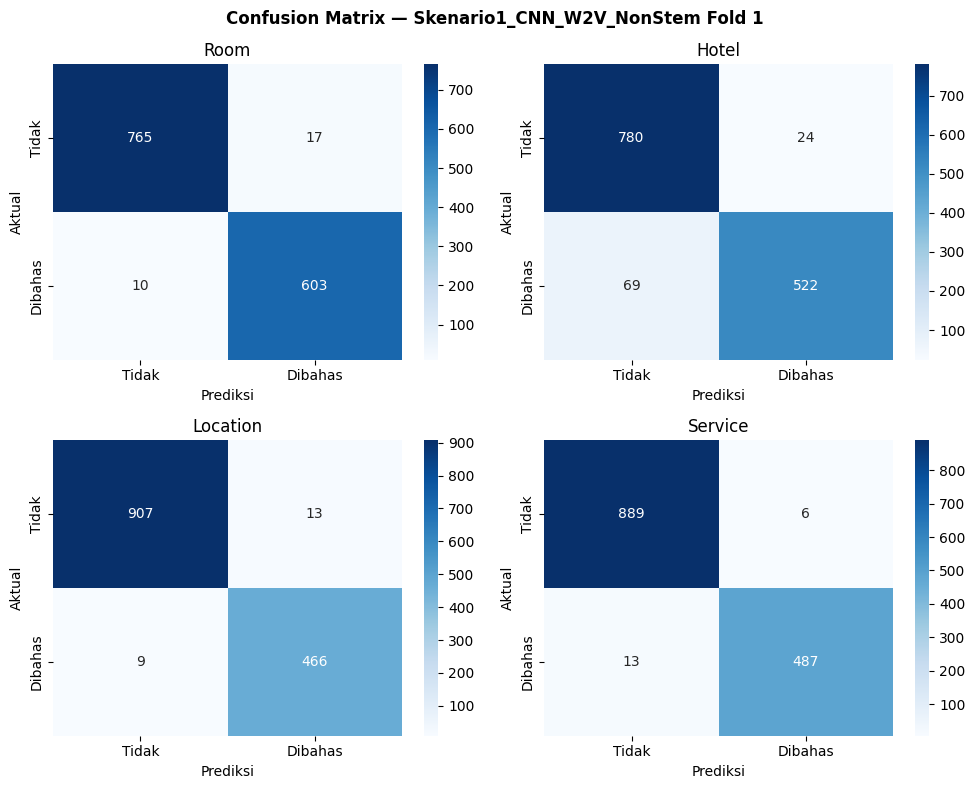

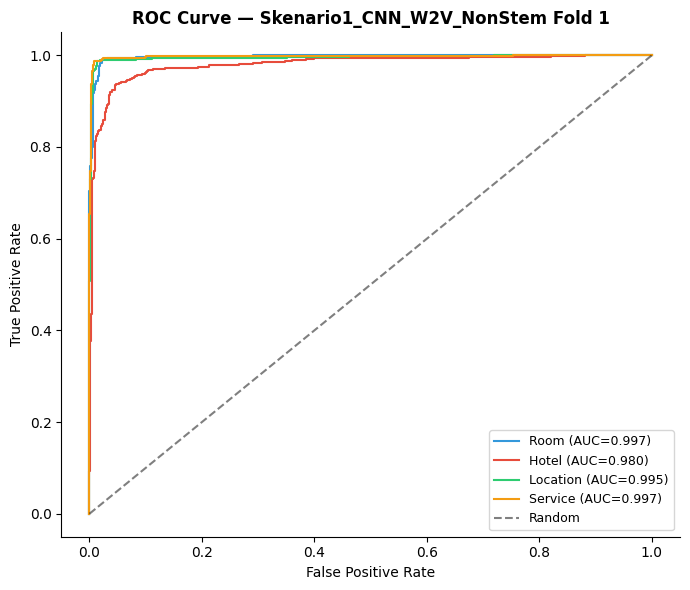


  ── Fold 2/5 ──
  Distribusi label per fold:
    Room      : Pos=2453, Neg=3162
    Hotel     : Pos=2363, Neg=3252
    Location  : Pos=1902, Neg=3713
    Service   : Pos=2000, Neg=3615
Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 13s 59ms/step - accuracy: 0.5902 - auc: 0.8885 - loss: 0.7238 - val_accuracy: 0.7257 - val_auc: 0.9782 - val_loss: 0.4347
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 10s 57ms/step - accuracy: 0.6826 - auc: 0.9685 - loss: 0.4153 - val_accuracy: 0.7101 - val_auc: 0.9866 - val_loss: 0.2978
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.6809 - auc: 0.9795 - loss: 0.3058 - val_accuracy: 0.7279 - val_auc: 0.9892 - val_loss: 0.2392
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 12s 57ms/step - accuracy: 0.6810 - auc: 0.9830 - loss: 0.2536 - val_accuracy: 0.6953 - val_auc: 0.9899 - val_loss: 0.2015
Epoch 5/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 12s 65ms/step - accuracy: 0.6896 - auc: 0.9846 - loss: 0.2265 - val_accuracy: 0.6917 - val_auc: 0.9902 - val_loss: 0.1839
Epoc

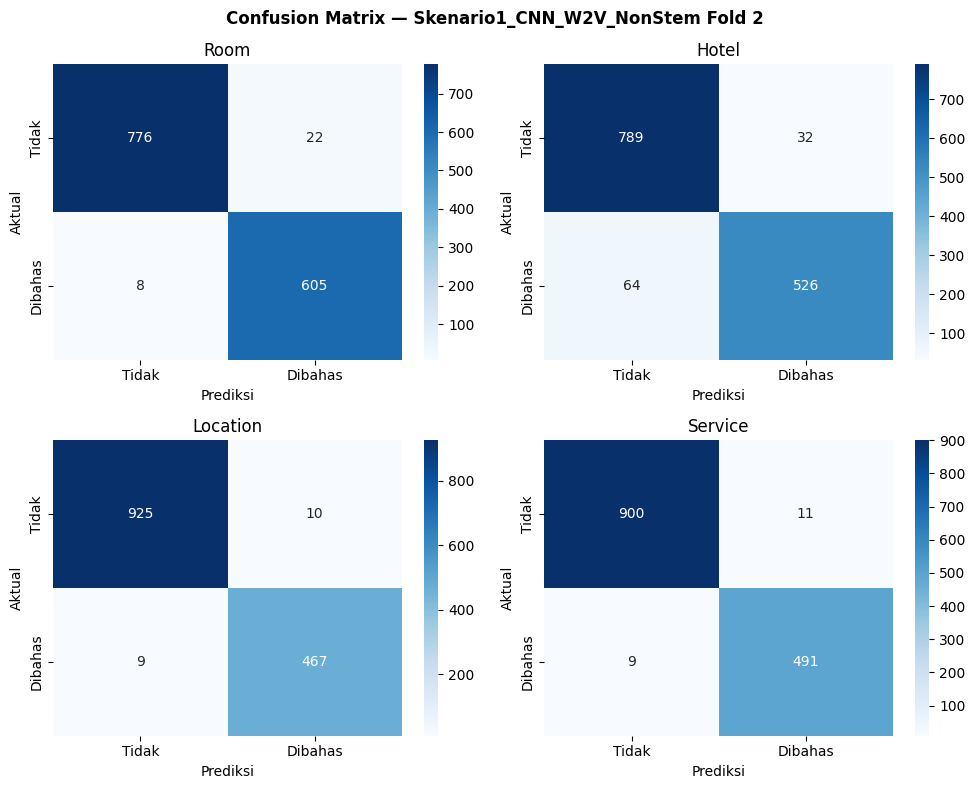

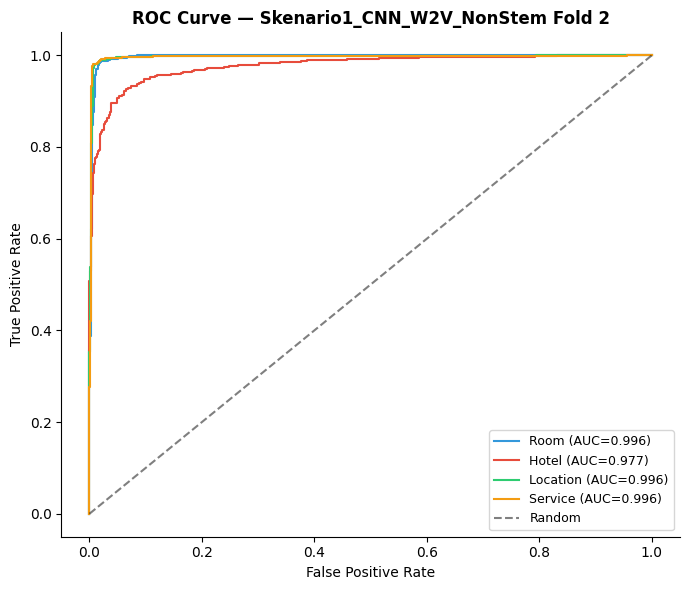


  ── Fold 3/5 ──
  Distribusi label per fold:
    Room      : Pos=2452, Neg=3155
    Hotel     : Pos=2363, Neg=3244
    Location  : Pos=1902, Neg=3705
    Service   : Pos=2000, Neg=3607
Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 14s 65ms/step - accuracy: 0.5841 - auc: 0.8742 - loss: 0.7481 - val_accuracy: 0.6702 - val_auc: 0.9813 - val_loss: 0.4332
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - accuracy: 0.6906 - auc: 0.9670 - loss: 0.4173 - val_accuracy: 0.6779 - val_auc: 0.9884 - val_loss: 0.2888
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 11s 63ms/step - accuracy: 0.6865 - auc: 0.9784 - loss: 0.3092 - val_accuracy: 0.6744 - val_auc: 0.9896 - val_loss: 0.2285
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - accuracy: 0.6811 - auc: 0.9823 - loss: 0.2577 - val_accuracy: 0.6490 - val_auc: 0.9902 - val_loss: 0.1997
Epoch 5/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 11s 61ms/step - accuracy: 0.6790 - auc: 0.9846 - loss: 0.2287 - val_accuracy: 0.6512 - val_auc: 0.9909 - val_loss: 0.1838
Epo

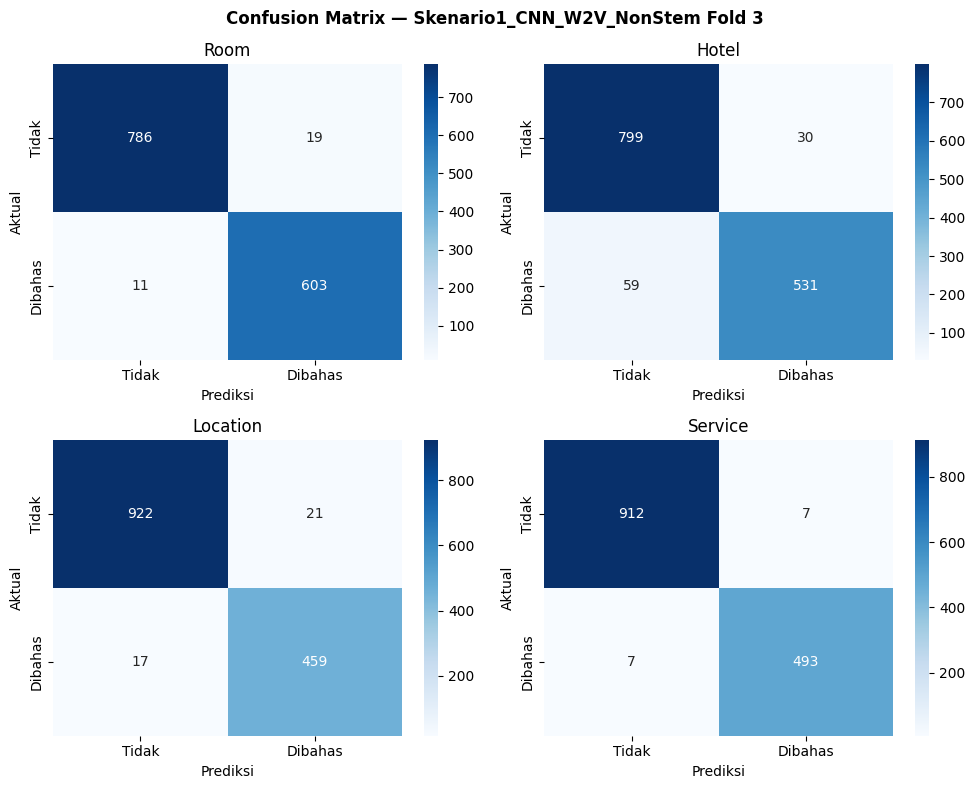

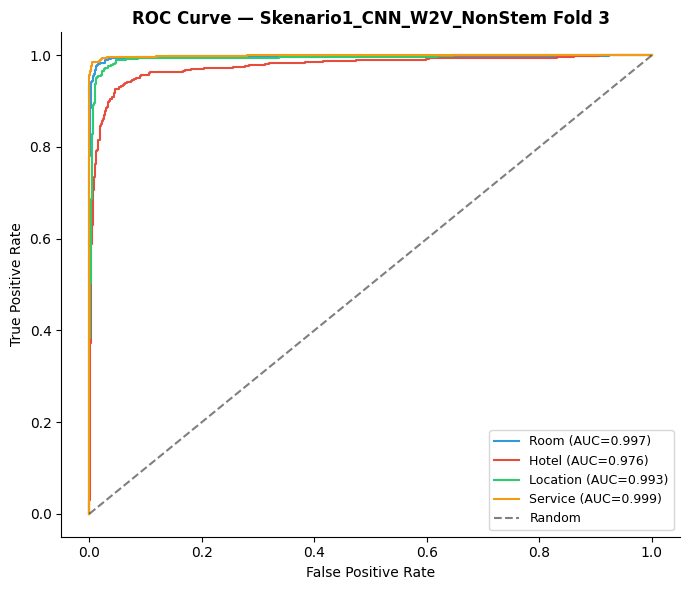


  ── Fold 4/5 ──
  Distribusi label per fold:
    Room      : Pos=2453, Neg=3178
    Hotel     : Pos=2362, Neg=3269
    Location  : Pos=1902, Neg=3729
    Service   : Pos=2000, Neg=3631
Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 14s 63ms/step - accuracy: 0.5709 - auc: 0.8802 - loss: 0.7311 - val_accuracy: 0.6903 - val_auc: 0.9809 - val_loss: 0.4206
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 10s 57ms/step - accuracy: 0.6715 - auc: 0.9680 - loss: 0.4092 - val_accuracy: 0.6767 - val_auc: 0.9891 - val_loss: 0.2845
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 12s 67ms/step - accuracy: 0.6663 - auc: 0.9789 - loss: 0.3029 - val_accuracy: 0.6344 - val_auc: 0.9912 - val_loss: 0.2227
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 10s 57ms/step - accuracy: 0.6725 - auc: 0.9826 - loss: 0.2510 - val_accuracy: 0.6100 - val_auc: 0.9918 - val_loss: 0.1933
Epoch 5/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 11s 63ms/step - accuracy: 0.6720 - auc: 0.9851 - loss: 0.2222 - val_accuracy: 0.5935 - val_auc: 0.9917 - val_loss: 0.1865
Epo

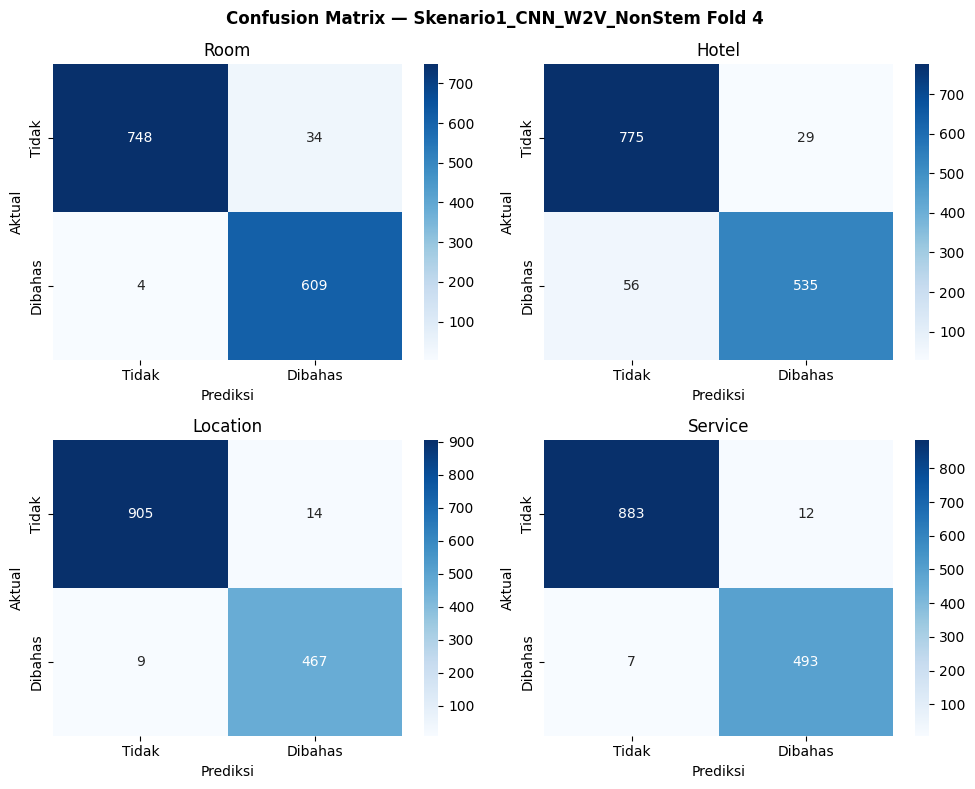

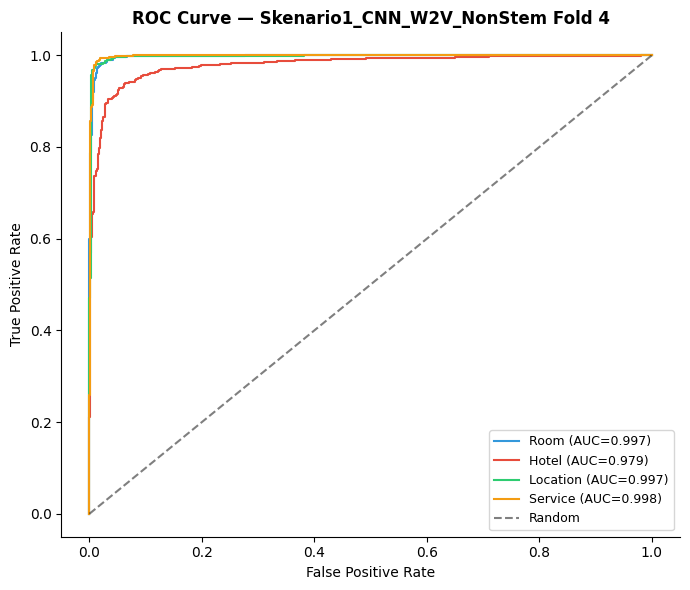


  ── Fold 5/5 ──
  Distribusi label per fold:
    Room      : Pos=2453, Neg=3167
    Hotel     : Pos=2362, Neg=3258
    Location  : Pos=1903, Neg=3717
    Service   : Pos=2000, Neg=3620
Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 14s 65ms/step - accuracy: 0.6082 - auc: 0.8752 - loss: 0.7393 - val_accuracy: 0.7063 - val_auc: 0.9852 - val_loss: 0.4152
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 0.7009 - auc: 0.9664 - loss: 0.4135 - val_accuracy: 0.6671 - val_auc: 0.9914 - val_loss: 0.2791
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.7117 - auc: 0.9793 - loss: 0.3023 - val_accuracy: 0.6458 - val_auc: 0.9924 - val_loss: 0.2227
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 11s 63ms/step - accuracy: 0.7096 - auc: 0.9825 - loss: 0.2565 - val_accuracy: 0.6558 - val_auc: 0.9927 - val_loss: 0.1890
Epoch 5/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - accuracy: 0.7119 - auc: 0.9836 - loss: 0.2294 - val_accuracy: 0.6358 - val_auc: 0.9928 - val_loss: 0.1754
Epoch

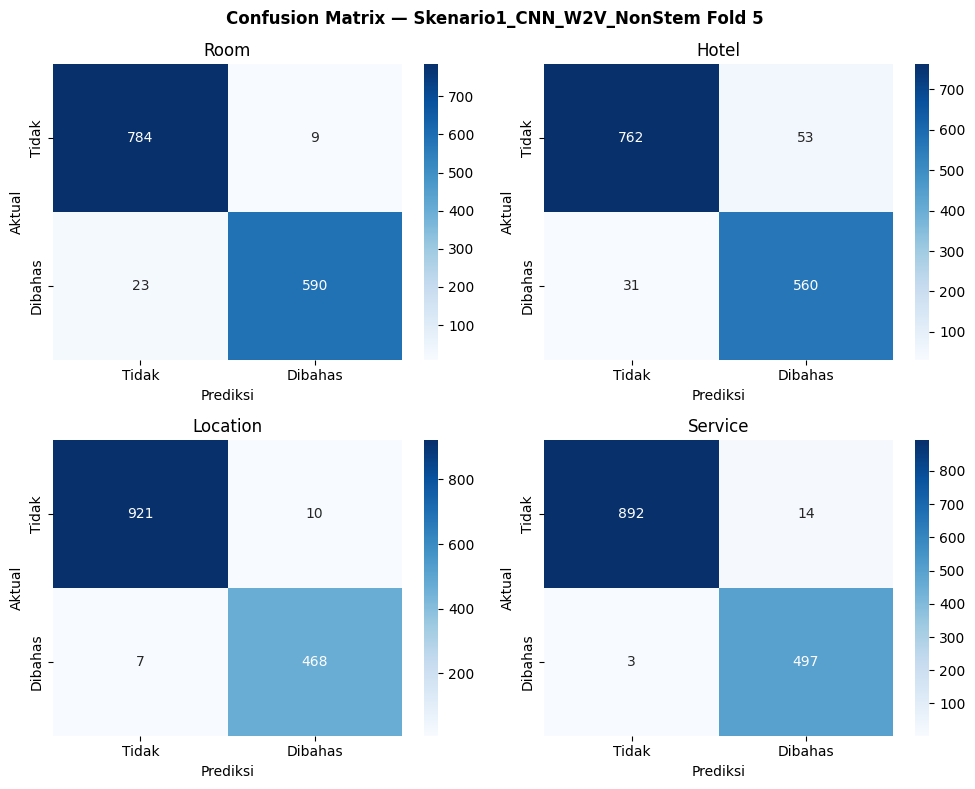

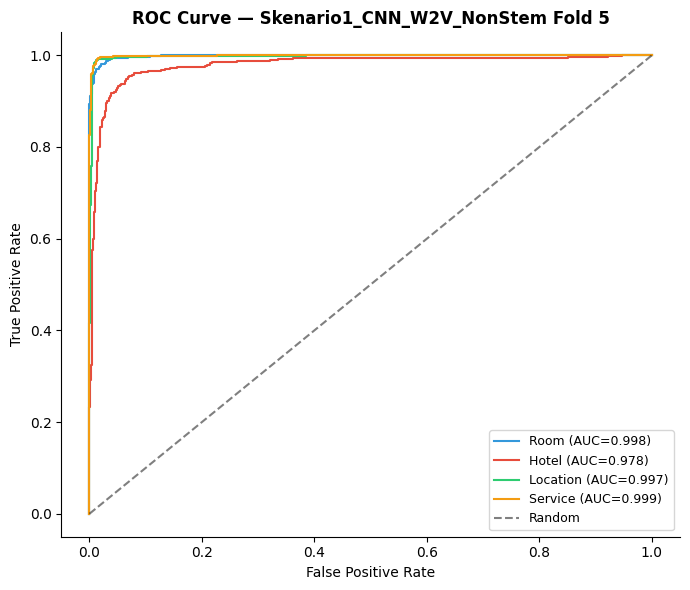


  Model disimpan (fold terakhir): /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task1_Aspek/Skenario1_CNN_W2V_NonStem/model.h5


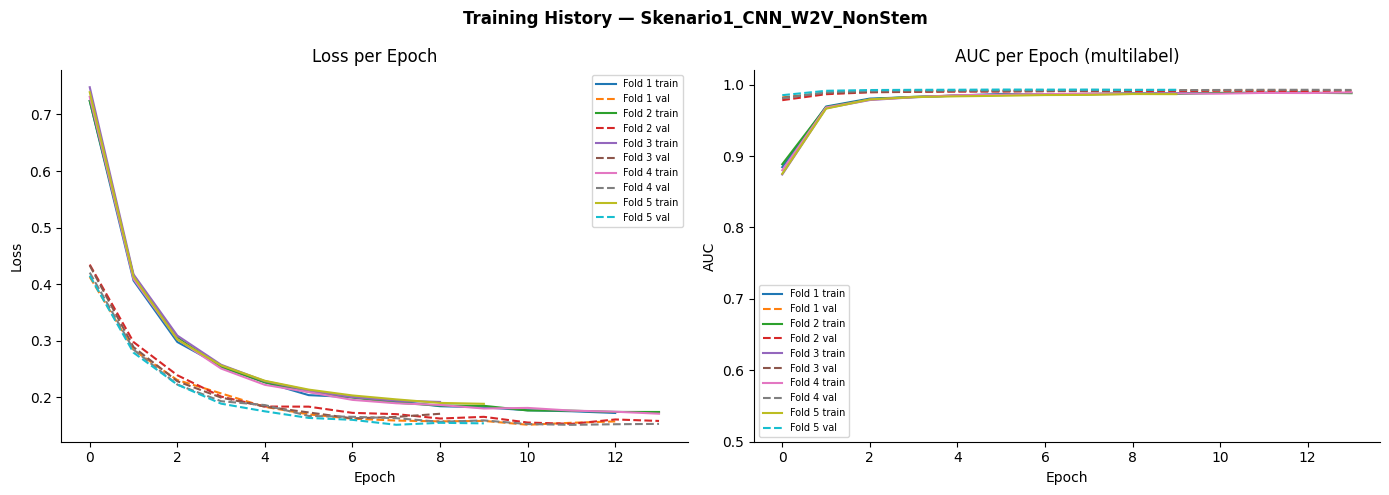


  ╔═ SELESAI: Skenario1_CNN_W2V_NonStem
  ║  avg Precision  : 0.9653 ± 0.0045
  ║  avg Recall     : 0.9626 ± 0.0068
  ║  avg F1 Macro   : 0.9637 ± 0.0022
  ║  avg Accuracy   : 0.9711 ± 0.0013
  ║  avg AUC Macro  : 0.9921 ± 0.0009
  ║  avg RAM        : 2611.0 MB (20.1%)
  ║  avg CPU        : 5.2 %
  ║  avg Waktu      : 138.56 detik/fold
  ║  avg T/Epoch    : 11.49 detik/epoch
  ║  avg T/Step     : 0.0657 detik/step
  ╚══════════════════════════════════════════════════


In [ ]:
# Training Skenario 1 (CNN_W2V_NonStem)
jalankan_skenario(skenario_list[0])


  Training: Skenario2_CNN_W2V_Stem
  Membuat embedding matrix...
  Vocab tokenizer : 3,812 kata
  OOV             : 1,351 kata tidak ditemukan di embedding
  Shape matrix    : (3812, 100)

  ── Fold 1/5 ──
  Distribusi label per fold:
    Room      : Pos=2453, Neg=3178
    Hotel     : Pos=2362, Neg=3269
    Location  : Pos=1903, Neg=3728
    Service   : Pos=2000, Neg=3631
Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 14s 55ms/step - accuracy: 0.5901 - auc: 0.8878 - loss: 0.7214 - val_accuracy: 0.6667 - val_auc: 0.9815 - val_loss: 0.4186
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 11s 60ms/step - accuracy: 0.6736 - auc: 0.9680 - loss: 0.4132 - val_accuracy: 0.6688 - val_auc: 0.9879 - val_loss: 0.2857
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.6709 - auc: 0.9786 - loss: 0.3066 - val_accuracy: 0.6573 - val_auc: 0.9896 - val_loss: 0.2268
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - accuracy: 0.6857 - auc: 0.9827 - loss: 0.2553 - val_accuracy: 0.6703 - val_auc: 0.9

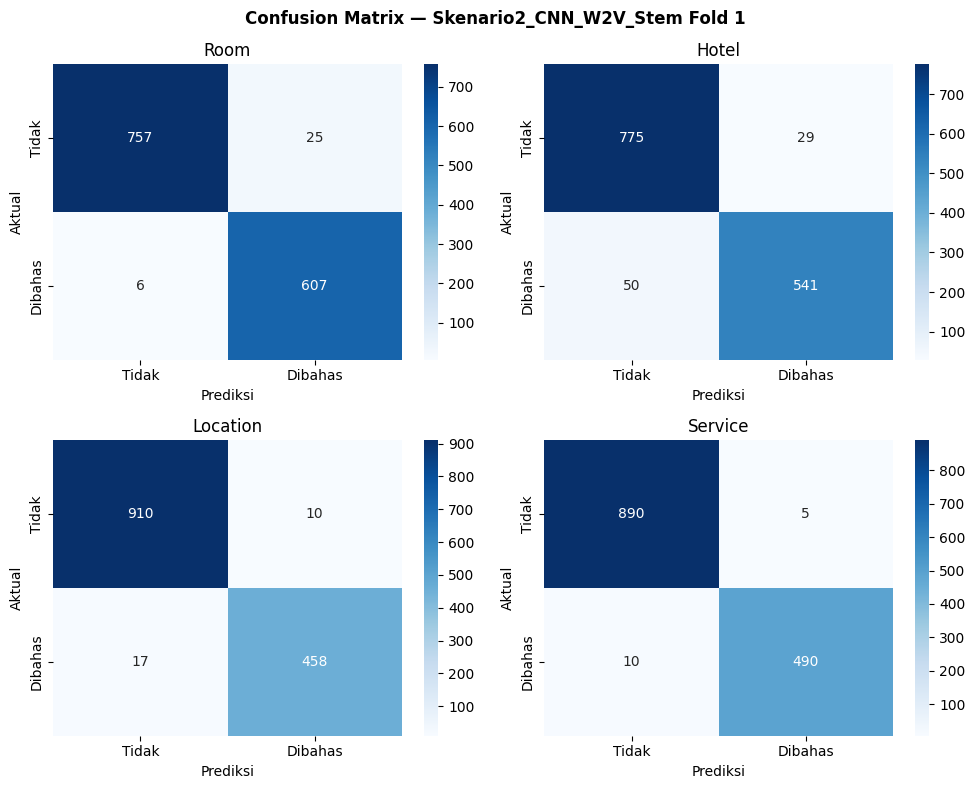

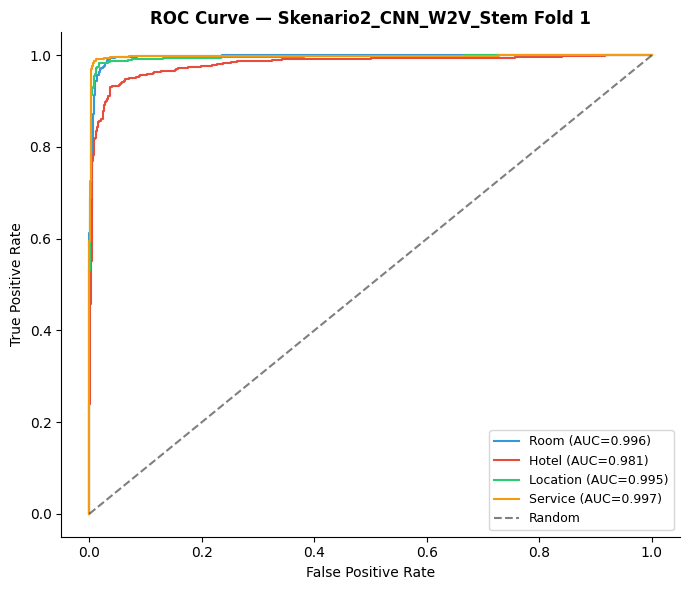


  ── Fold 2/5 ──
  Distribusi label per fold:
    Room      : Pos=2453, Neg=3162
    Hotel     : Pos=2363, Neg=3252
    Location  : Pos=1902, Neg=3713
    Service   : Pos=2000, Neg=3615
Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 14s 61ms/step - accuracy: 0.6075 - auc: 0.8868 - loss: 0.7265 - val_accuracy: 0.7108 - val_auc: 0.9802 - val_loss: 0.4260
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.6928 - auc: 0.9693 - loss: 0.4106 - val_accuracy: 0.7045 - val_auc: 0.9874 - val_loss: 0.2921
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.6933 - auc: 0.9802 - loss: 0.3043 - val_accuracy: 0.7137 - val_auc: 0.9892 - val_loss: 0.2316
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.6921 - auc: 0.9833 - loss: 0.2539 - val_accuracy: 0.7002 - val_auc: 0.9900 - val_loss: 0.1985
Epoch 5/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.6974 - auc: 0.9855 - loss: 0.2239 - val_accuracy: 0.6704 - val_auc: 0.9906 - val_loss: 0.1809
Epoch

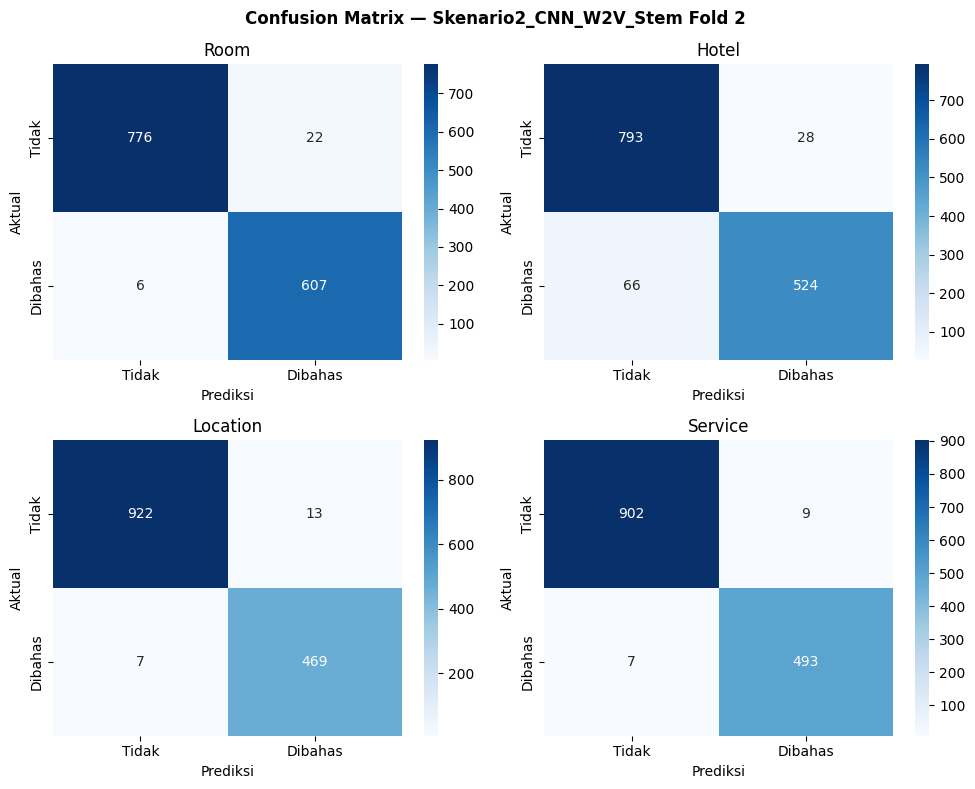

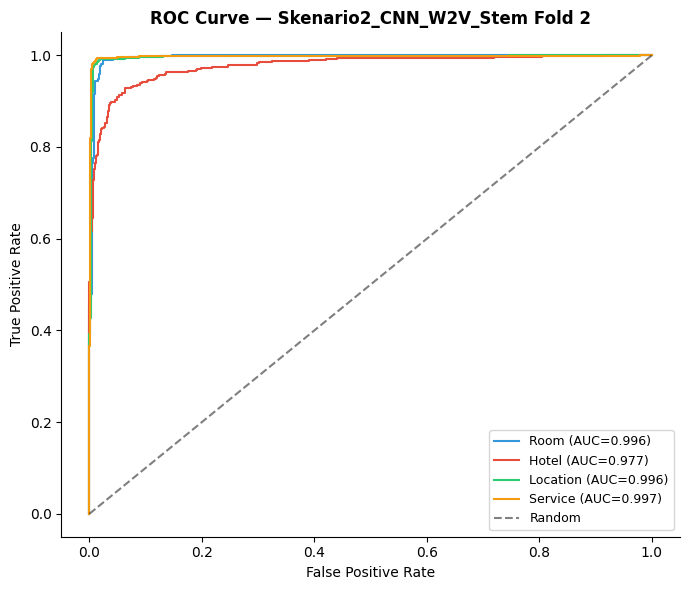


  ── Fold 3/5 ──
  Distribusi label per fold:
    Room      : Pos=2452, Neg=3155
    Hotel     : Pos=2363, Neg=3244
    Location  : Pos=1902, Neg=3705
    Service   : Pos=2000, Neg=3607
Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 14s 62ms/step - accuracy: 0.5887 - auc: 0.8739 - loss: 0.7448 - val_accuracy: 0.7054 - val_auc: 0.9828 - val_loss: 0.4189
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.6881 - auc: 0.9656 - loss: 0.4187 - val_accuracy: 0.7442 - val_auc: 0.9882 - val_loss: 0.2868
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - accuracy: 0.6916 - auc: 0.9769 - loss: 0.3111 - val_accuracy: 0.7470 - val_auc: 0.9905 - val_loss: 0.2267
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.6940 - auc: 0.9830 - loss: 0.2518 - val_accuracy: 0.6885 - val_auc: 0.9903 - val_loss: 0.1972
Epoch 5/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 12s 58ms/step - accuracy: 0.6986 - auc: 0.9835 - loss: 0.2301 - val_accuracy: 0.6709 - val_auc: 0.9917 - val_loss: 0.1785
Epoc

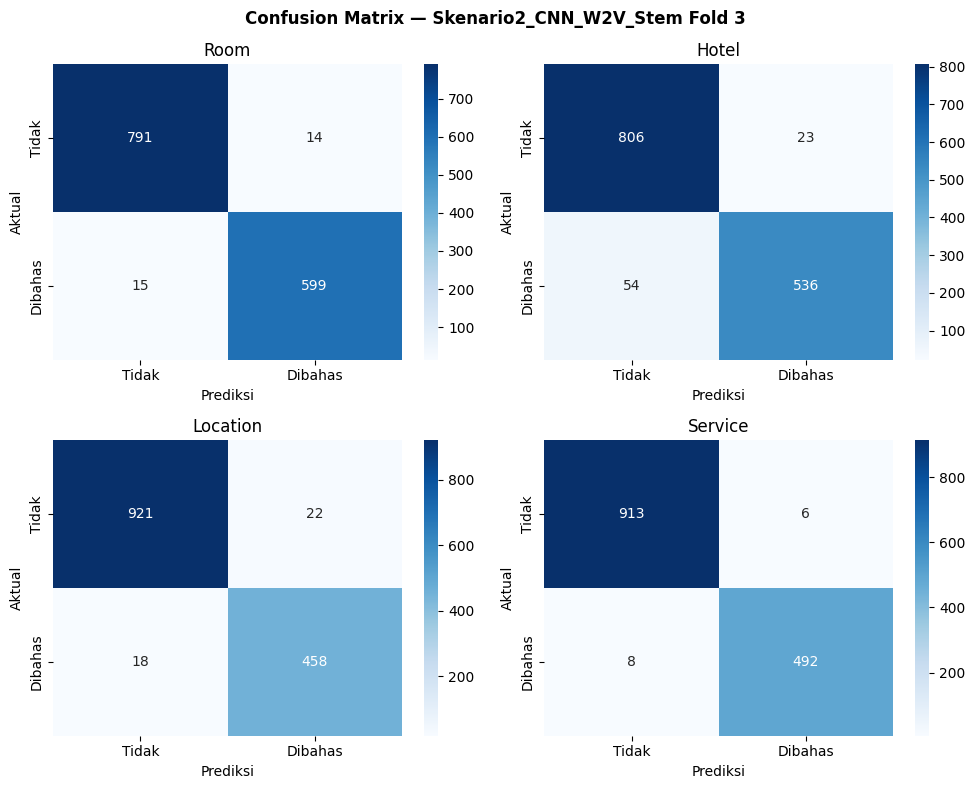

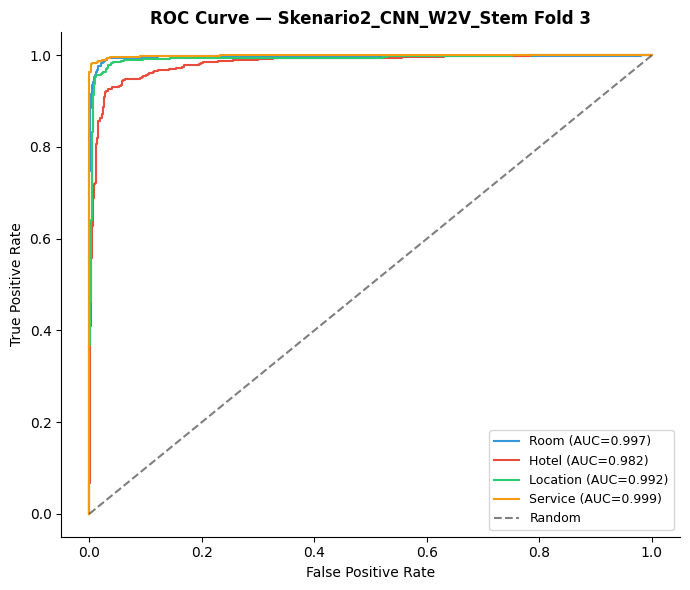


  ── Fold 4/5 ──
  Distribusi label per fold:
    Room      : Pos=2453, Neg=3178
    Hotel     : Pos=2362, Neg=3269
    Location  : Pos=1902, Neg=3729
    Service   : Pos=2000, Neg=3631
Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 14s 63ms/step - accuracy: 0.5859 - auc: 0.8774 - loss: 0.7342 - val_accuracy: 0.7204 - val_auc: 0.9818 - val_loss: 0.4166
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - accuracy: 0.6871 - auc: 0.9688 - loss: 0.4023 - val_accuracy: 0.6781 - val_auc: 0.9898 - val_loss: 0.2743
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 12s 61ms/step - accuracy: 0.6878 - auc: 0.9802 - loss: 0.2953 - val_accuracy: 0.6824 - val_auc: 0.9913 - val_loss: 0.2181
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 11s 60ms/step - accuracy: 0.6789 - auc: 0.9815 - loss: 0.2549 - val_accuracy: 0.6559 - val_auc: 0.9911 - val_loss: 0.2003
Epoch 5/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.6826 - auc: 0.9840 - loss: 0.2237 - val_accuracy: 0.7047 - val_auc: 0.9916 - val_loss: 0.1819
Epoch

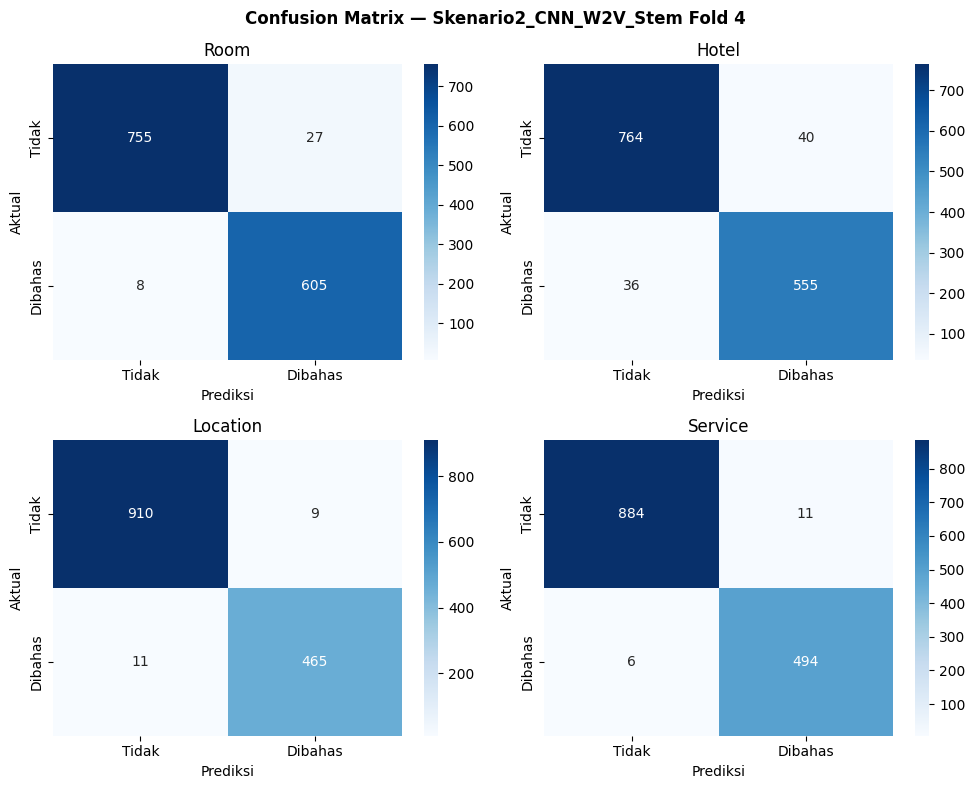

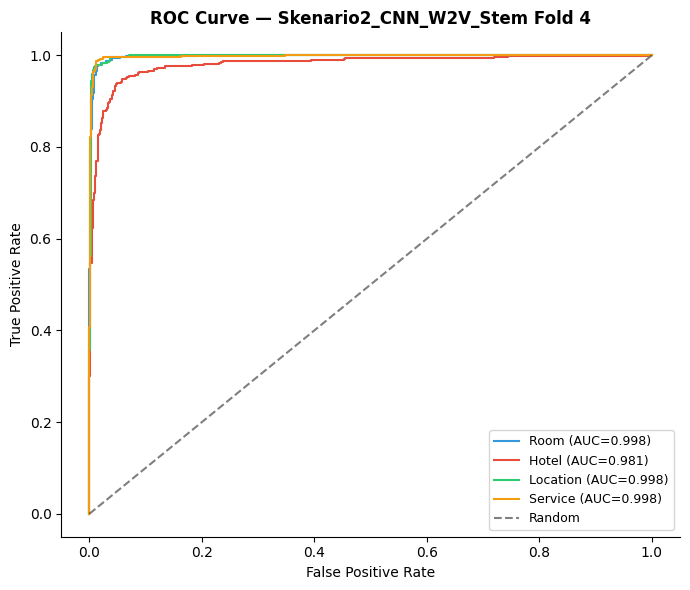


  ── Fold 5/5 ──
  Distribusi label per fold:
    Room      : Pos=2453, Neg=3167
    Hotel     : Pos=2362, Neg=3258
    Location  : Pos=1903, Neg=3717
    Service   : Pos=2000, Neg=3620
Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 14s 55ms/step - accuracy: 0.5968 - auc: 0.8882 - loss: 0.7204 - val_accuracy: 0.6885 - val_auc: 0.9871 - val_loss: 0.4054
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 11s 61ms/step - accuracy: 0.6827 - auc: 0.9692 - loss: 0.4070 - val_accuracy: 0.6287 - val_auc: 0.9918 - val_loss: 0.2721
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 11s 62ms/step - accuracy: 0.6854 - auc: 0.9788 - loss: 0.3053 - val_accuracy: 0.6437 - val_auc: 0.9928 - val_loss: 0.2183
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - accuracy: 0.6884 - auc: 0.9824 - loss: 0.2557 - val_accuracy: 0.5932 - val_auc: 0.9930 - val_loss: 0.1914
Epoch 5/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 11s 65ms/step - accuracy: 0.6961 - auc: 0.9843 - loss: 0.2278 - val_accuracy: 0.6081 - val_auc: 0.9935 - val_loss: 0.1717
Epo

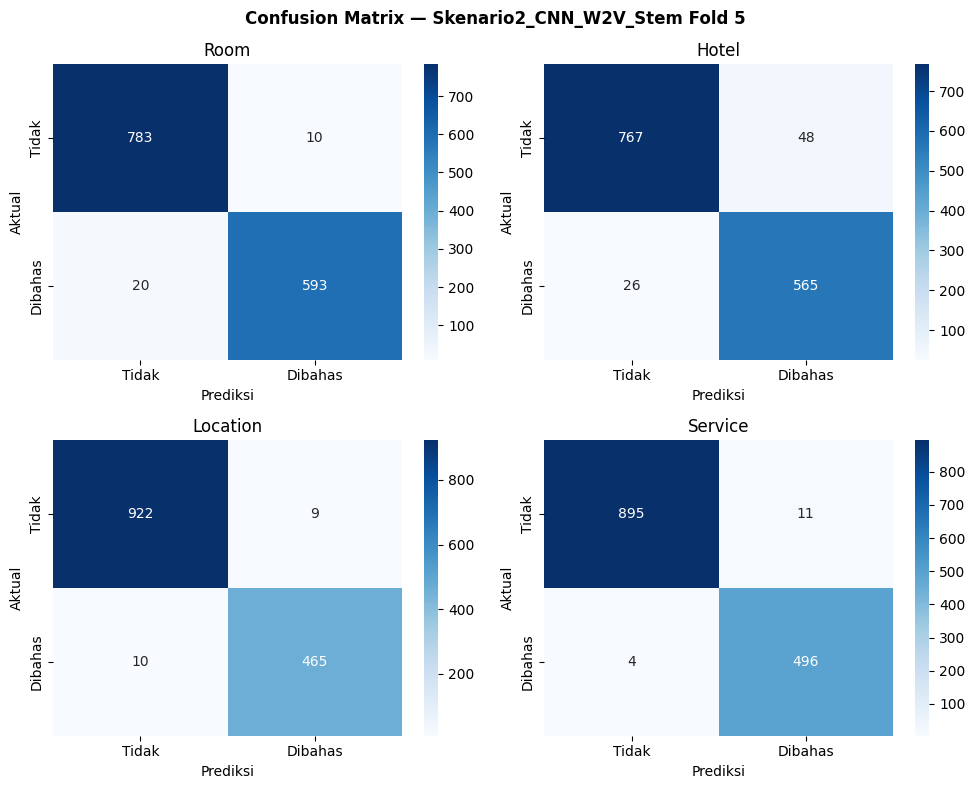

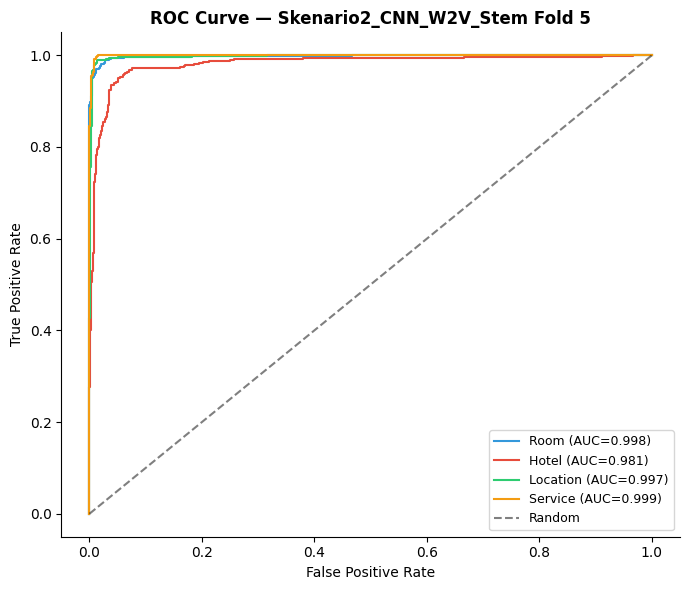


  Model disimpan (fold terakhir): /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task1_Aspek/Skenario2_CNN_W2V_Stem/model.h5


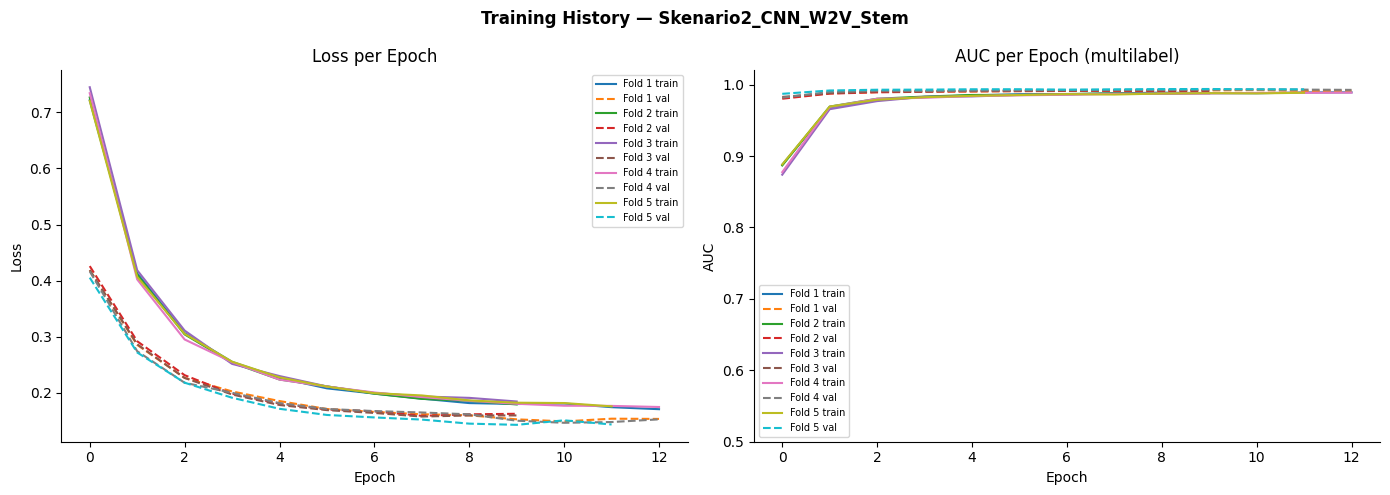


  ╔═ SELESAI: Skenario2_CNN_W2V_Stem
  ║  avg Precision  : 0.9670 ± 0.0030
  ║  avg Recall     : 0.9657 ± 0.0071
  ║  avg F1 Macro   : 0.9662 ± 0.0025
  ║  avg Accuracy   : 0.9731 ± 0.0015
  ║  avg AUC Macro  : 0.9927 ± 0.0011
  ║  avg RAM        : 4152.2 MB (32.0%)
  ║  avg CPU        : 34.8 %
  ║  avg Waktu      : 138.84 detik/fold
  ║  avg T/Epoch    : 11.80 detik/epoch
  ║  avg T/Step     : 0.0675 detik/step
  ╚══════════════════════════════════════════════════


In [ ]:
# Training Skenario 2 (CNN_W2V_Stem)
jalankan_skenario(skenario_list[1])


  Training: Skenario3_CNN_FT_NonStem
  Membuat embedding matrix...
  Vocab tokenizer : 5,546 kata
  OOV             : 0 kata tidak ditemukan di embedding
  Shape matrix    : (5546, 100)

  ── Fold 1/5 ──
  Distribusi label per fold:
    Room      : Pos=2453, Neg=3178
    Hotel     : Pos=2362, Neg=3269
    Location  : Pos=1903, Neg=3728
    Service   : Pos=2000, Neg=3631
Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 14s 61ms/step - accuracy: 0.5951 - auc: 0.8776 - loss: 0.7374 - val_accuracy: 0.7054 - val_auc: 0.9816 - val_loss: 0.4291
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.6850 - auc: 0.9671 - loss: 0.4134 - val_accuracy: 0.7305 - val_auc: 0.9881 - val_loss: 0.2952
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.6896 - auc: 0.9776 - loss: 0.3119 - val_accuracy: 0.6609 - val_auc: 0.9900 - val_loss: 0.2269
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 10s 57ms/step - accuracy: 0.6949 - auc: 0.9807 - loss: 0.2610 - val_accuracy: 0.7190 - val_auc: 0.991

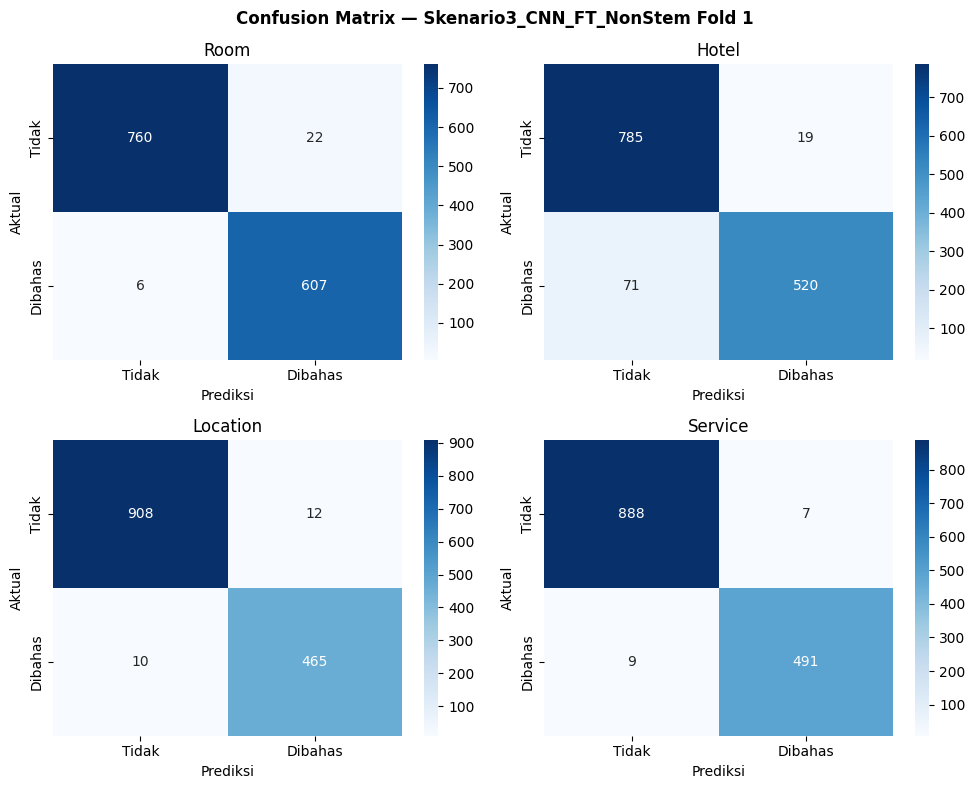

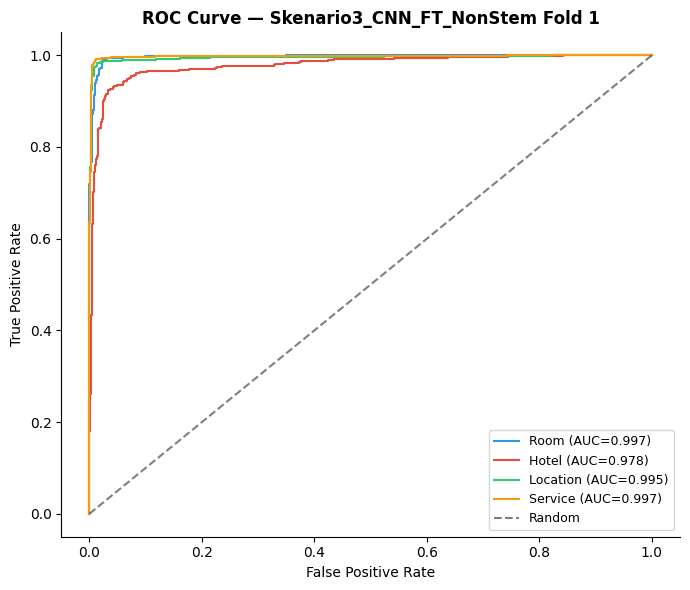


  ── Fold 2/5 ──
  Distribusi label per fold:
    Room      : Pos=2453, Neg=3162
    Hotel     : Pos=2363, Neg=3252
    Location  : Pos=1902, Neg=3713
    Service   : Pos=2000, Neg=3615
Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 14s 65ms/step - accuracy: 0.5802 - auc: 0.8727 - loss: 0.7417 - val_accuracy: 0.7009 - val_auc: 0.9785 - val_loss: 0.4270
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - accuracy: 0.6796 - auc: 0.9672 - loss: 0.4074 - val_accuracy: 0.6896 - val_auc: 0.9867 - val_loss: 0.2858
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step - accuracy: 0.6874 - auc: 0.9792 - loss: 0.3001 - val_accuracy: 0.6655 - val_auc: 0.9888 - val_loss: 0.2329
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 11s 62ms/step - accuracy: 0.6766 - auc: 0.9814 - loss: 0.2568 - val_accuracy: 0.6641 - val_auc: 0.9900 - val_loss: 0.1992
Epoch 5/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.6796 - auc: 0.9848 - loss: 0.2256 - val_accuracy: 0.6619 - val_auc: 0.9895 - val_loss: 0.1865
Epoch

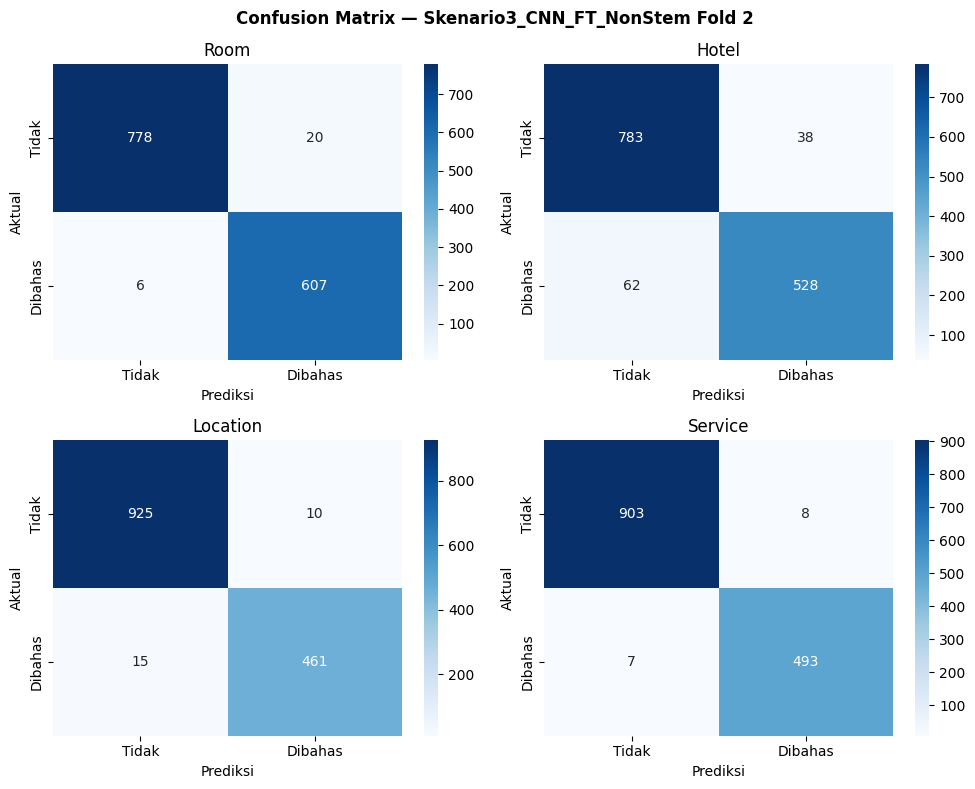

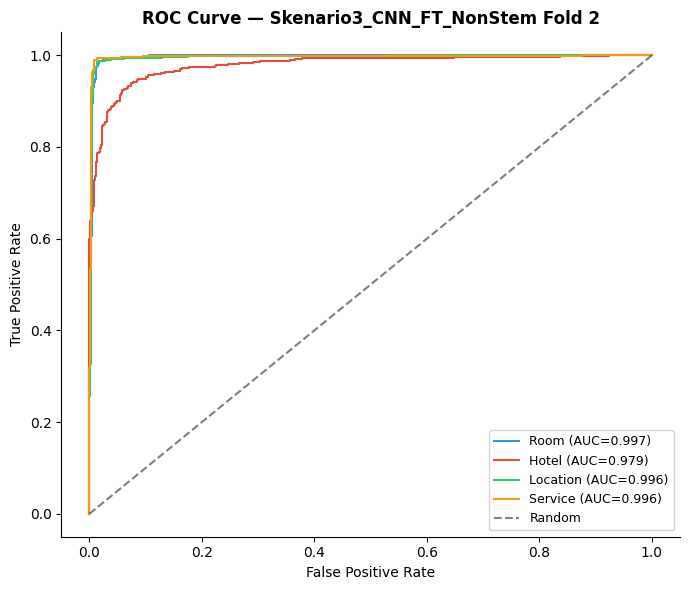


  ── Fold 3/5 ──
  Distribusi label per fold:
    Room      : Pos=2452, Neg=3155
    Hotel     : Pos=2363, Neg=3244
    Location  : Pos=1902, Neg=3705
    Service   : Pos=2000, Neg=3607
Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 14s 65ms/step - accuracy: 0.6121 - auc: 0.8728 - loss: 0.7401 - val_accuracy: 0.7153 - val_auc: 0.9813 - val_loss: 0.4043
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 18s 51ms/step - accuracy: 0.6931 - auc: 0.9661 - loss: 0.4068 - val_accuracy: 0.7393 - val_auc: 0.9886 - val_loss: 0.2814
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 12s 62ms/step - accuracy: 0.6984 - auc: 0.9772 - loss: 0.3065 - val_accuracy: 0.7005 - val_auc: 0.9901 - val_loss: 0.2248
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 10s 57ms/step - accuracy: 0.6913 - auc: 0.9813 - loss: 0.2543 - val_accuracy: 0.6730 - val_auc: 0.9906 - val_loss: 0.1973
Epoch 5/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.6913 - auc: 0.9828 - loss: 0.2327 - val_accuracy: 0.6307 - val_auc: 0.9909 - val_loss: 0.1849
Epoc

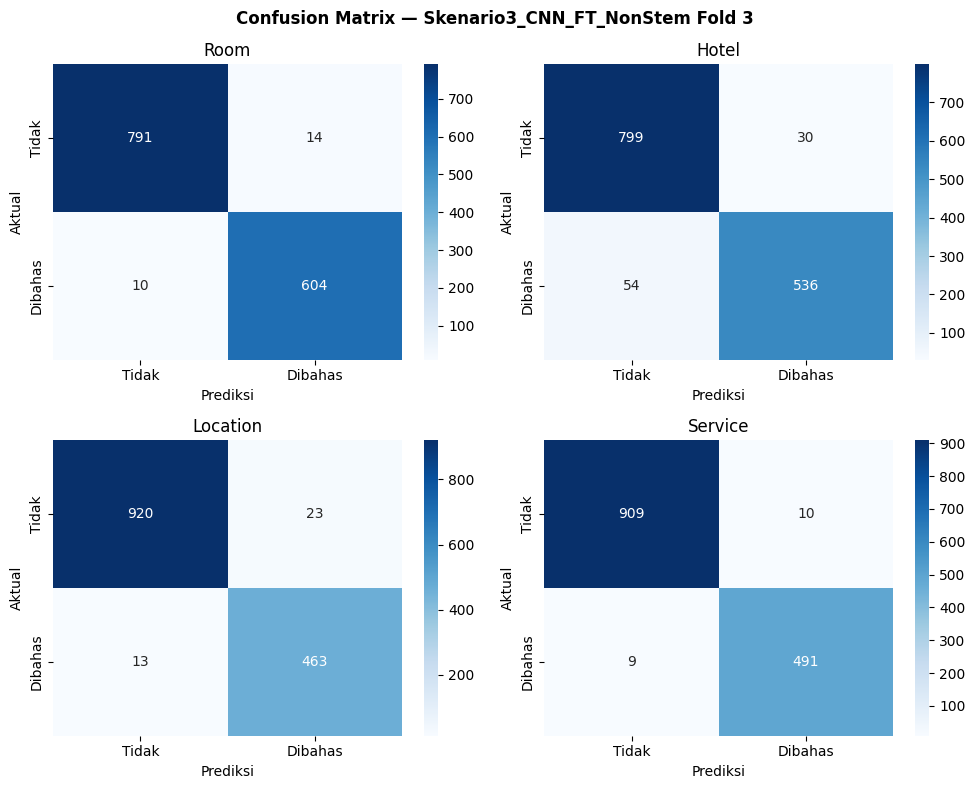

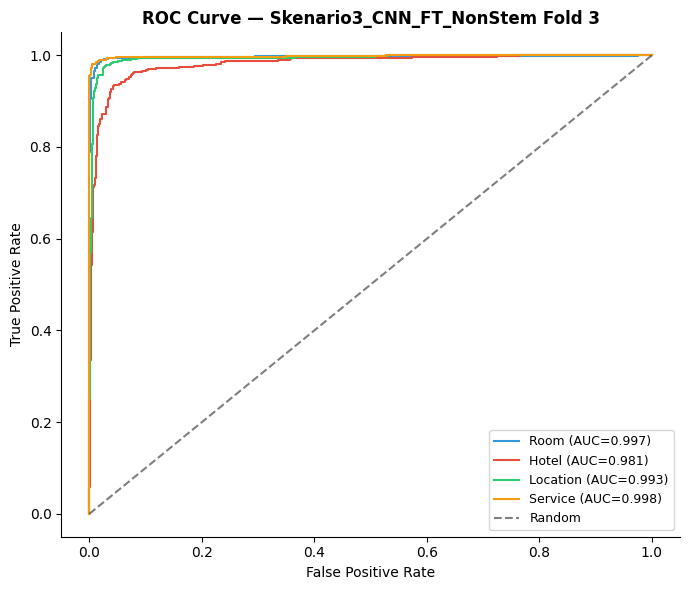


  ── Fold 4/5 ──
  Distribusi label per fold:
    Room      : Pos=2453, Neg=3178
    Hotel     : Pos=2362, Neg=3269
    Location  : Pos=1902, Neg=3729
    Service   : Pos=2000, Neg=3631
Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 15s 65ms/step - accuracy: 0.5734 - auc: 0.8780 - loss: 0.7288 - val_accuracy: 0.6659 - val_auc: 0.9810 - val_loss: 0.4193
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - accuracy: 0.6837 - auc: 0.9680 - loss: 0.4055 - val_accuracy: 0.6480 - val_auc: 0.9888 - val_loss: 0.2815
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 11s 62ms/step - accuracy: 0.6821 - auc: 0.9772 - loss: 0.3065 - val_accuracy: 0.6910 - val_auc: 0.9900 - val_loss: 0.2382
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 18s 49ms/step - accuracy: 0.6807 - auc: 0.9815 - loss: 0.2570 - val_accuracy: 0.6459 - val_auc: 0.9909 - val_loss: 0.1981
Epoch 5/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 11s 62ms/step - accuracy: 0.6855 - auc: 0.9837 - loss: 0.2268 - val_accuracy: 0.5935 - val_auc: 0.9914 - val_loss: 0.1808
Epoc

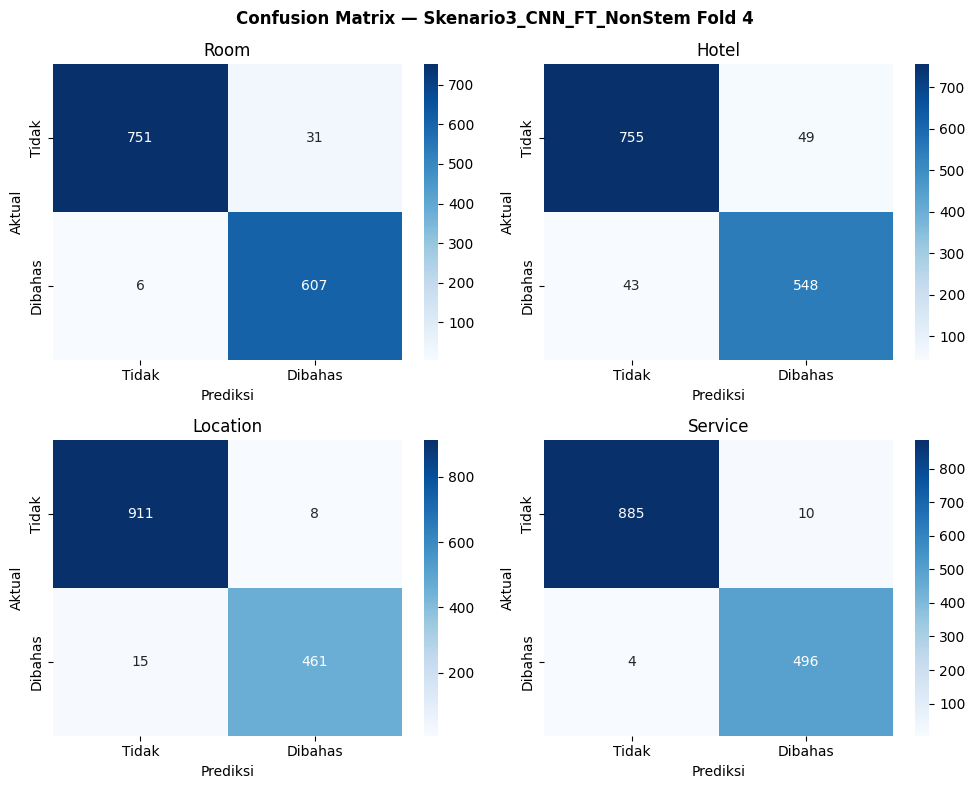

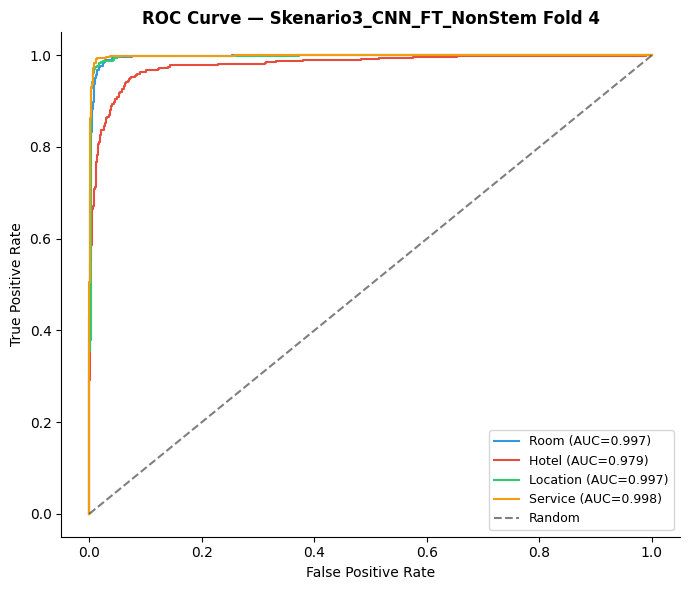


  ── Fold 5/5 ──
  Distribusi label per fold:
    Room      : Pos=2453, Neg=3167
    Hotel     : Pos=2362, Neg=3258
    Location  : Pos=1903, Neg=3717
    Service   : Pos=2000, Neg=3620
Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 16s 65ms/step - accuracy: 0.5877 - auc: 0.8821 - loss: 0.7296 - val_accuracy: 0.6664 - val_auc: 0.9852 - val_loss: 0.4108
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 11s 61ms/step - accuracy: 0.6779 - auc: 0.9676 - loss: 0.4114 - val_accuracy: 0.7226 - val_auc: 0.9909 - val_loss: 0.2767
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 11s 61ms/step - accuracy: 0.6884 - auc: 0.9792 - loss: 0.3040 - val_accuracy: 0.6095 - val_auc: 0.9920 - val_loss: 0.2194
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - accuracy: 0.6817 - auc: 0.9821 - loss: 0.2562 - val_accuracy: 0.6245 - val_auc: 0.9925 - val_loss: 0.1890
Epoch 5/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 11s 65ms/step - accuracy: 0.6900 - auc: 0.9847 - loss: 0.2274 - val_accuracy: 0.6174 - val_auc: 0.9926 - val_loss: 0.1803
Epoc

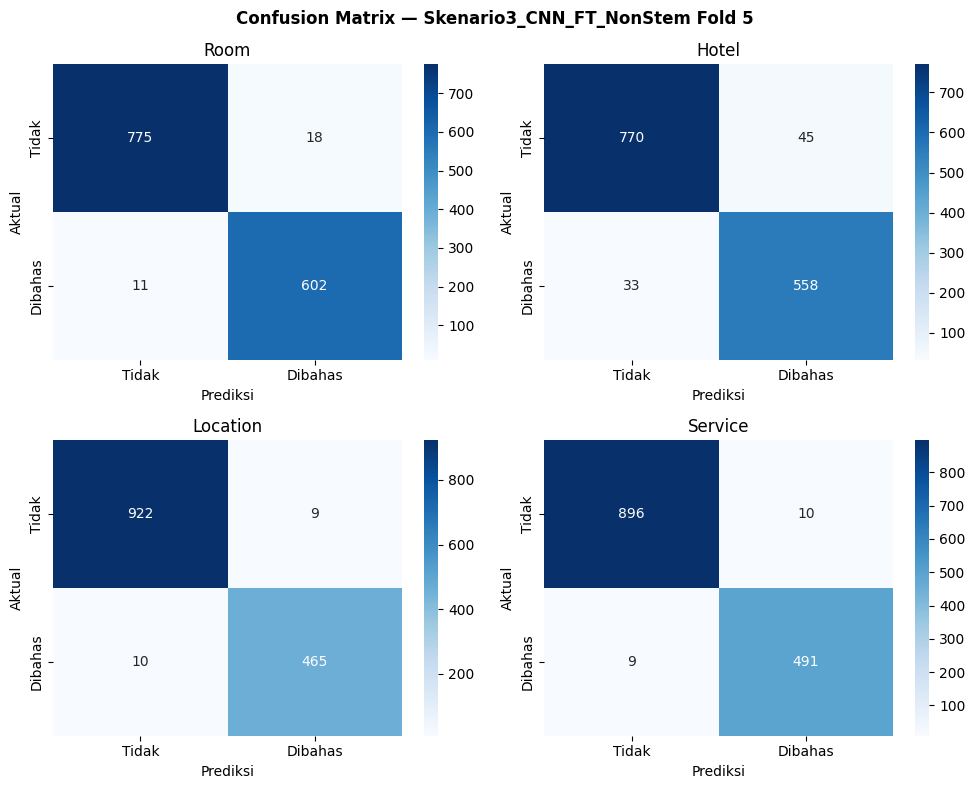

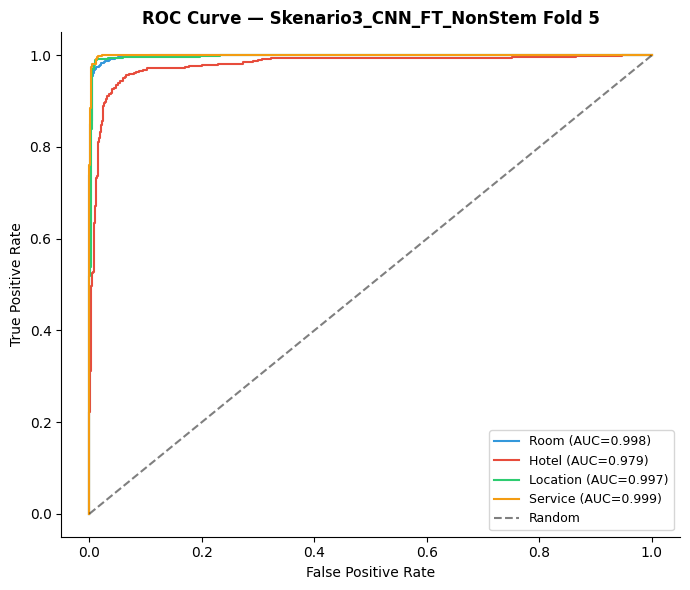


  Model disimpan (fold terakhir): /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task1_Aspek/Skenario3_CNN_FT_NonStem/model.h5


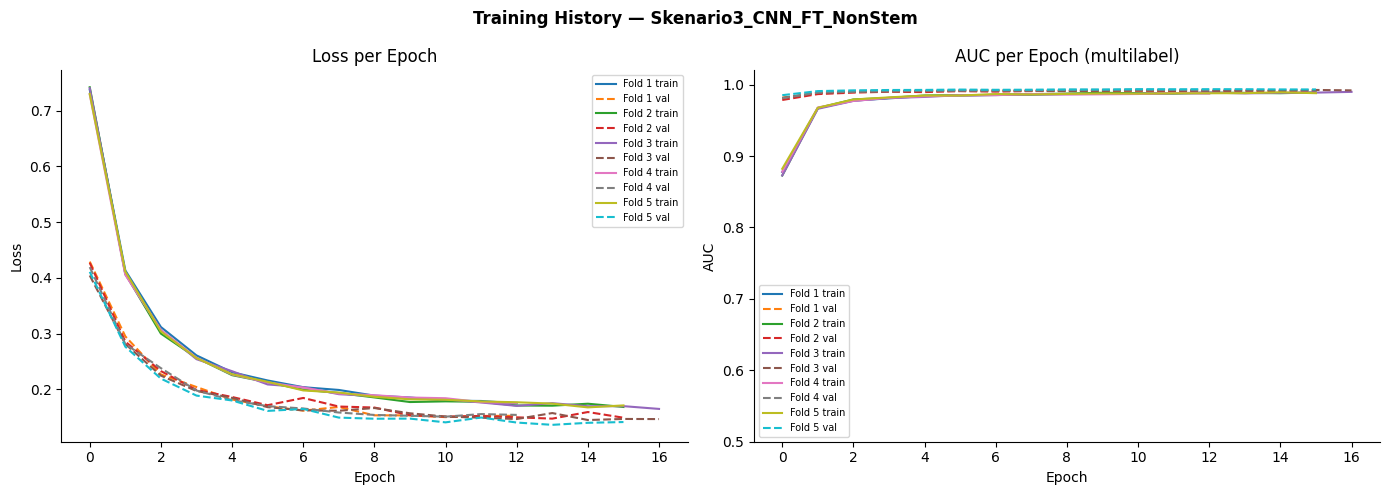


  ╔═ SELESAI: Skenario3_CNN_FT_NonStem
  ║  avg Precision  : 0.9651 ± 0.0052
  ║  avg Recall     : 0.9641 ± 0.0062
  ║  avg F1 Macro   : 0.9644 ± 0.0022
  ║  avg Accuracy   : 0.9717 ± 0.0016
  ║  avg AUC Macro  : 0.9924 ± 0.0008
  ║  avg RAM        : 4290.3 MB (33.1%)
  ║  avg CPU        : 2.8 %
  ║  avg Waktu      : 174.96 detik/fold
  ║  avg T/Epoch    : 11.50 detik/epoch
  ║  avg T/Step     : 0.0657 detik/step
  ╚══════════════════════════════════════════════════


In [ ]:
# Training Skenario 3 (CNN_FT_NonStem)
jalankan_skenario(skenario_list[2])


  Training: Skenario4_CNN_FT_Stem
  Membuat embedding matrix...
  Vocab tokenizer : 3,812 kata
  OOV             : 0 kata tidak ditemukan di embedding
  Shape matrix    : (3812, 100)

  ── Fold 1/5 ──
  Distribusi label per fold:
    Room      : Pos=2453, Neg=3178
    Hotel     : Pos=2362, Neg=3269
    Location  : Pos=1903, Neg=3728
    Service   : Pos=2000, Neg=3631
Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - accuracy: 0.6020 - auc: 0.8751 - loss: 0.7395 - val_accuracy: 0.7090 - val_auc: 0.9815 - val_loss: 0.4175
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 10s 57ms/step - accuracy: 0.6965 - auc: 0.9669 - loss: 0.4101 - val_accuracy: 0.6832 - val_auc: 0.9884 - val_loss: 0.2878
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 11s 60ms/step - accuracy: 0.6944 - auc: 0.9763 - loss: 0.3098 - val_accuracy: 0.6982 - val_auc: 0.9901 - val_loss: 0.2235
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.7001 - auc: 0.9811 - loss: 0.2603 - val_accuracy: 0.7039 - val_auc: 0.9906 

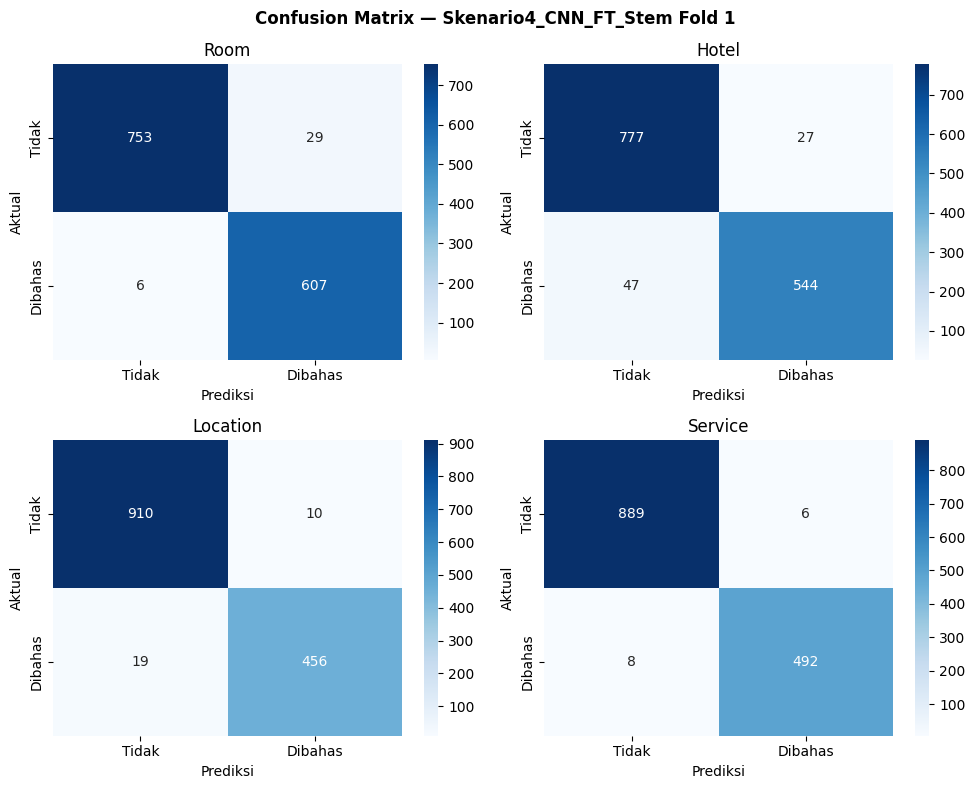

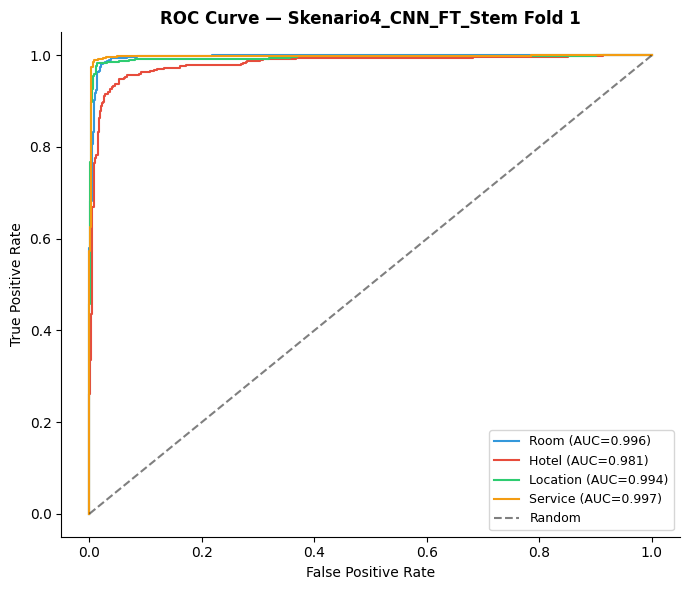


  ── Fold 2/5 ──
  Distribusi label per fold:
    Room      : Pos=2453, Neg=3162
    Hotel     : Pos=2363, Neg=3252
    Location  : Pos=1902, Neg=3713
    Service   : Pos=2000, Neg=3615
Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step - accuracy: 0.6100 - auc: 0.8819 - loss: 0.7252 - val_accuracy: 0.6917 - val_auc: 0.9806 - val_loss: 0.4162
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.6887 - auc: 0.9689 - loss: 0.4030 - val_accuracy: 0.6910 - val_auc: 0.9864 - val_loss: 0.2867
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - accuracy: 0.6983 - auc: 0.9780 - loss: 0.3051 - val_accuracy: 0.7328 - val_auc: 0.9884 - val_loss: 0.2317
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.6933 - auc: 0.9818 - loss: 0.2560 - val_accuracy: 0.7385 - val_auc: 0.9892 - val_loss: 0.2088
Epoch 5/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 11s 61ms/step - accuracy: 0.6937 - auc: 0.9838 - loss: 0.2298 - val_accuracy: 0.6641 - val_auc: 0.9898 - val_loss: 0.1866
Epoc

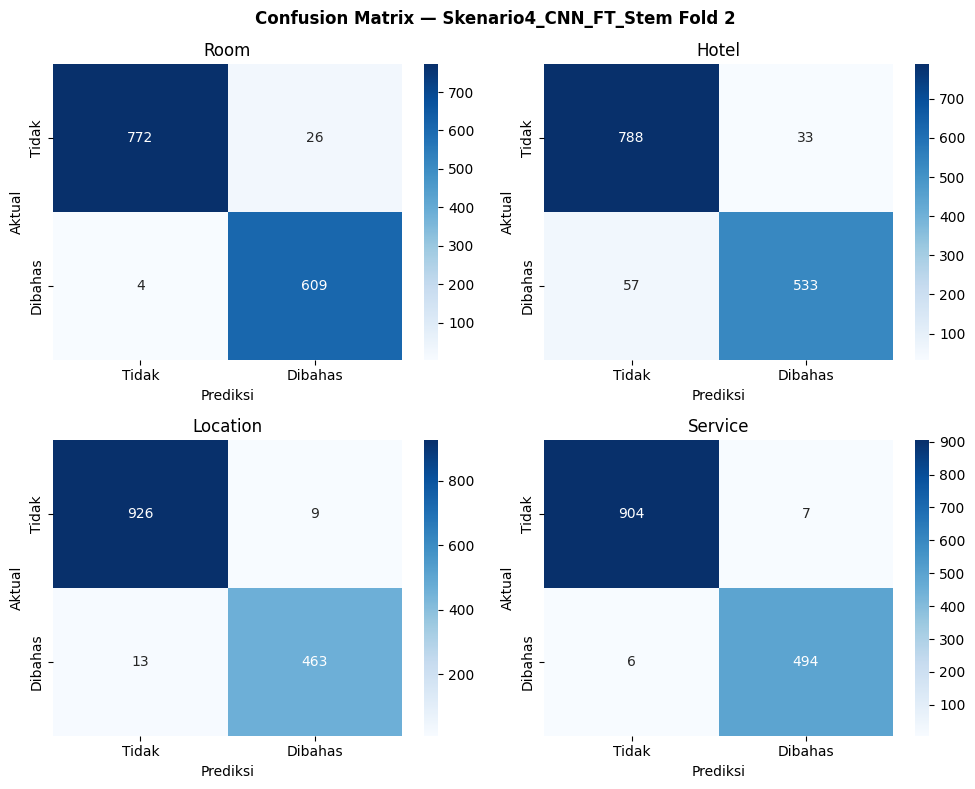

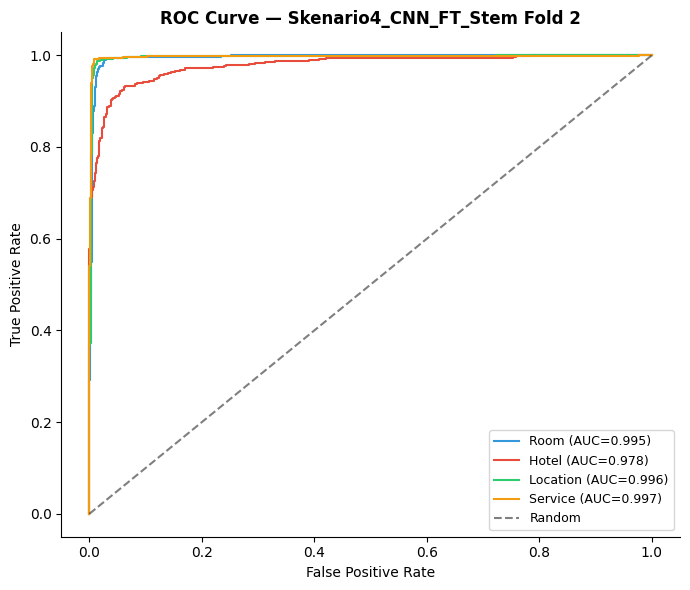


  ── Fold 3/5 ──
  Distribusi label per fold:
    Room      : Pos=2452, Neg=3155
    Hotel     : Pos=2363, Neg=3244
    Location  : Pos=1902, Neg=3705
    Service   : Pos=2000, Neg=3607
Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 14s 63ms/step - accuracy: 0.6174 - auc: 0.8821 - loss: 0.7354 - val_accuracy: 0.7033 - val_auc: 0.9834 - val_loss: 0.4206
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 12s 66ms/step - accuracy: 0.6993 - auc: 0.9681 - loss: 0.4118 - val_accuracy: 0.7245 - val_auc: 0.9896 - val_loss: 0.2865
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.6966 - auc: 0.9772 - loss: 0.3101 - val_accuracy: 0.7111 - val_auc: 0.9909 - val_loss: 0.2317
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 11s 64ms/step - accuracy: 0.6975 - auc: 0.9816 - loss: 0.2606 - val_accuracy: 0.6850 - val_auc: 0.9918 - val_loss: 0.2007
Epoch 5/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.7016 - auc: 0.9836 - loss: 0.2316 - val_accuracy: 0.6977 - val_auc: 0.9921 - val_loss: 0.1826
Epoc

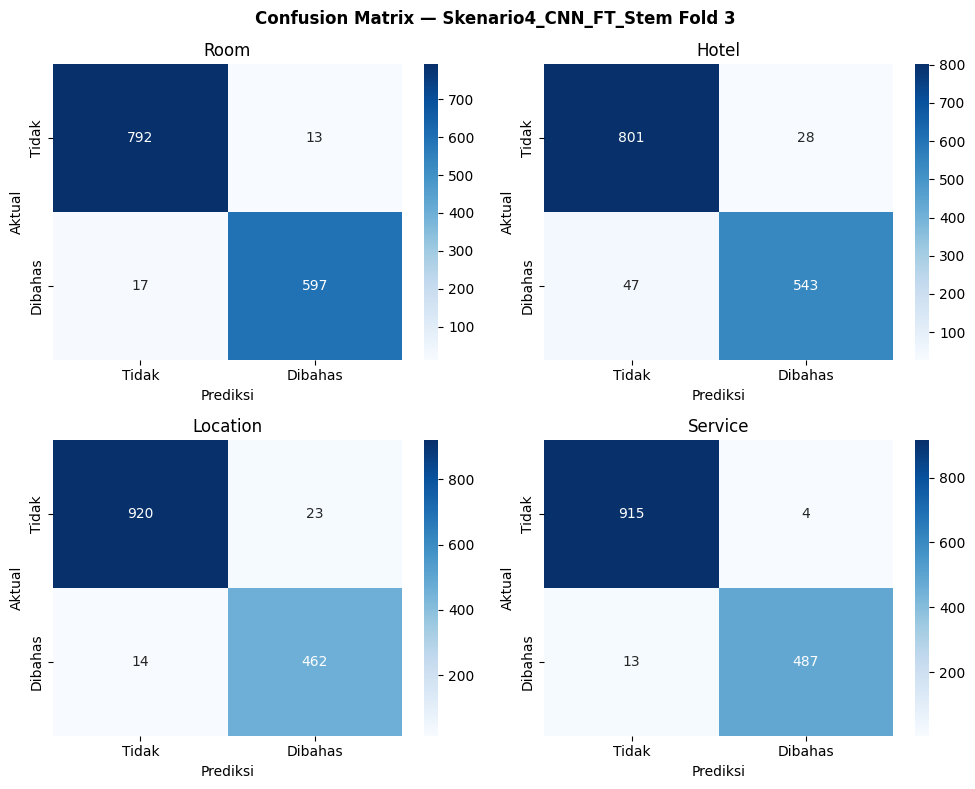

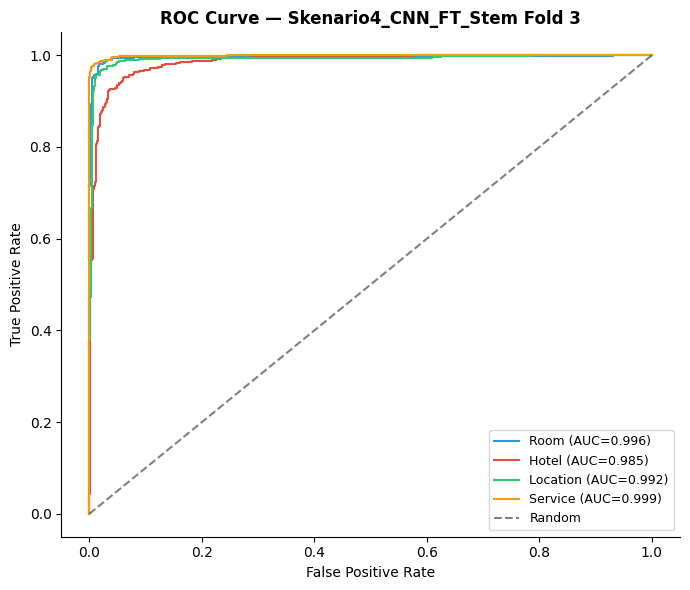


  ── Fold 4/5 ──
  Distribusi label per fold:
    Room      : Pos=2453, Neg=3178
    Hotel     : Pos=2362, Neg=3269
    Location  : Pos=1902, Neg=3729
    Service   : Pos=2000, Neg=3631
Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 15s 68ms/step - accuracy: 0.6079 - auc: 0.8870 - loss: 0.7182 - val_accuracy: 0.6918 - val_auc: 0.9800 - val_loss: 0.4159
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 11s 60ms/step - accuracy: 0.6922 - auc: 0.9667 - loss: 0.4078 - val_accuracy: 0.7125 - val_auc: 0.9883 - val_loss: 0.2896
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.6985 - auc: 0.9777 - loss: 0.3070 - val_accuracy: 0.6638 - val_auc: 0.9906 - val_loss: 0.2297
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 11s 60ms/step - accuracy: 0.6926 - auc: 0.9816 - loss: 0.2578 - val_accuracy: 0.6982 - val_auc: 0.9914 - val_loss: 0.2005
Epoch 5/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.6935 - auc: 0.9841 - loss: 0.2268 - val_accuracy: 0.6287 - val_auc: 0.9922 - val_loss: 0.1800
Epoc

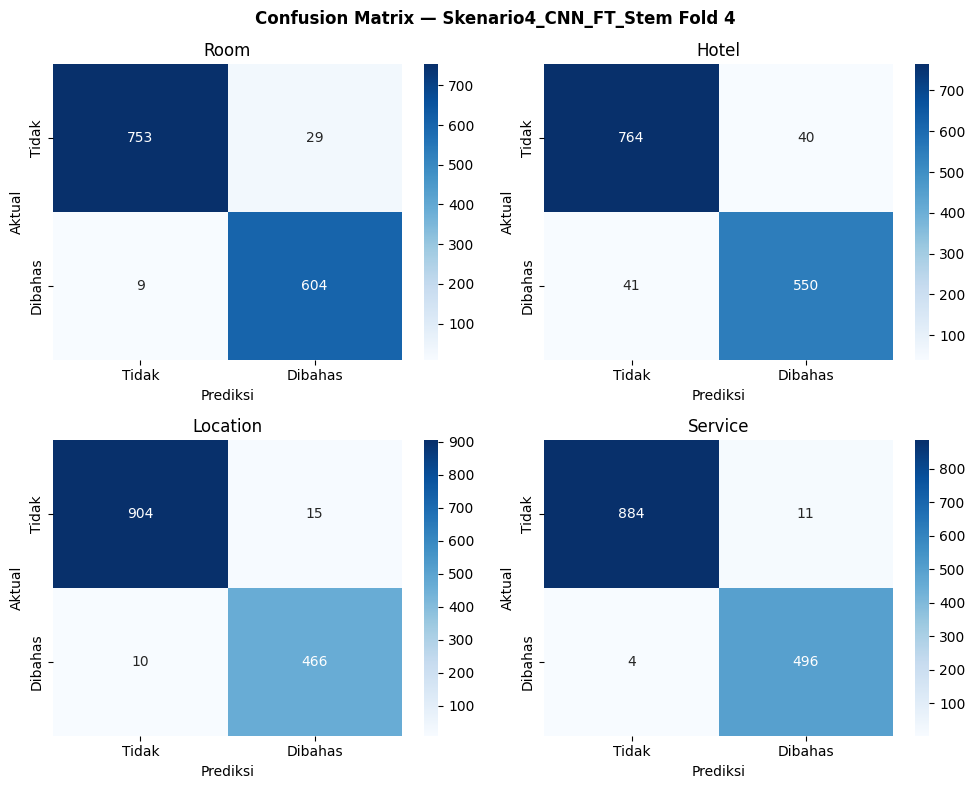

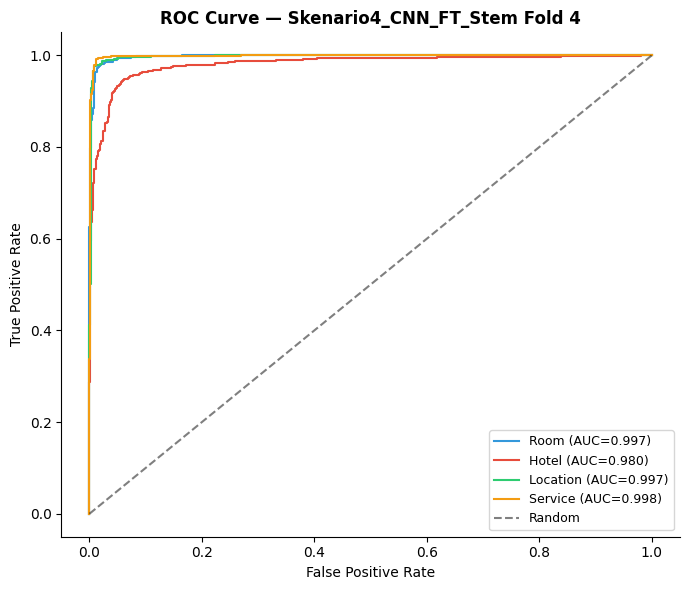


  ── Fold 5/5 ──
  Distribusi label per fold:
    Room      : Pos=2453, Neg=3167
    Hotel     : Pos=2362, Neg=3258
    Location  : Pos=1903, Neg=3717
    Service   : Pos=2000, Neg=3620
Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - accuracy: 0.5968 - auc: 0.8748 - loss: 0.7289 - val_accuracy: 0.7063 - val_auc: 0.9836 - val_loss: 0.4041
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 11s 61ms/step - accuracy: 0.6913 - auc: 0.9670 - loss: 0.3980 - val_accuracy: 0.6309 - val_auc: 0.9903 - val_loss: 0.2756
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 11s 60ms/step - accuracy: 0.6922 - auc: 0.9774 - loss: 0.3020 - val_accuracy: 0.6913 - val_auc: 0.9917 - val_loss: 0.2133
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 0.7009 - auc: 0.9808 - loss: 0.2565 - val_accuracy: 0.6166 - val_auc: 0.9923 - val_loss: 0.1878
Epoch 5/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 11s 64ms/step - accuracy: 0.7037 - auc: 0.9835 - loss: 0.2295 - val_accuracy: 0.6707 - val_auc: 0.9928 - val_loss: 0.1728
Epoc

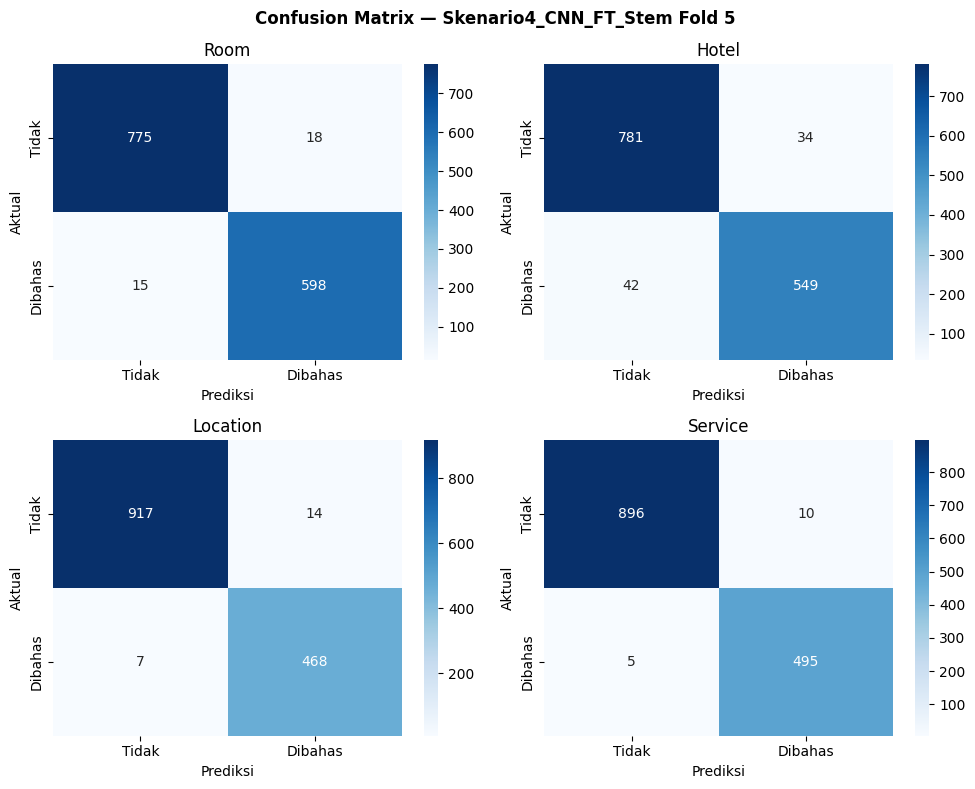

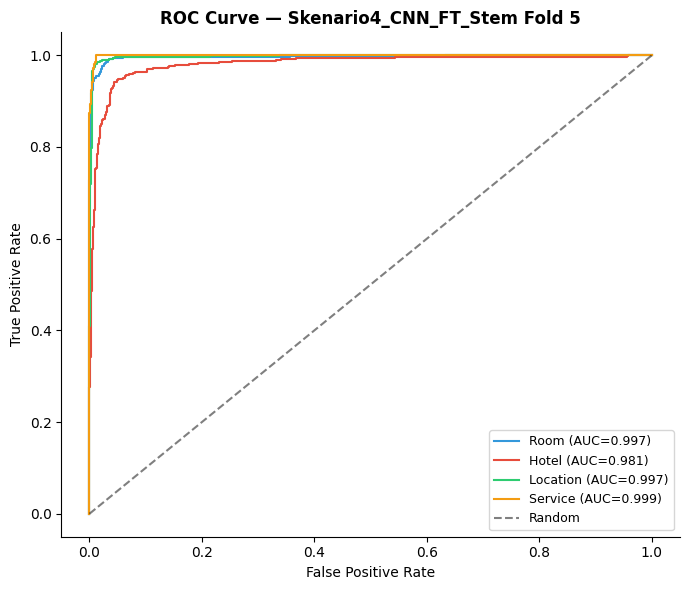


  Model disimpan (fold terakhir): /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task1_Aspek/Skenario4_CNN_FT_Stem/model.h5


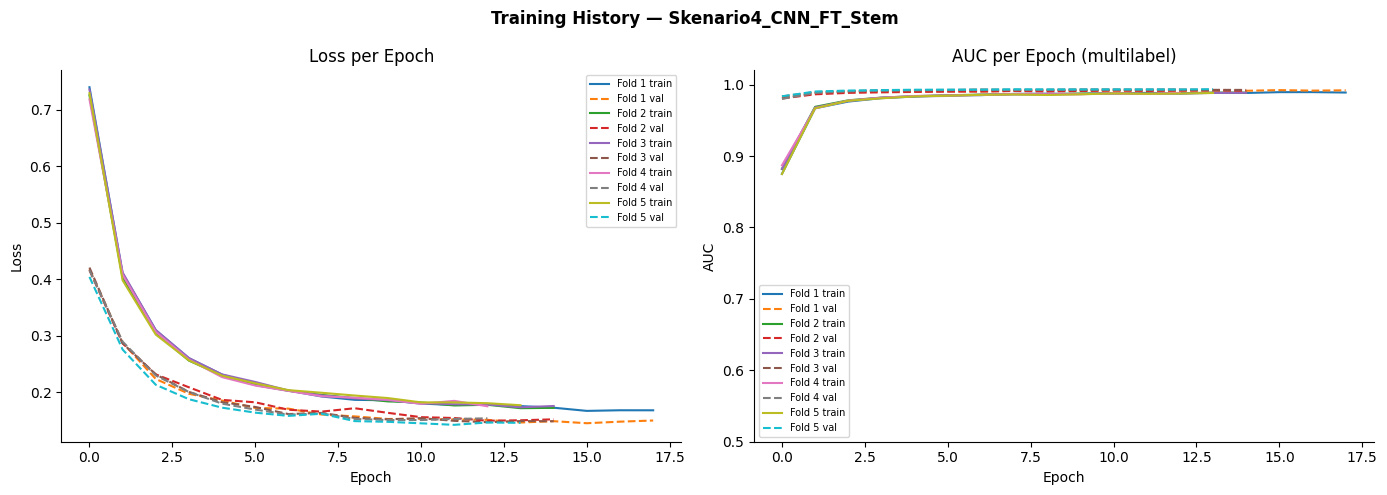


  ╔═ SELESAI: Skenario4_CNN_FT_Stem
  ║  avg Precision  : 0.9656 ± 0.0042
  ║  avg Recall     : 0.9658 ± 0.0050
  ║  avg F1 Macro   : 0.9656 ± 0.0015
  ║  avg Accuracy   : 0.9726 ± 0.0010
  ║  avg AUC Macro  : 0.9927 ± 0.0009
  ║  avg RAM        : 4229.7 MB (32.6%)
  ║  avg CPU        : 2.4 %
  ║  avg Waktu      : 169.55 detik/fold
  ║  avg T/Epoch    : 11.21 detik/epoch
  ║  avg T/Step     : 0.0640 detik/step
  ╚══════════════════════════════════════════════════


In [ ]:
# Training Skenario 4 (CNN_FT_Stem)
jalankan_skenario(skenario_list[3])


  Training: Skenario5_BiLSTM_W2V_NonStem
  Membuat embedding matrix...
  Vocab tokenizer : 5,546 kata
  OOV             : 2,156 kata tidak ditemukan di embedding
  Shape matrix    : (5546, 100)

  ── Fold 1/5 ──
  Distribusi label per fold:
    Room      : Pos=2453, Neg=3178
    Hotel     : Pos=2362, Neg=3269
    Location  : Pos=1903, Neg=3728
    Service   : Pos=2000, Neg=3631
Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 51s 229ms/step - accuracy: 0.5463 - auc: 0.8430 - loss: 0.5134 - val_accuracy: 0.6824 - val_auc: 0.9713 - val_loss: 0.2632
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 40s 222ms/step - accuracy: 0.6663 - auc: 0.9405 - loss: 0.3143 - val_accuracy: 0.6824 - val_auc: 0.9798 - val_loss: 0.2027
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 39s 222ms/step - accuracy: 0.6802 - auc: 0.9535 - loss: 0.2713 - val_accuracy: 0.6839 - val_auc: 0.9811 - val_loss: 0.1793
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 38s 217ms/step - accuracy: 0.6910 - auc: 0.9628 - loss: 0.2355 - val_accuracy: 0.6566 - v

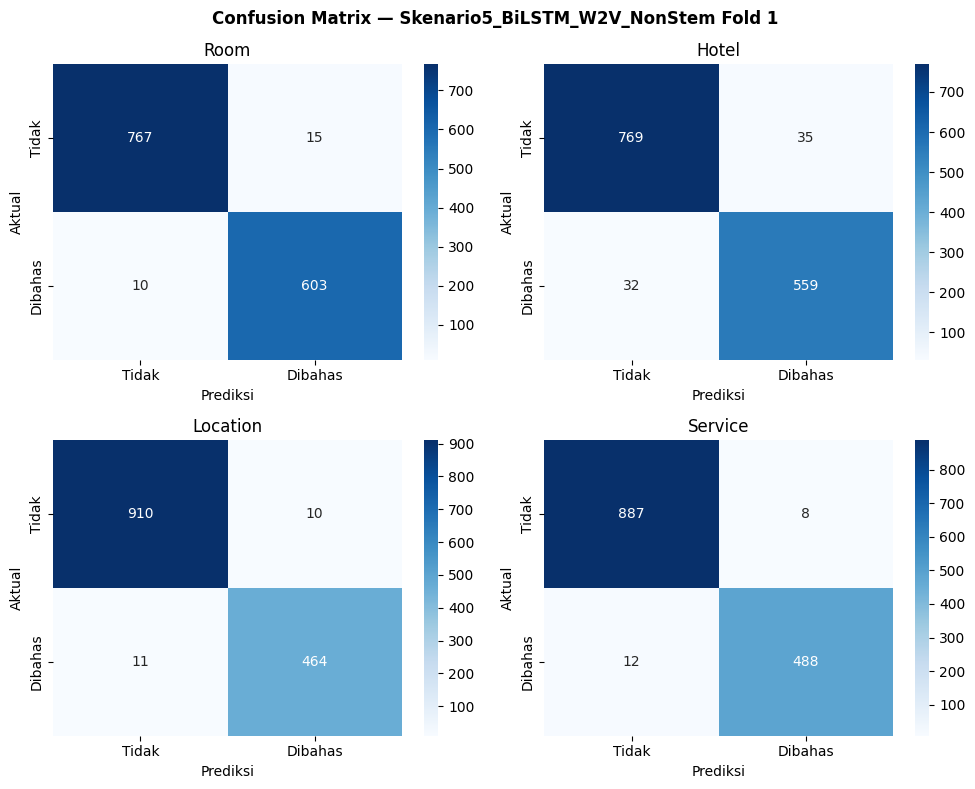

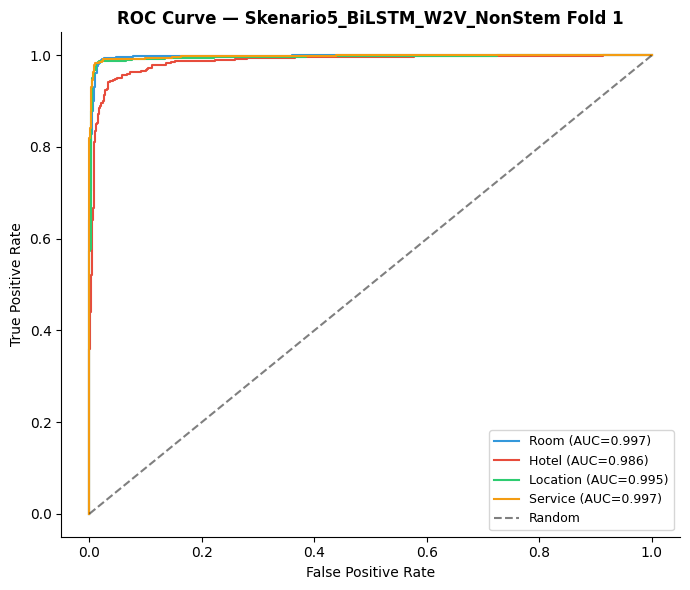


  ── Fold 2/5 ──
  Distribusi label per fold:
    Room      : Pos=2453, Neg=3162
    Hotel     : Pos=2363, Neg=3252
    Location  : Pos=1902, Neg=3713
    Service   : Pos=2000, Neg=3615
Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 52s 242ms/step - accuracy: 0.5704 - auc: 0.8395 - loss: 0.5256 - val_accuracy: 0.6683 - val_auc: 0.9667 - val_loss: 0.2804
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 80s 234ms/step - accuracy: 0.6700 - auc: 0.9413 - loss: 0.3226 - val_accuracy: 0.6740 - val_auc: 0.9739 - val_loss: 0.2133
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 38s 218ms/step - accuracy: 0.6787 - auc: 0.9574 - loss: 0.2669 - val_accuracy: 0.6768 - val_auc: 0.9756 - val_loss: 0.1908
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 40s 229ms/step - accuracy: 0.6816 - auc: 0.9646 - loss: 0.2383 - val_accuracy: 0.6938 - val_auc: 0.9806 - val_loss: 0.1650
Epoch 5/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 42s 238ms/step - accuracy: 0.6825 - auc: 0.9685 - loss: 0.2201 - val_accuracy: 0.6910 - val_auc: 0.9848 - val_loss: 0.145

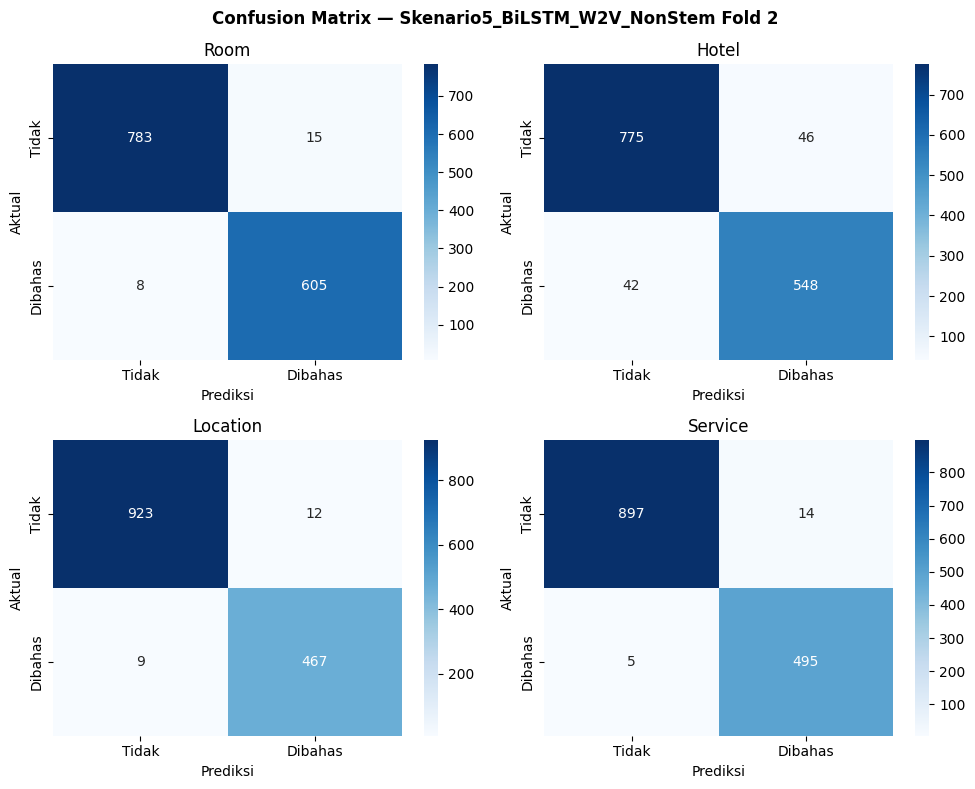

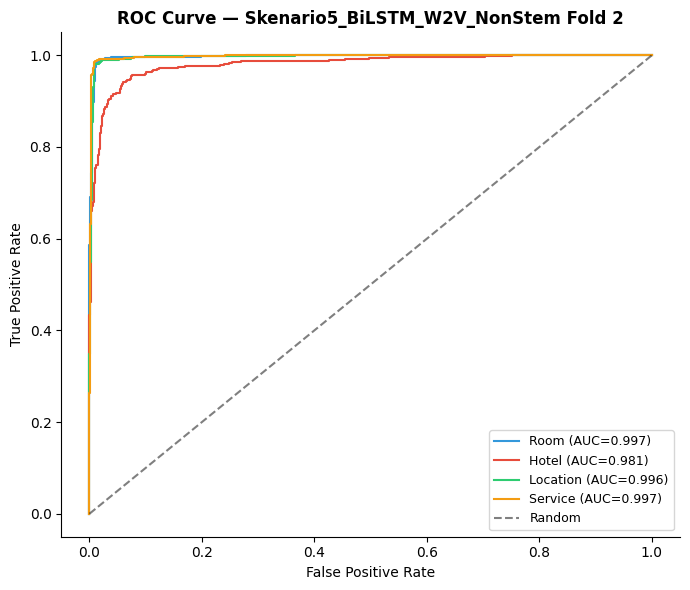


  ── Fold 3/5 ──
  Distribusi label per fold:
    Room      : Pos=2452, Neg=3155
    Hotel     : Pos=2363, Neg=3244
    Location  : Pos=1902, Neg=3705
    Service   : Pos=2000, Neg=3607
Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 50s 222ms/step - accuracy: 0.5816 - auc: 0.8391 - loss: 0.5258 - val_accuracy: 0.7104 - val_auc: 0.9702 - val_loss: 0.2701
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 42s 231ms/step - accuracy: 0.6808 - auc: 0.9413 - loss: 0.3195 - val_accuracy: 0.7012 - val_auc: 0.9766 - val_loss: 0.2050
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 40s 226ms/step - accuracy: 0.6781 - auc: 0.9562 - loss: 0.2683 - val_accuracy: 0.6843 - val_auc: 0.9804 - val_loss: 0.1805
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 38s 214ms/step - accuracy: 0.6790 - auc: 0.9678 - loss: 0.2280 - val_accuracy: 0.6617 - val_auc: 0.9843 - val_loss: 0.1584
Epoch 5/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 42s 217ms/step - accuracy: 0.6743 - auc: 0.9723 - loss: 0.2089 - val_accuracy: 0.6638 - val_auc: 0.9854 - val_loss: 0.149

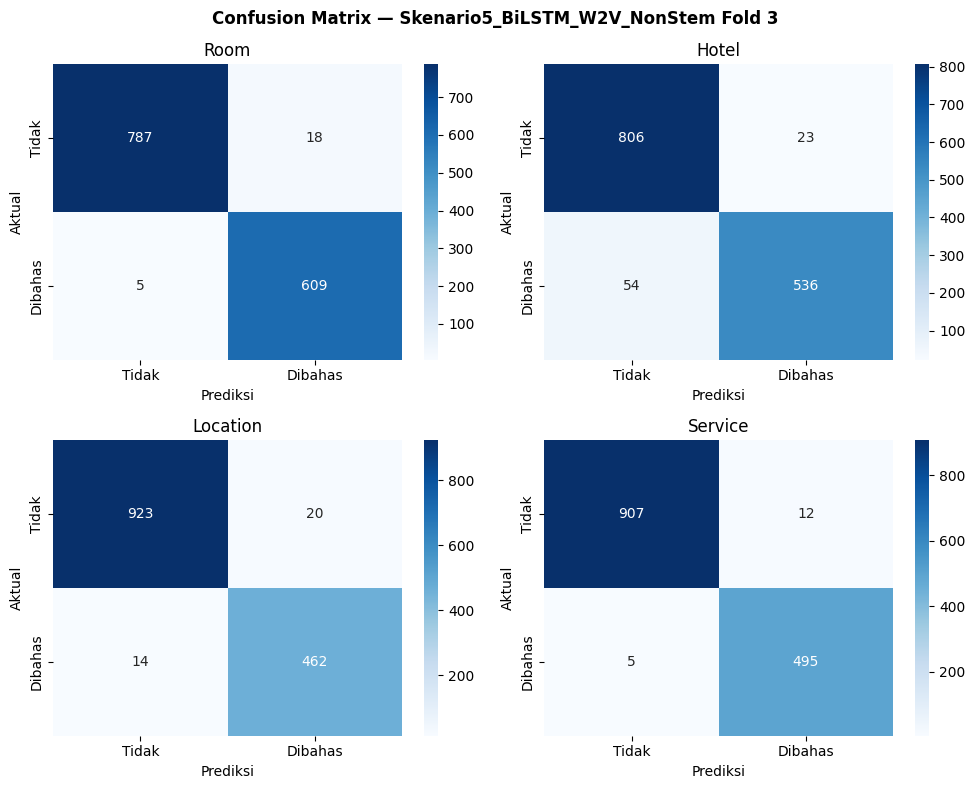

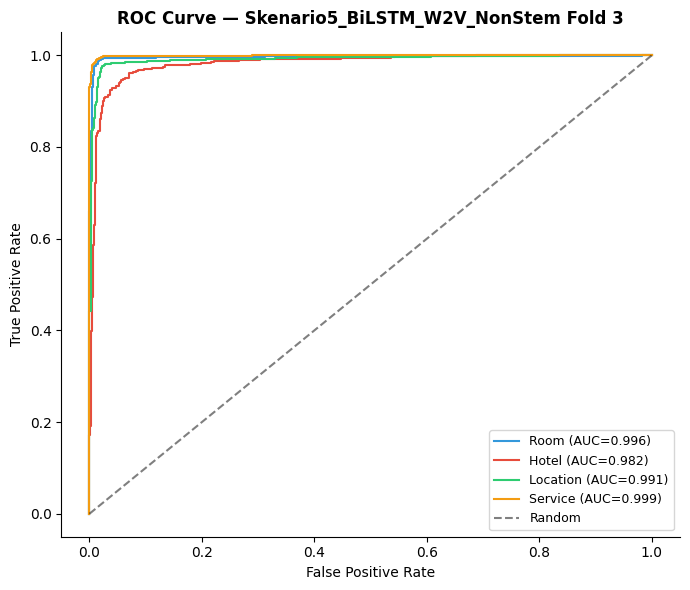


  ── Fold 4/5 ──
  Distribusi label per fold:
    Room      : Pos=2453, Neg=3178
    Hotel     : Pos=2362, Neg=3269
    Location  : Pos=1902, Neg=3729
    Service   : Pos=2000, Neg=3631
Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 52s 234ms/step - accuracy: 0.5651 - auc: 0.8507 - loss: 0.5069 - val_accuracy: 0.7039 - val_auc: 0.9684 - val_loss: 0.2777
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 41s 235ms/step - accuracy: 0.6718 - auc: 0.9402 - loss: 0.3196 - val_accuracy: 0.6789 - val_auc: 0.9787 - val_loss: 0.2076
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 44s 248ms/step - accuracy: 0.6743 - auc: 0.9569 - loss: 0.2657 - val_accuracy: 0.6588 - val_auc: 0.9814 - val_loss: 0.1788
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 77s 221ms/step - accuracy: 0.6805 - auc: 0.9656 - loss: 0.2324 - val_accuracy: 0.6588 - val_auc: 0.9870 - val_loss: 0.1498
Epoch 5/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 41s 224ms/step - accuracy: 0.6862 - auc: 0.9726 - loss: 0.2063 - val_accuracy: 0.6681 - val_auc: 0.9885 - val_loss: 0.132

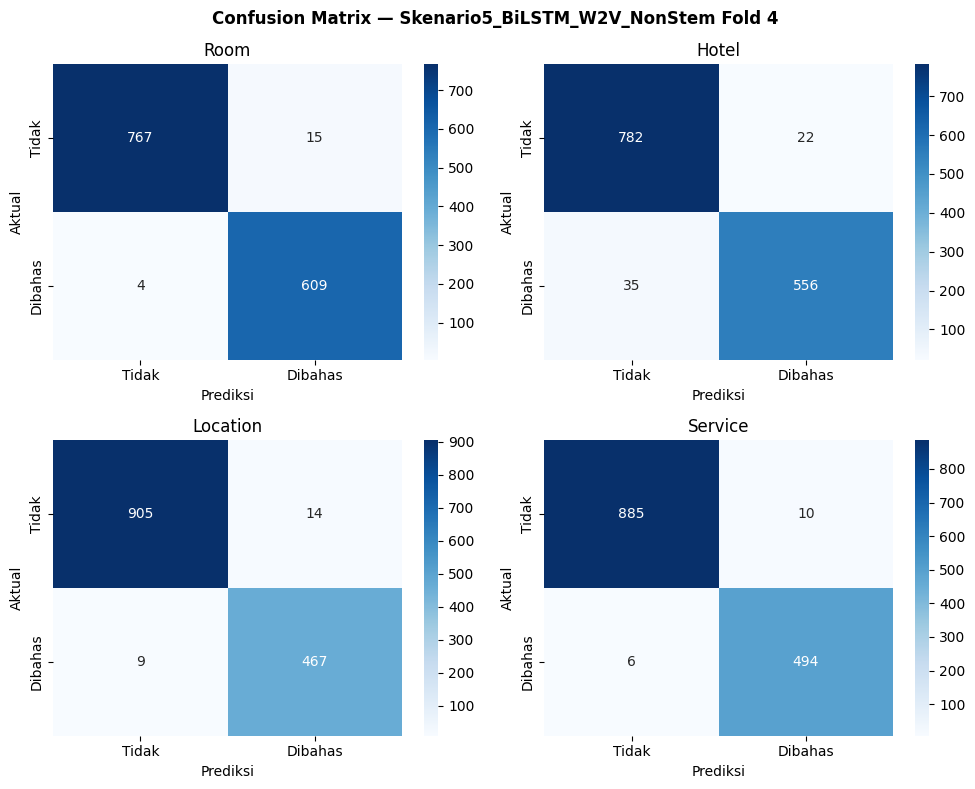

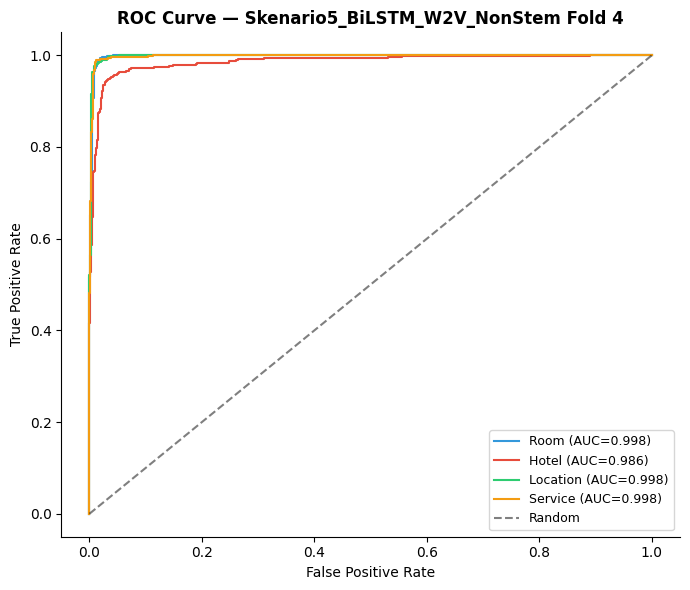


  ── Fold 5/5 ──
  Distribusi label per fold:
    Room      : Pos=2453, Neg=3167
    Hotel     : Pos=2362, Neg=3258
    Location  : Pos=1903, Neg=3717
    Service   : Pos=2000, Neg=3620
Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 61s 291ms/step - accuracy: 0.5831 - auc: 0.8527 - loss: 0.5061 - val_accuracy: 0.6799 - val_auc: 0.9737 - val_loss: 0.2577
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 43s 243ms/step - accuracy: 0.6731 - auc: 0.9365 - loss: 0.3269 - val_accuracy: 0.7013 - val_auc: 0.9826 - val_loss: 0.1961
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 78s 219ms/step - accuracy: 0.6827 - auc: 0.9537 - loss: 0.2729 - val_accuracy: 0.7013 - val_auc: 0.9854 - val_loss: 0.1675
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 41s 232ms/step - accuracy: 0.6913 - auc: 0.9648 - loss: 0.2370 - val_accuracy: 0.6828 - val_auc: 0.9882 - val_loss: 0.1404
Epoch 5/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 40s 228ms/step - accuracy: 0.6911 - auc: 0.9700 - loss: 0.2154 - val_accuracy: 0.6600 - val_auc: 0.9901 - val_loss: 0.127

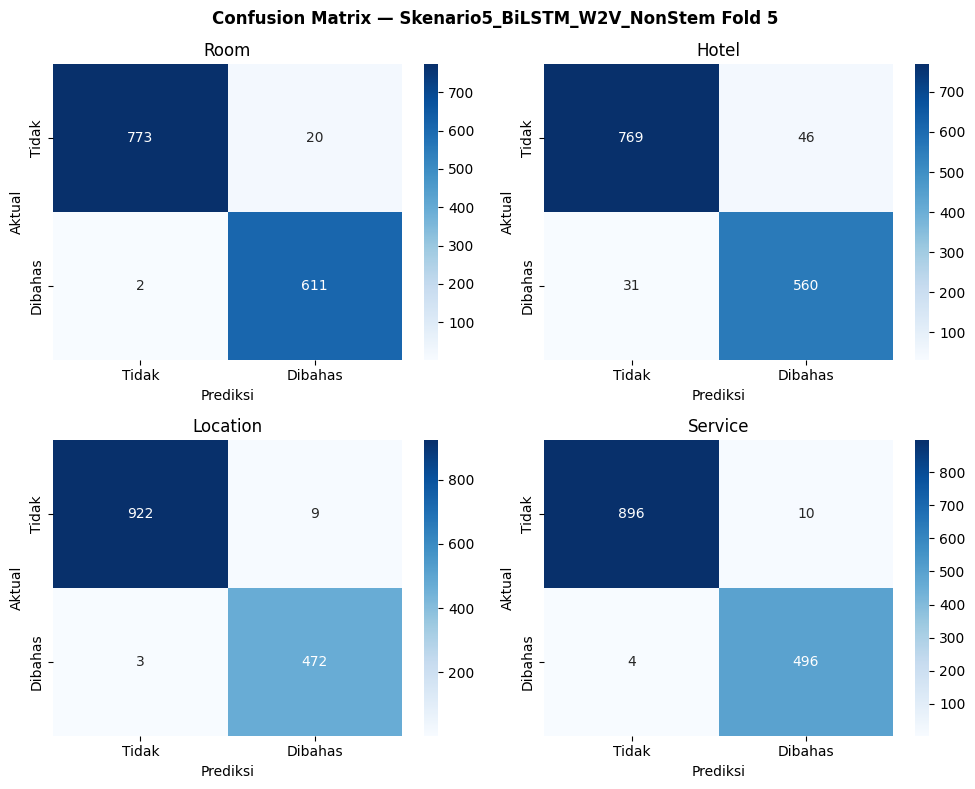

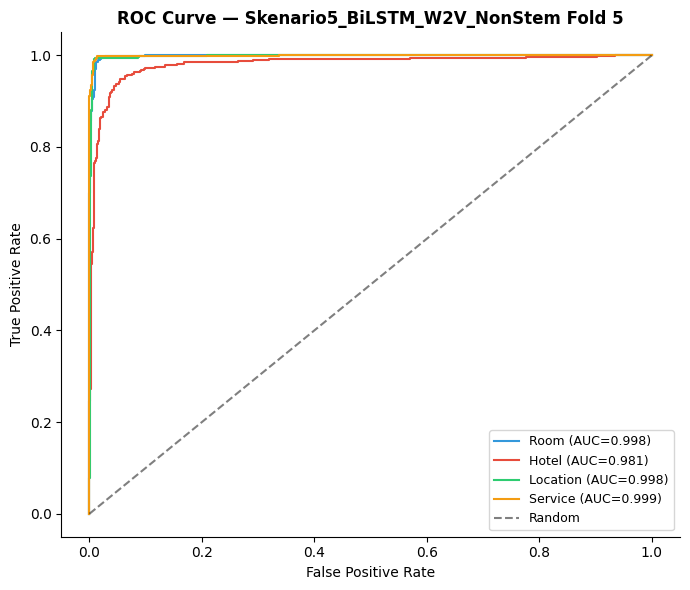


  Model disimpan (fold terakhir): /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task1_Aspek/Skenario5_BiLSTM_W2V_NonStem/model.h5


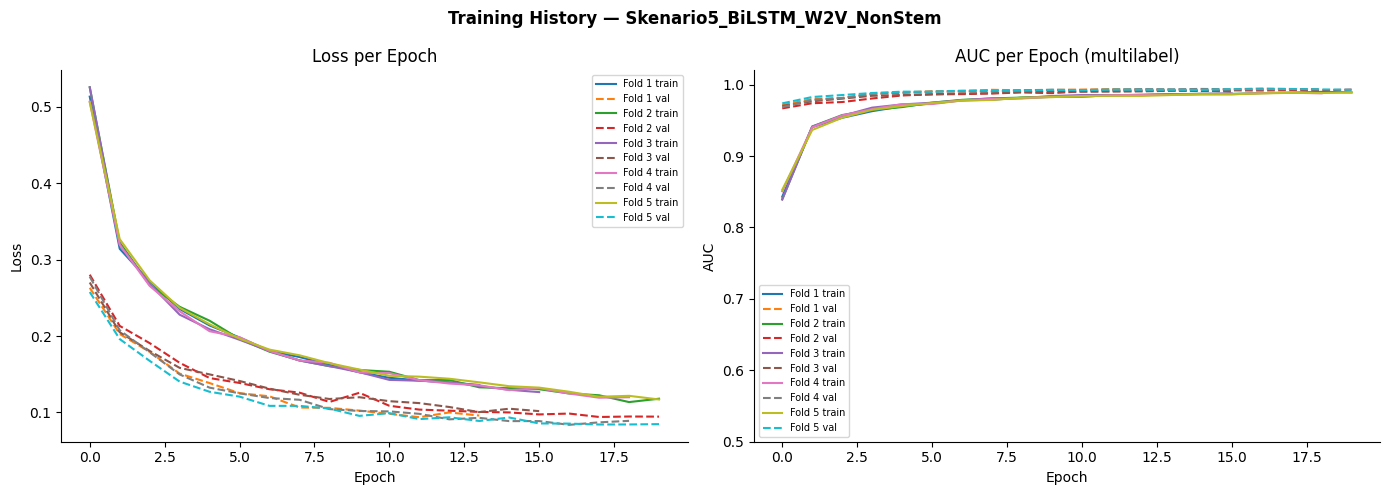


  ╔═ SELESAI: Skenario5_BiLSTM_W2V_NonStem
  ║  avg Precision  : 0.9667 ± 0.0044
  ║  avg Recall     : 0.9732 ± 0.0064
  ║  avg F1 Macro   : 0.9698 ± 0.0037
  ║  avg Accuracy   : 0.9760 ± 0.0027
  ║  avg AUC Macro  : 0.9935 ± 0.0011
  ║  avg RAM        : 3969.6 MB (30.6%)
  ║  avg CPU        : 19.3 %
  ║  avg Waktu      : 757.77 detik/fold
  ║  avg T/Epoch    : 42.31 detik/epoch
  ║  avg T/Step     : 0.2417 detik/step
  ╚══════════════════════════════════════════════════


In [ ]:
# Training Skenario 5 (BiLSTM_W2V_NonStem)
jalankan_skenario(skenario_list[4])


  Training: Skenario6_BiLSTM_W2V_Stem
  Membuat embedding matrix...
  Vocab tokenizer : 3,812 kata
  OOV             : 1,351 kata tidak ditemukan di embedding
  Shape matrix    : (3812, 100)

  ── Fold 1/5 ──
  Distribusi label per fold:
    Room      : Pos=2453, Neg=3178
    Hotel     : Pos=2362, Neg=3269
    Location  : Pos=1903, Neg=3728
    Service   : Pos=2000, Neg=3631
Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 51s 233ms/step - accuracy: 0.5862 - auc: 0.8425 - loss: 0.5183 - val_accuracy: 0.6846 - val_auc: 0.9720 - val_loss: 0.2697
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 38s 218ms/step - accuracy: 0.6770 - auc: 0.9404 - loss: 0.3185 - val_accuracy: 0.6853 - val_auc: 0.9775 - val_loss: 0.2101
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 41s 232ms/step - accuracy: 0.6834 - auc: 0.9525 - loss: 0.2732 - val_accuracy: 0.6875 - val_auc: 0.9829 - val_loss: 0.1728
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 40s 227ms/step - accuracy: 0.6924 - auc: 0.9649 - loss: 0.2353 - val_accuracy: 0.6760 - val_

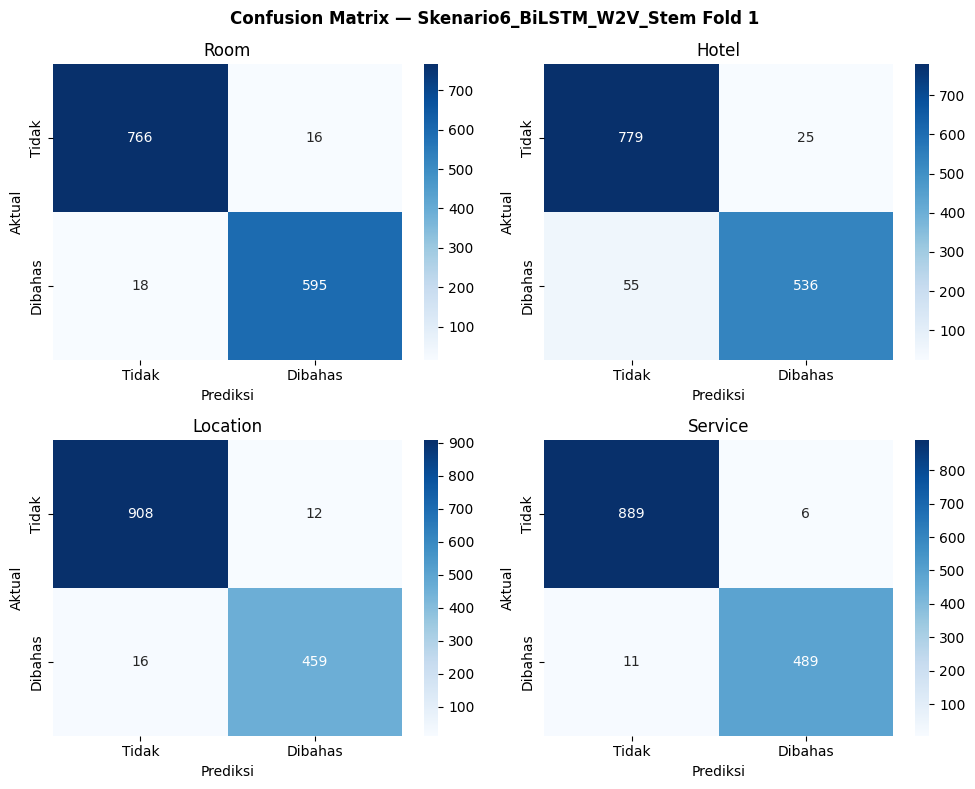

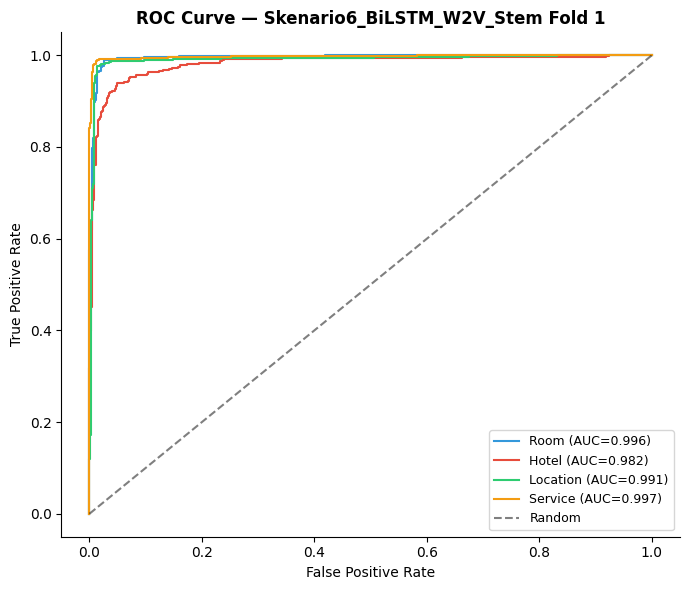


  ── Fold 2/5 ──
  Distribusi label per fold:
    Room      : Pos=2453, Neg=3162
    Hotel     : Pos=2363, Neg=3252
    Location  : Pos=1902, Neg=3713
    Service   : Pos=2000, Neg=3615
Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 52s 244ms/step - accuracy: 0.5617 - auc: 0.8524 - loss: 0.5081 - val_accuracy: 0.7087 - val_auc: 0.9694 - val_loss: 0.2555
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 38s 216ms/step - accuracy: 0.6762 - auc: 0.9427 - loss: 0.3199 - val_accuracy: 0.6910 - val_auc: 0.9748 - val_loss: 0.2034
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 40s 230ms/step - accuracy: 0.6805 - auc: 0.9568 - loss: 0.2695 - val_accuracy: 0.6853 - val_auc: 0.9787 - val_loss: 0.1795
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 47s 270ms/step - accuracy: 0.6882 - auc: 0.9670 - loss: 0.2323 - val_accuracy: 0.6853 - val_auc: 0.9824 - val_loss: 0.1562
Epoch 5/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 73s 217ms/step - accuracy: 0.6844 - auc: 0.9714 - loss: 0.2112 - val_accuracy: 0.6726 - val_auc: 0.9853 - val_loss: 0.146

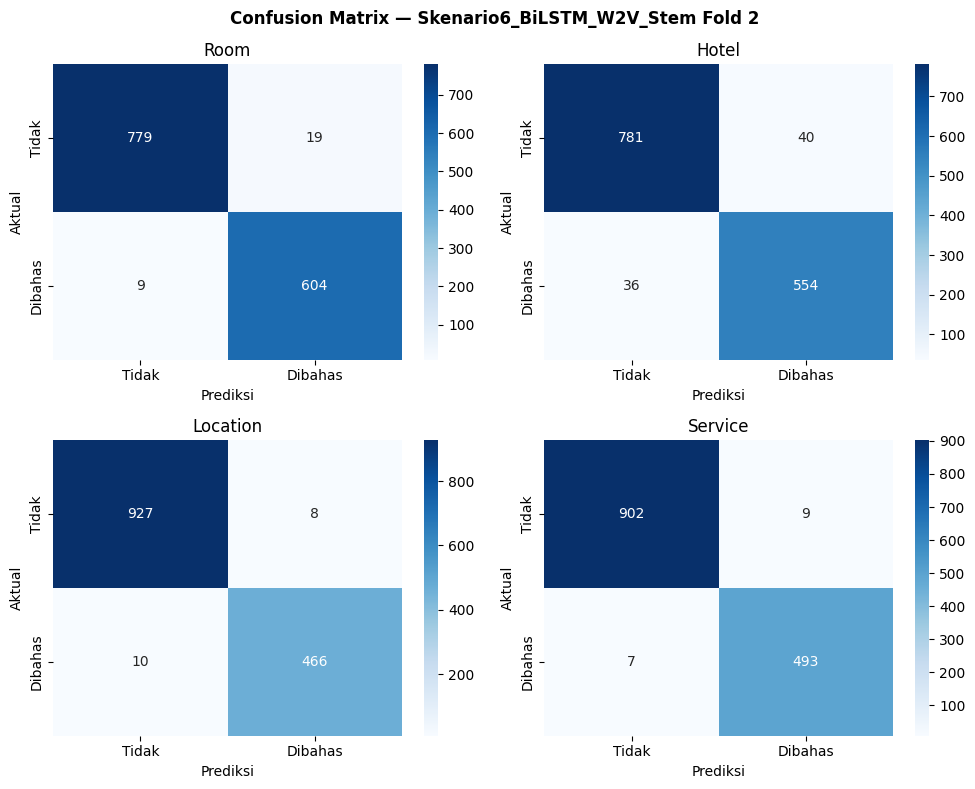

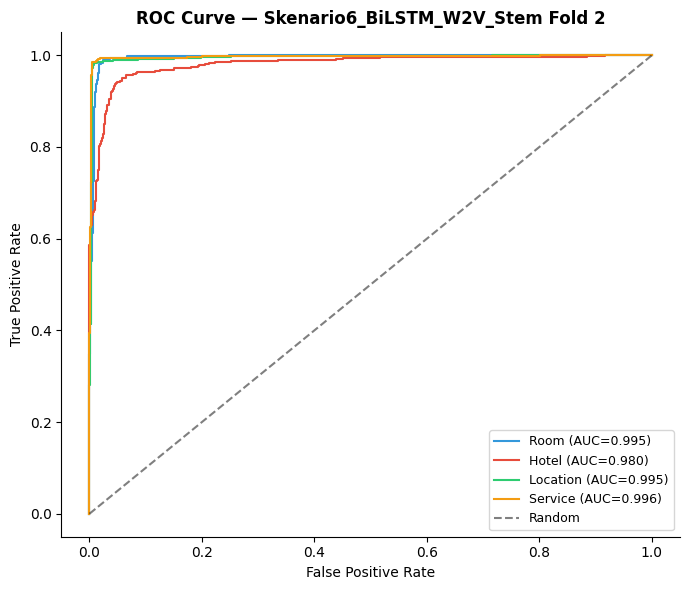


  ── Fold 3/5 ──
  Distribusi label per fold:
    Room      : Pos=2452, Neg=3155
    Hotel     : Pos=2363, Neg=3244
    Location  : Pos=1902, Neg=3705
    Service   : Pos=2000, Neg=3607
Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 49s 226ms/step - accuracy: 0.5982 - auc: 0.8546 - loss: 0.5062 - val_accuracy: 0.6624 - val_auc: 0.9705 - val_loss: 0.2782
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 39s 215ms/step - accuracy: 0.6759 - auc: 0.9428 - loss: 0.3196 - val_accuracy: 0.7075 - val_auc: 0.9770 - val_loss: 0.2194
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 40s 230ms/step - accuracy: 0.6886 - auc: 0.9550 - loss: 0.2746 - val_accuracy: 0.6892 - val_auc: 0.9812 - val_loss: 0.1878
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 39s 218ms/step - accuracy: 0.6891 - auc: 0.9643 - loss: 0.2417 - val_accuracy: 0.6808 - val_auc: 0.9841 - val_loss: 0.1627
Epoch 5/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 41s 218ms/step - accuracy: 0.6827 - auc: 0.9698 - loss: 0.2194 - val_accuracy: 0.7026 - val_auc: 0.9864 - val_loss: 0.146

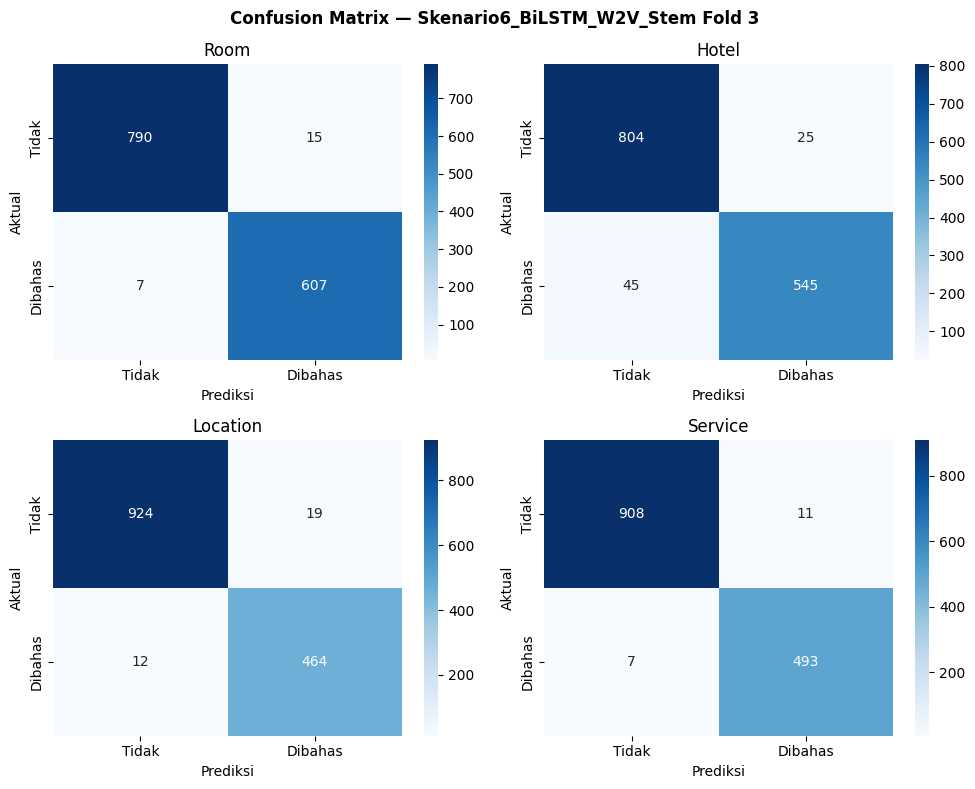

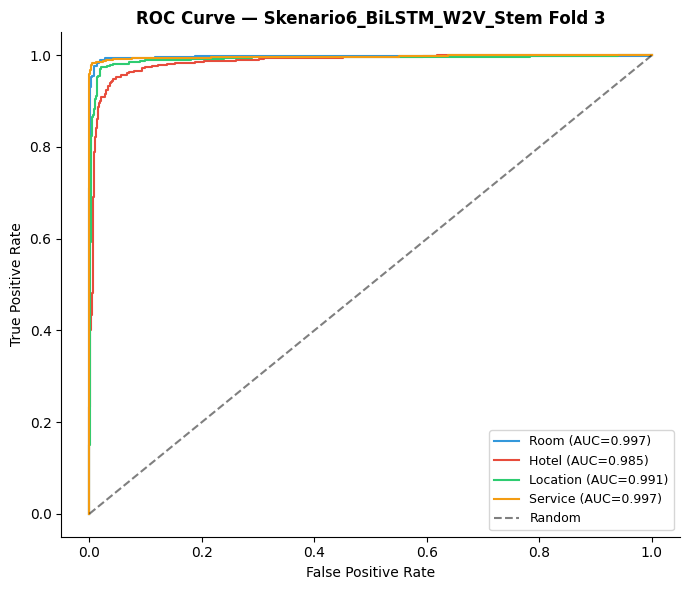


  ── Fold 4/5 ──
  Distribusi label per fold:
    Room      : Pos=2453, Neg=3178
    Hotel     : Pos=2362, Neg=3269
    Location  : Pos=1902, Neg=3729
    Service   : Pos=2000, Neg=3631
Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 51s 239ms/step - accuracy: 0.5889 - auc: 0.8473 - loss: 0.5131 - val_accuracy: 0.6975 - val_auc: 0.9672 - val_loss: 0.2811
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 81s 233ms/step - accuracy: 0.6837 - auc: 0.9381 - loss: 0.3260 - val_accuracy: 0.7226 - val_auc: 0.9799 - val_loss: 0.2072
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 39s 220ms/step - accuracy: 0.6894 - auc: 0.9527 - loss: 0.2756 - val_accuracy: 0.6738 - val_auc: 0.9829 - val_loss: 0.1806
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 40s 215ms/step - accuracy: 0.6924 - auc: 0.9636 - loss: 0.2406 - val_accuracy: 0.7168 - val_auc: 0.9842 - val_loss: 0.1629
Epoch 5/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 42s 220ms/step - accuracy: 0.6935 - auc: 0.9684 - loss: 0.2191 - val_accuracy: 0.6968 - val_auc: 0.9866 - val_loss: 0.142

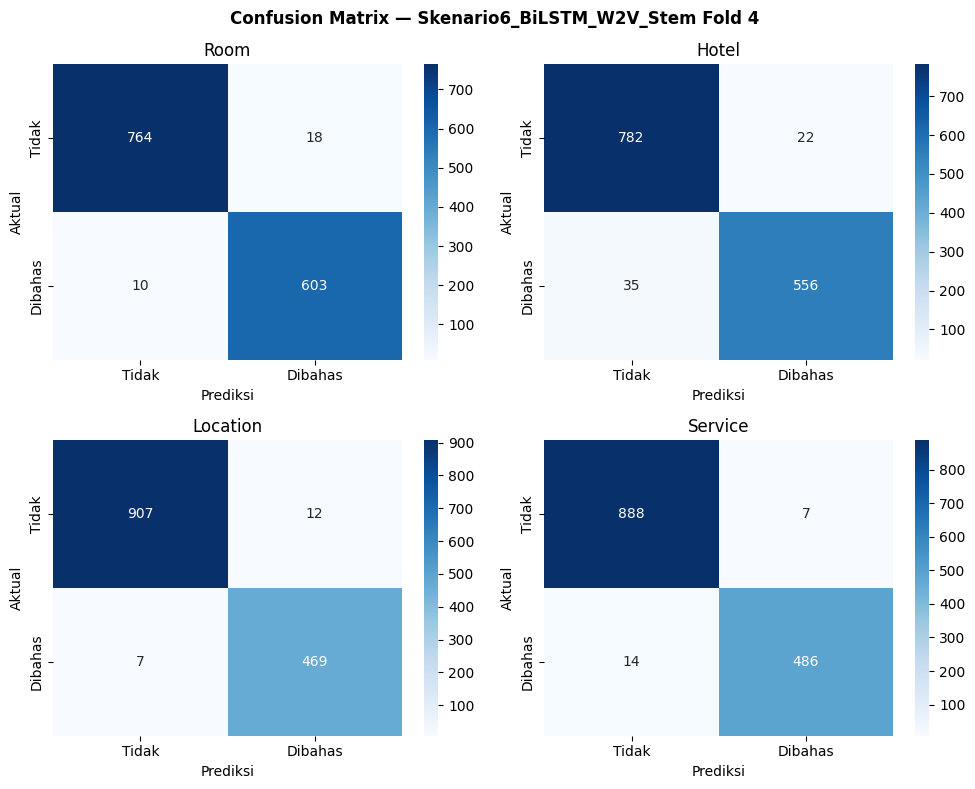

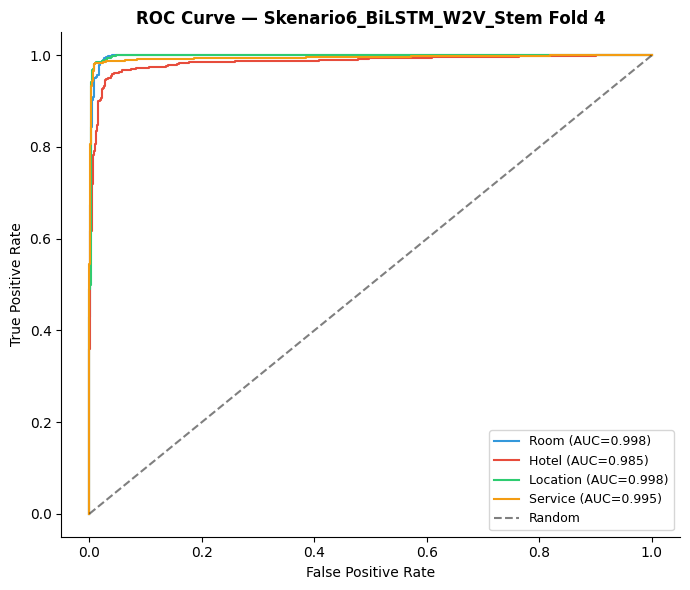


  ── Fold 5/5 ──
  Distribusi label per fold:
    Room      : Pos=2453, Neg=3167
    Hotel     : Pos=2362, Neg=3258
    Location  : Pos=1903, Neg=3717
    Service   : Pos=2000, Neg=3620
Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 50s 238ms/step - accuracy: 0.5888 - auc: 0.8545 - loss: 0.5023 - val_accuracy: 0.7127 - val_auc: 0.9725 - val_loss: 0.2628
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 40s 226ms/step - accuracy: 0.6799 - auc: 0.9376 - loss: 0.3229 - val_accuracy: 0.7127 - val_auc: 0.9826 - val_loss: 0.1990
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 39s 213ms/step - accuracy: 0.6956 - auc: 0.9520 - loss: 0.2769 - val_accuracy: 0.6999 - val_auc: 0.9865 - val_loss: 0.1611
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 41s 214ms/step - accuracy: 0.6964 - auc: 0.9594 - loss: 0.2513 - val_accuracy: 0.7077 - val_auc: 0.9875 - val_loss: 0.1482
Epoch 5/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 43s 226ms/step - accuracy: 0.6934 - auc: 0.9668 - loss: 0.2243 - val_accuracy: 0.6743 - val_auc: 0.9899 - val_loss: 0.133

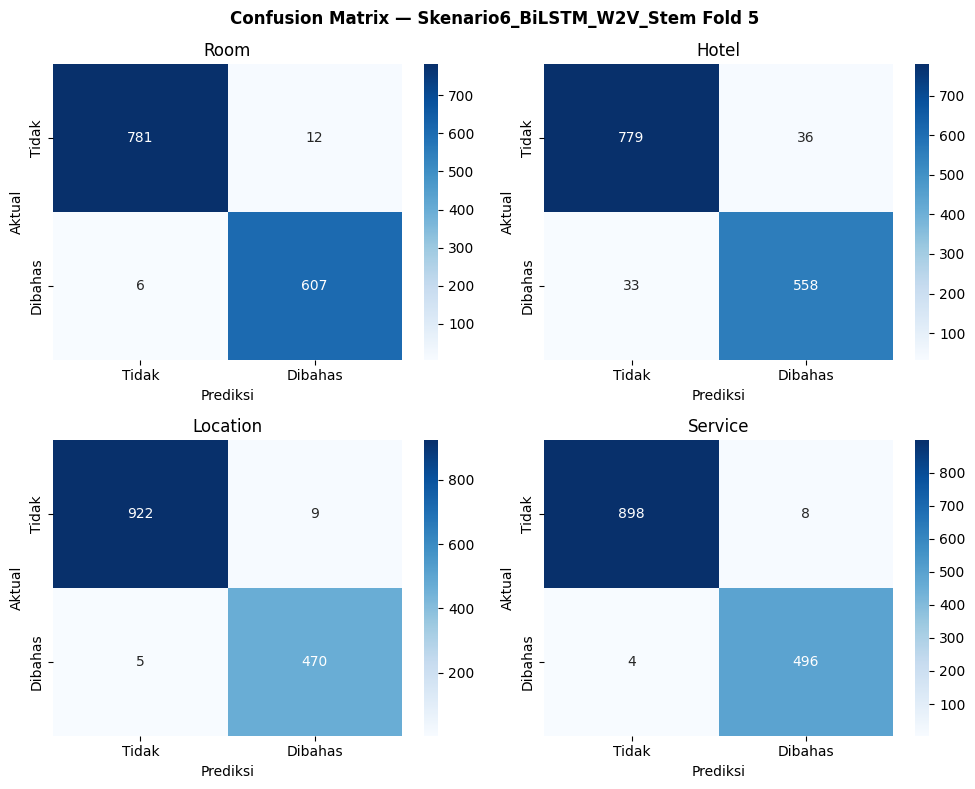

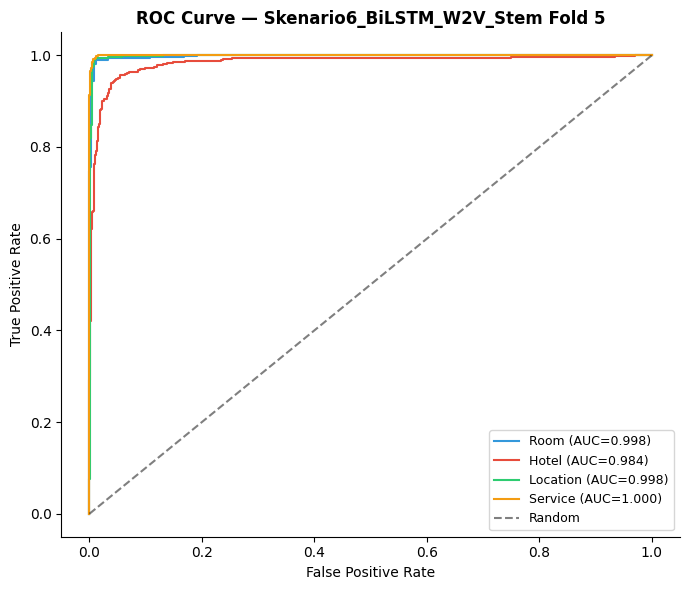


  Model disimpan (fold terakhir): /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task1_Aspek/Skenario6_BiLSTM_W2V_Stem/model.h5


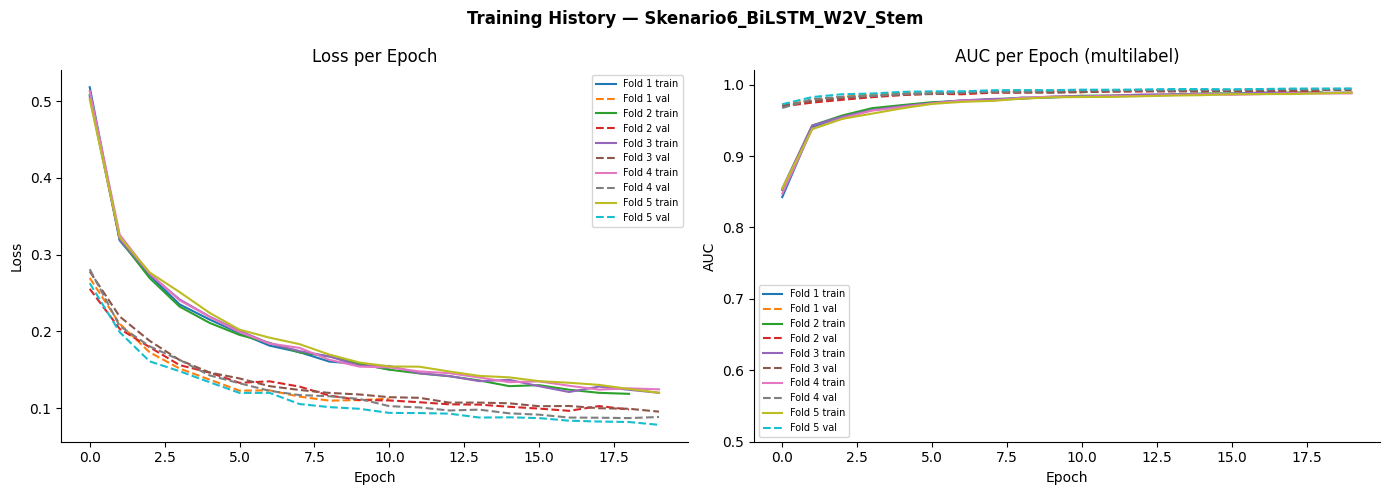


  ╔═ SELESAI: Skenario6_BiLSTM_W2V_Stem
  ║  avg Precision  : 0.9705 ± 0.0030
  ║  avg Recall     : 0.9691 ± 0.0086
  ║  avg F1 Macro   : 0.9697 ± 0.0042
  ║  avg Accuracy   : 0.9759 ± 0.0031
  ║  avg AUC Macro  : 0.9928 ± 0.0015
  ║  avg RAM        : 2945.8 MB (22.7%)
  ║  avg CPU        : 18.2 %
  ║  avg Waktu      : 750.27 detik/fold
  ║  avg T/Epoch    : 41.59 detik/epoch
  ║  avg T/Step     : 0.2377 detik/step
  ╚══════════════════════════════════════════════════


In [ ]:
# Training Skenario 6 (BiLSTM_W2V_Stem)
jalankan_skenario(skenario_list[5])


  Training: Skenario7_BiLSTM_FT_NonStem
  Membuat embedding matrix...
  Vocab tokenizer : 5,546 kata
  OOV             : 0 kata tidak ditemukan di embedding
  Shape matrix    : (5546, 100)

  ── Fold 1/5 ──
  Distribusi label per fold:
    Room      : Pos=2453, Neg=3178
    Hotel     : Pos=2362, Neg=3269
    Location  : Pos=1903, Neg=3728
    Service   : Pos=2000, Neg=3631
Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 54s 239ms/step - accuracy: 0.5537 - auc: 0.8399 - loss: 0.5207 - val_accuracy: 0.6710 - val_auc: 0.9709 - val_loss: 0.2780
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 80s 228ms/step - accuracy: 0.6597 - auc: 0.9349 - loss: 0.3359 - val_accuracy: 0.7061 - val_auc: 0.9757 - val_loss: 0.2173
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 40s 222ms/step - accuracy: 0.6869 - auc: 0.9496 - loss: 0.2828 - val_accuracy: 0.6753 - val_auc: 0.9811 - val_loss: 0.1813
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 40s 224ms/step - accuracy: 0.6874 - auc: 0.9608 - loss: 0.2439 - val_accuracy: 0.7133 - val_au

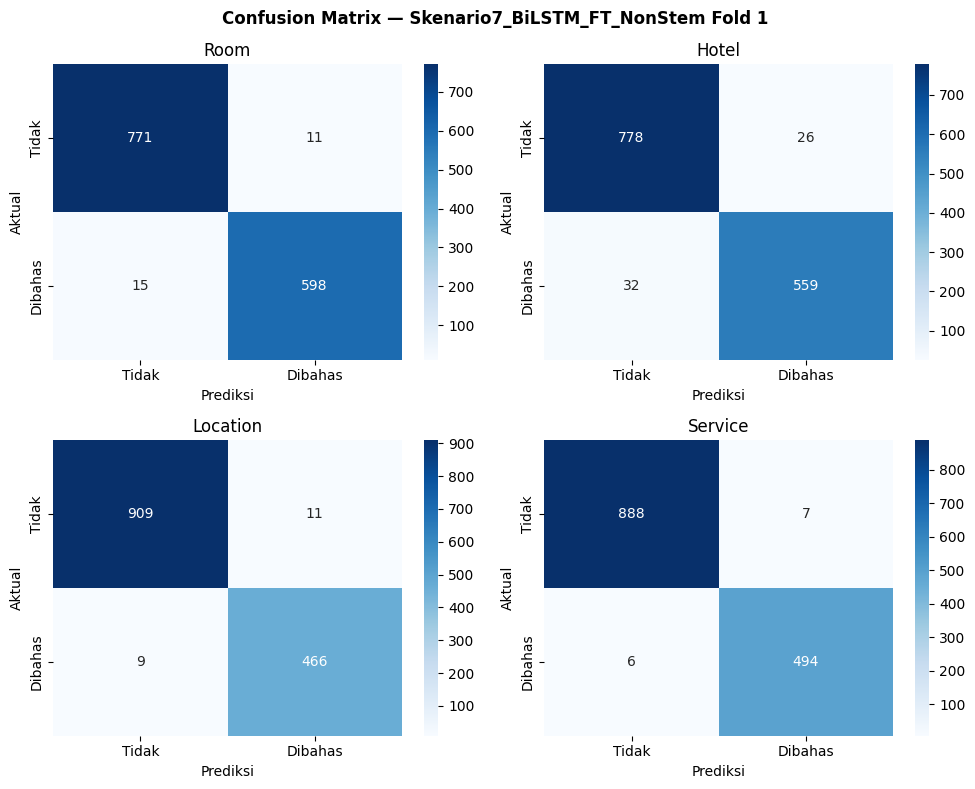

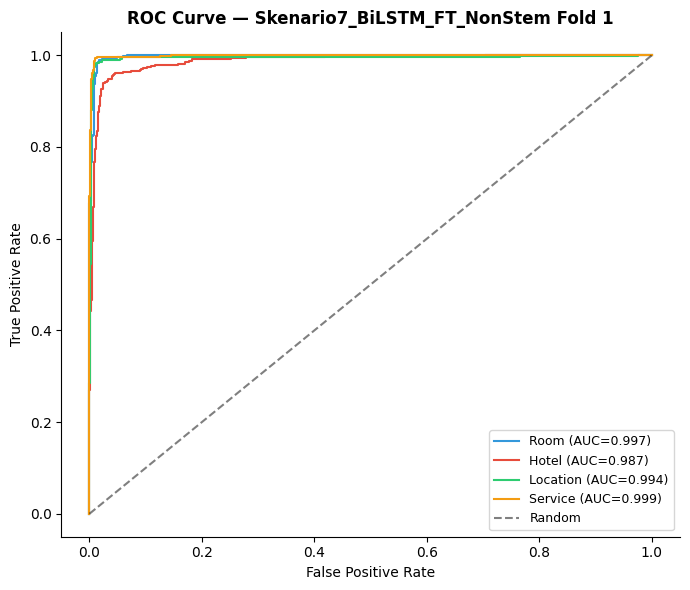


  ── Fold 2/5 ──
  Distribusi label per fold:
    Room      : Pos=2453, Neg=3162
    Hotel     : Pos=2363, Neg=3252
    Location  : Pos=1902, Neg=3713
    Service   : Pos=2000, Neg=3615
Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 49s 226ms/step - accuracy: 0.5827 - auc: 0.8506 - loss: 0.5118 - val_accuracy: 0.6712 - val_auc: 0.9673 - val_loss: 0.2745
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 40s 221ms/step - accuracy: 0.6650 - auc: 0.9380 - loss: 0.3285 - val_accuracy: 0.6938 - val_auc: 0.9724 - val_loss: 0.2195
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 42s 225ms/step - accuracy: 0.6752 - auc: 0.9511 - loss: 0.2840 - val_accuracy: 0.6931 - val_auc: 0.9749 - val_loss: 0.1879
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 40s 225ms/step - accuracy: 0.6727 - auc: 0.9604 - loss: 0.2511 - val_accuracy: 0.6407 - val_auc: 0.9780 - val_loss: 0.1707
Epoch 5/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 38s 215ms/step - accuracy: 0.6794 - auc: 0.9659 - loss: 0.2281 - val_accuracy: 0.6839 - val_auc: 0.9820 - val_loss: 0.152

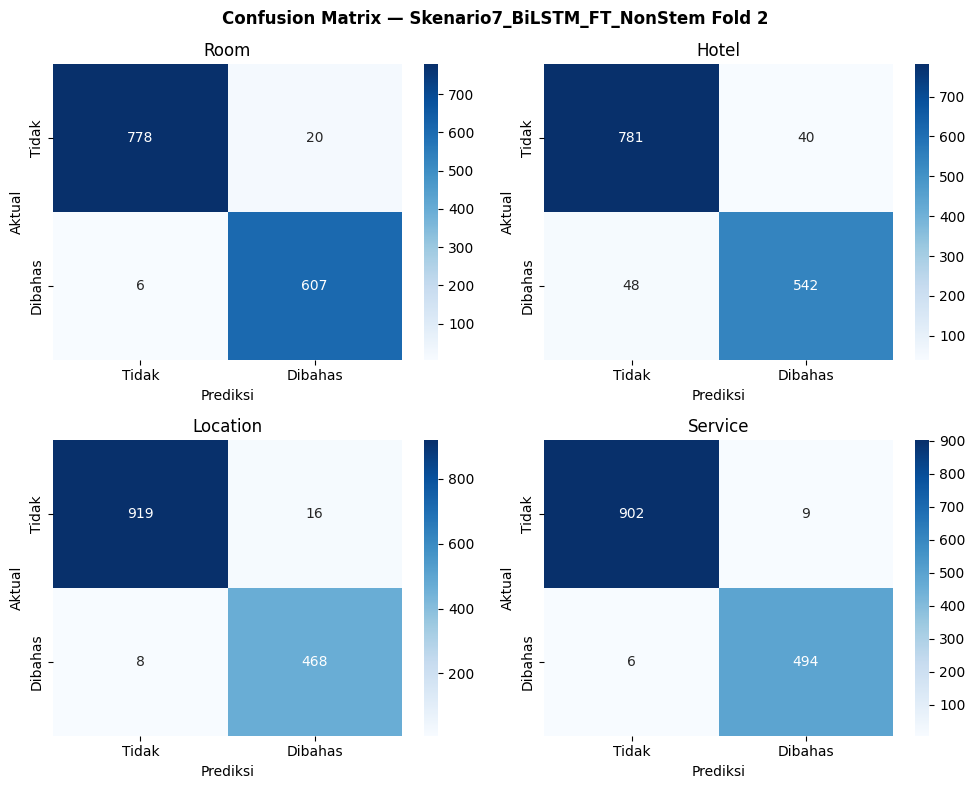

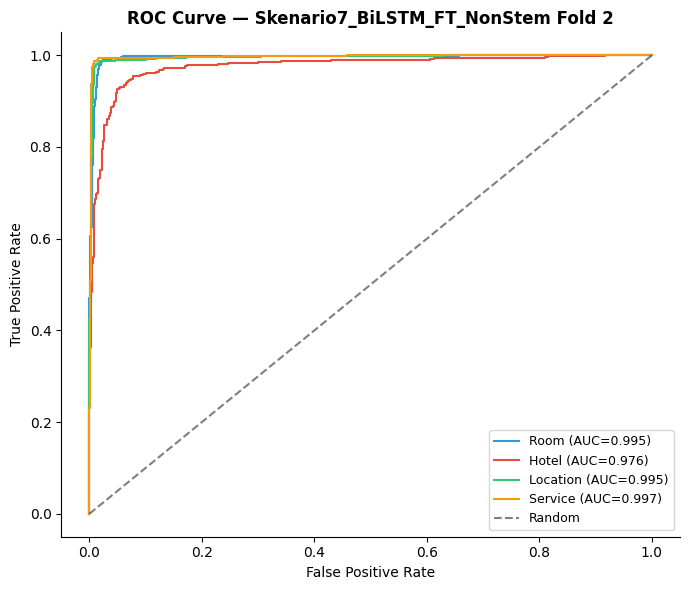


  ── Fold 3/5 ──
  Distribusi label per fold:
    Room      : Pos=2452, Neg=3155
    Hotel     : Pos=2363, Neg=3244
    Location  : Pos=1902, Neg=3705
    Service   : Pos=2000, Neg=3607
Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 53s 243ms/step - accuracy: 0.5507 - auc: 0.8451 - loss: 0.5141 - val_accuracy: 0.6300 - val_auc: 0.9641 - val_loss: 0.2858
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 79s 225ms/step - accuracy: 0.6565 - auc: 0.9342 - loss: 0.3271 - val_accuracy: 0.6561 - val_auc: 0.9725 - val_loss: 0.2248
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 40s 222ms/step - accuracy: 0.6722 - auc: 0.9487 - loss: 0.2784 - val_accuracy: 0.6751 - val_auc: 0.9774 - val_loss: 0.1905
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 41s 219ms/step - accuracy: 0.6767 - auc: 0.9576 - loss: 0.2476 - val_accuracy: 0.6646 - val_auc: 0.9801 - val_loss: 0.1721
Epoch 5/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 40s 230ms/step - accuracy: 0.6768 - auc: 0.9612 - loss: 0.2334 - val_accuracy: 0.6660 - val_auc: 0.9835 - val_loss: 0.157

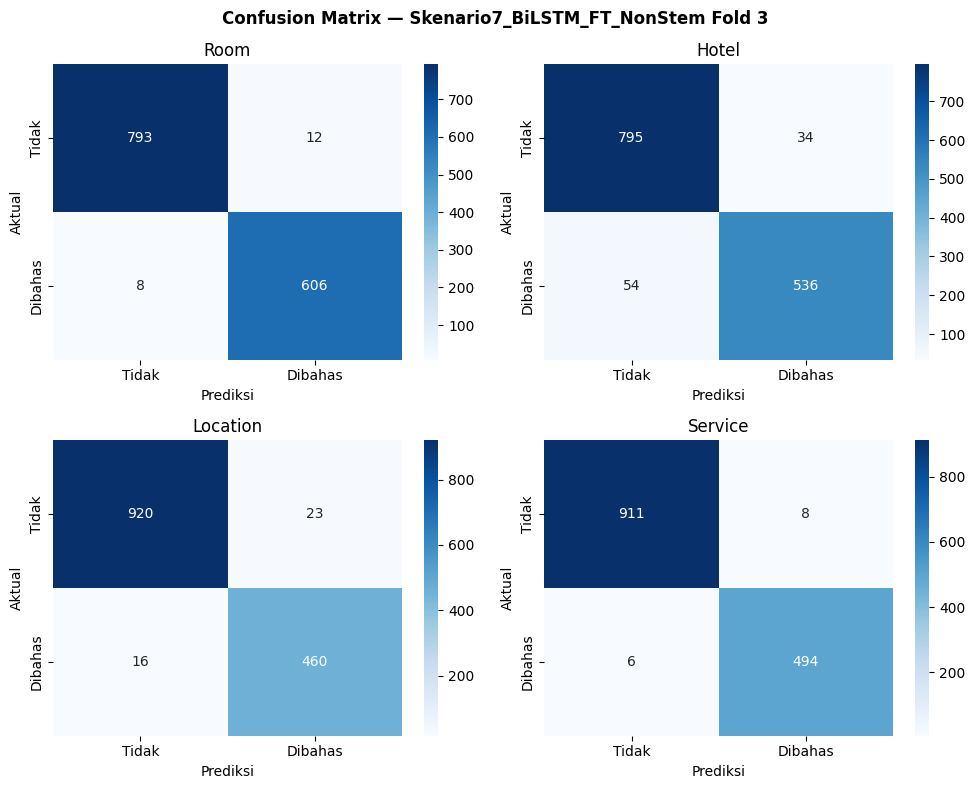

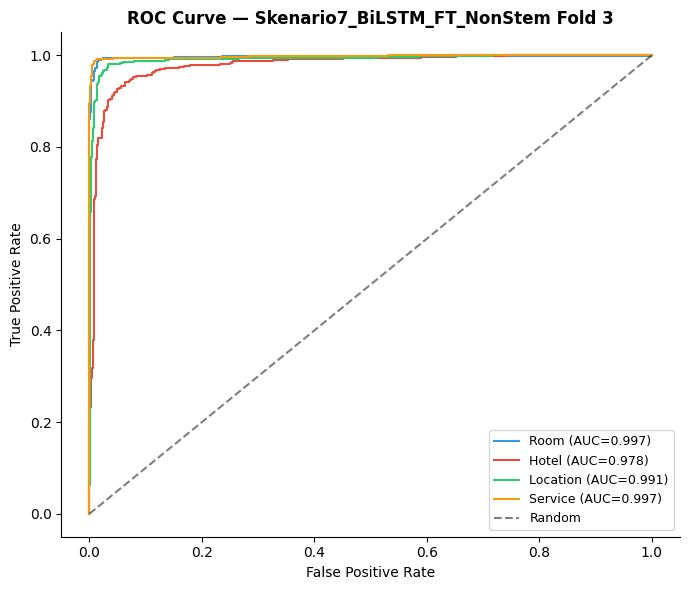


  ── Fold 4/5 ──
  Distribusi label per fold:
    Room      : Pos=2453, Neg=3178
    Hotel     : Pos=2362, Neg=3269
    Location  : Pos=1902, Neg=3729
    Service   : Pos=2000, Neg=3631
Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 49s 233ms/step - accuracy: 0.5413 - auc: 0.8313 - loss: 0.5266 - val_accuracy: 0.6918 - val_auc: 0.9624 - val_loss: 0.2940
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 40s 227ms/step - accuracy: 0.6622 - auc: 0.9322 - loss: 0.3317 - val_accuracy: 0.7290 - val_auc: 0.9738 - val_loss: 0.2264
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 39s 216ms/step - accuracy: 0.6708 - auc: 0.9500 - loss: 0.2804 - val_accuracy: 0.6839 - val_auc: 0.9798 - val_loss: 0.1871
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 40s 227ms/step - accuracy: 0.6839 - auc: 0.9629 - loss: 0.2379 - val_accuracy: 0.7018 - val_auc: 0.9834 - val_loss: 0.1595
Epoch 5/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 40s 225ms/step - accuracy: 0.6903 - auc: 0.9692 - loss: 0.2151 - val_accuracy: 0.6932 - val_auc: 0.9864 - val_loss: 0.140

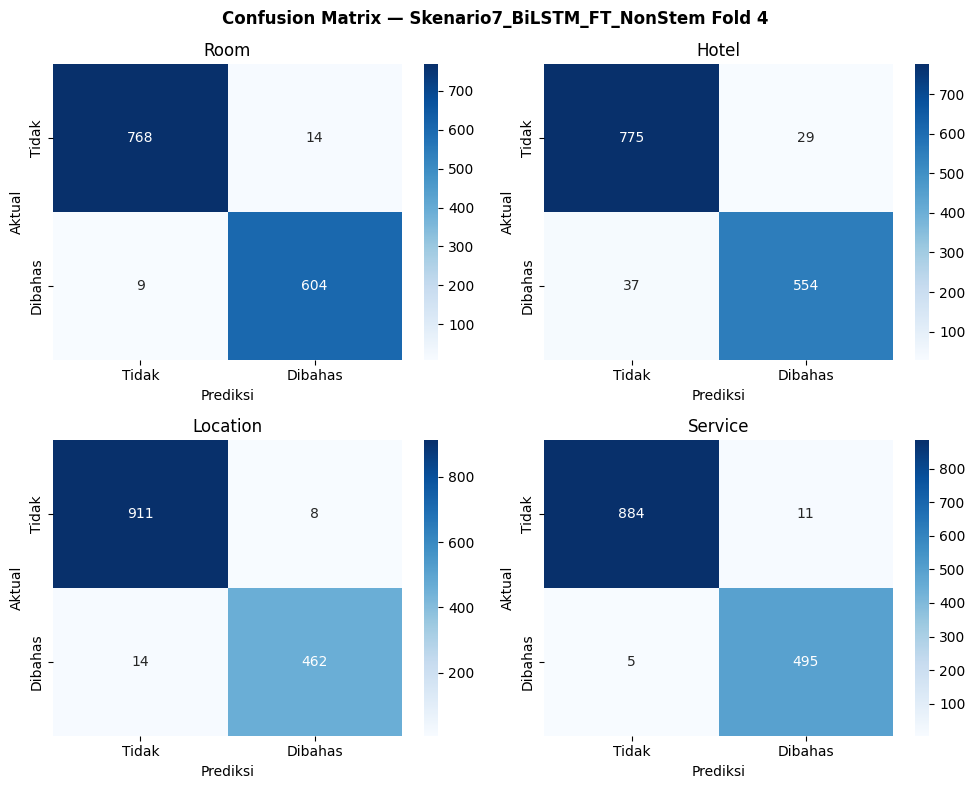

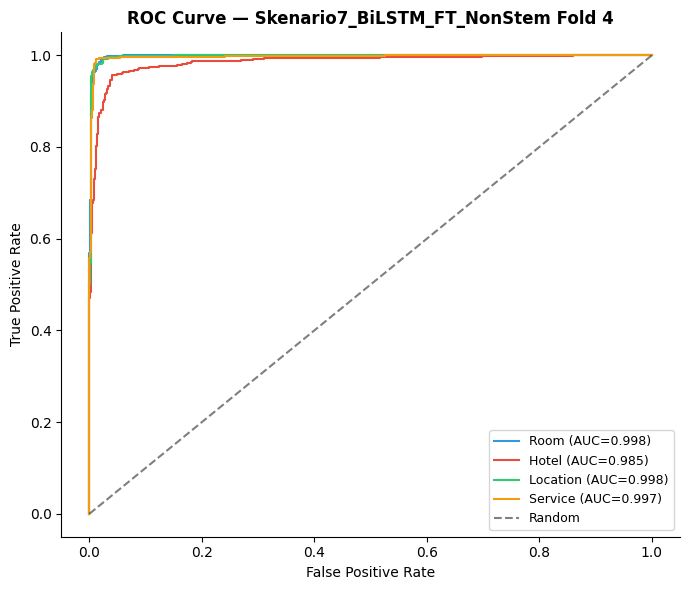


  ── Fold 5/5 ──
  Distribusi label per fold:
    Room      : Pos=2453, Neg=3167
    Hotel     : Pos=2362, Neg=3258
    Location  : Pos=1903, Neg=3717
    Service   : Pos=2000, Neg=3620
Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 50s 227ms/step - accuracy: 0.5625 - auc: 0.8387 - loss: 0.5234 - val_accuracy: 0.6572 - val_auc: 0.9682 - val_loss: 0.2843
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 39s 217ms/step - accuracy: 0.6578 - auc: 0.9321 - loss: 0.3352 - val_accuracy: 0.6693 - val_auc: 0.9793 - val_loss: 0.2079
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 44s 236ms/step - accuracy: 0.6728 - auc: 0.9490 - loss: 0.2816 - val_accuracy: 0.6799 - val_auc: 0.9810 - val_loss: 0.1811
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 40s 227ms/step - accuracy: 0.6735 - auc: 0.9589 - loss: 0.2474 - val_accuracy: 0.6550 - val_auc: 0.9857 - val_loss: 0.1527
Epoch 5/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 38s 217ms/step - accuracy: 0.6671 - auc: 0.9647 - loss: 0.2290 - val_accuracy: 0.6799 - val_auc: 0.9885 - val_loss: 0.134

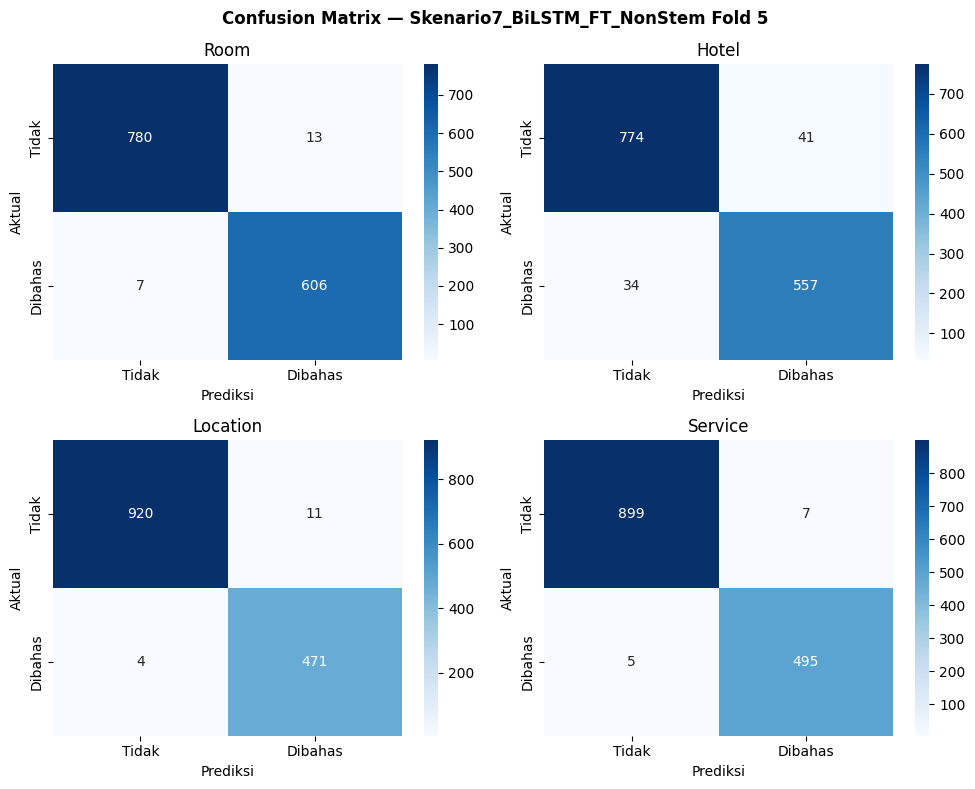

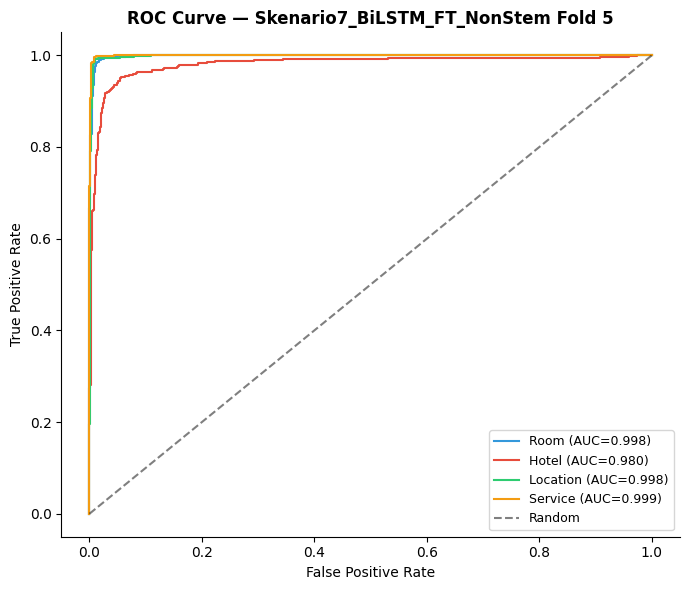


  Model disimpan (fold terakhir): /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task1_Aspek/Skenario7_BiLSTM_FT_NonStem/model.h5


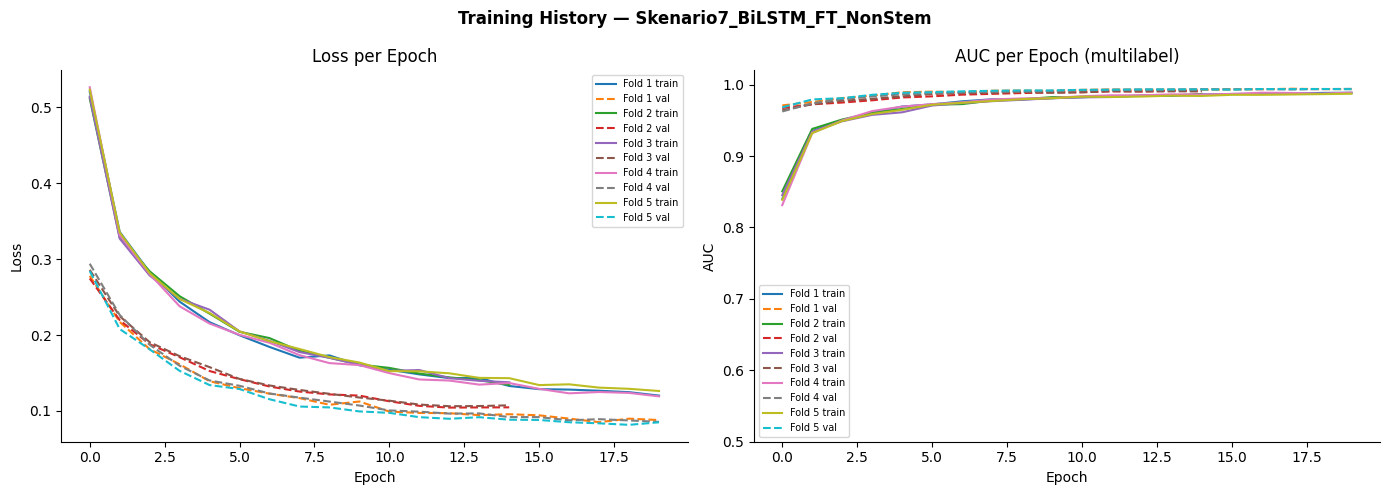


  ╔═ SELESAI: Skenario7_BiLSTM_FT_NonStem
  ║  avg Precision  : 0.9684 ± 0.0054
  ║  avg Recall     : 0.9708 ± 0.0056
  ║  avg F1 Macro   : 0.9696 ± 0.0047
  ║  avg Accuracy   : 0.9758 ± 0.0033
  ║  avg AUC Macro  : 0.9929 ± 0.0019
  ║  avg RAM        : 3298.3 MB (25.4%)
  ║  avg CPU        : 12.6 %
  ║  avg Waktu      : 776.60 detik/fold
  ║  avg T/Epoch    : 43.17 detik/epoch
  ║  avg T/Step     : 0.2467 detik/step
  ╚══════════════════════════════════════════════════


In [ ]:
# Training Skenario 7 (BiLSTM_FT_NonStem)
jalankan_skenario(skenario_list[6])


  Training: Skenario8_BiLSTM_FT_Stem
  Membuat embedding matrix...
  Vocab tokenizer : 3,812 kata
  OOV             : 0 kata tidak ditemukan di embedding
  Shape matrix    : (3812, 100)

  ── Fold 1/5 ──
  Distribusi label per fold:
    Room      : Pos=2453, Neg=3178
    Hotel     : Pos=2362, Neg=3269
    Location  : Pos=1903, Neg=3728
    Service   : Pos=2000, Neg=3631
Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 51s 227ms/step - accuracy: 0.5839 - auc: 0.8455 - loss: 0.5143 - val_accuracy: 0.6918 - val_auc: 0.9704 - val_loss: 0.2767
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 41s 228ms/step - accuracy: 0.6656 - auc: 0.9342 - loss: 0.3312 - val_accuracy: 0.6287 - val_auc: 0.9780 - val_loss: 0.2165
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 40s 228ms/step - accuracy: 0.6786 - auc: 0.9498 - loss: 0.2813 - val_accuracy: 0.7247 - val_auc: 0.9808 - val_loss: 0.1866
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 39s 221ms/step - accuracy: 0.6857 - auc: 0.9616 - loss: 0.2443 - val_accuracy: 0.6889 - val_auc: 

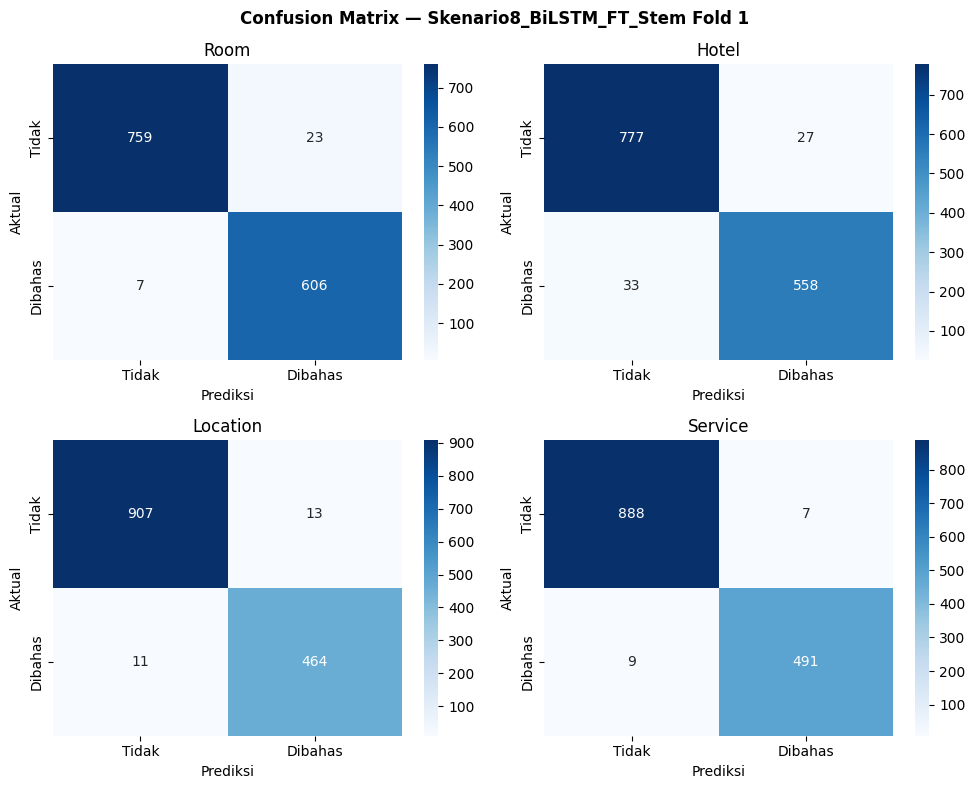

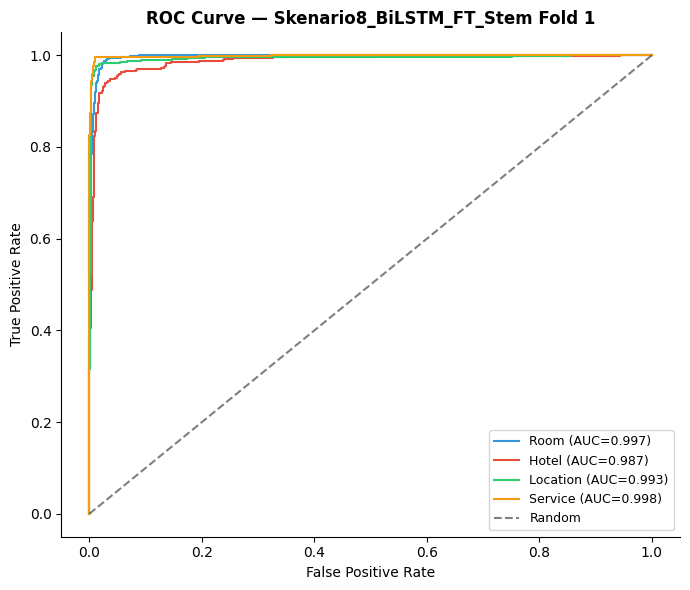


  ── Fold 2/5 ──
  Distribusi label per fold:
    Room      : Pos=2453, Neg=3162
    Hotel     : Pos=2363, Neg=3252
    Location  : Pos=1902, Neg=3713
    Service   : Pos=2000, Neg=3615
Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 51s 233ms/step - accuracy: 0.5118 - auc: 0.8272 - loss: 0.5396 - val_accuracy: 0.6790 - val_auc: 0.9645 - val_loss: 0.2877
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 38s 218ms/step - accuracy: 0.6646 - auc: 0.9315 - loss: 0.3387 - val_accuracy: 0.7052 - val_auc: 0.9708 - val_loss: 0.2187
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 42s 223ms/step - accuracy: 0.6659 - auc: 0.9501 - loss: 0.2835 - val_accuracy: 0.7236 - val_auc: 0.9733 - val_loss: 0.1951
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 43s 234ms/step - accuracy: 0.6741 - auc: 0.9593 - loss: 0.2501 - val_accuracy: 0.6676 - val_auc: 0.9815 - val_loss: 0.1659
Epoch 5/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 38s 219ms/step - accuracy: 0.6709 - auc: 0.9683 - loss: 0.2221 - val_accuracy: 0.6655 - val_auc: 0.9829 - val_loss: 0.146

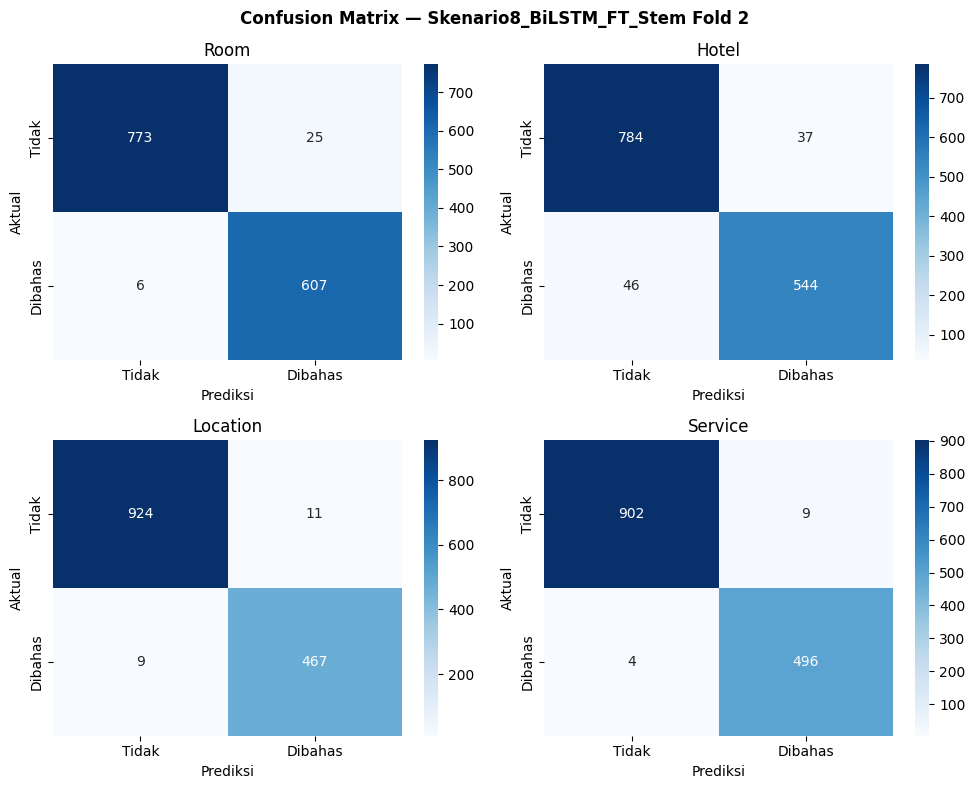

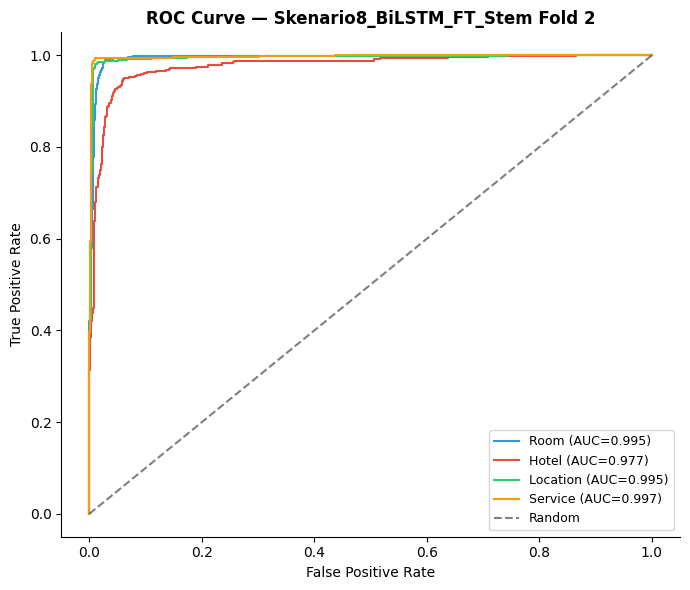


  ── Fold 3/5 ──
  Distribusi label per fold:
    Room      : Pos=2452, Neg=3155
    Hotel     : Pos=2363, Neg=3244
    Location  : Pos=1902, Neg=3705
    Service   : Pos=2000, Neg=3607
Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 52s 240ms/step - accuracy: 0.5702 - auc: 0.8312 - loss: 0.5304 - val_accuracy: 0.6540 - val_auc: 0.9664 - val_loss: 0.2942
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 38s 219ms/step - accuracy: 0.6545 - auc: 0.9354 - loss: 0.3327 - val_accuracy: 0.6857 - val_auc: 0.9747 - val_loss: 0.2216
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 40s 215ms/step - accuracy: 0.6663 - auc: 0.9522 - loss: 0.2813 - val_accuracy: 0.6751 - val_auc: 0.9776 - val_loss: 0.1953
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 40s 226ms/step - accuracy: 0.6756 - auc: 0.9588 - loss: 0.2543 - val_accuracy: 0.6603 - val_auc: 0.9827 - val_loss: 0.1674
Epoch 5/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 38s 218ms/step - accuracy: 0.6804 - auc: 0.9682 - loss: 0.2201 - val_accuracy: 0.6702 - val_auc: 0.9855 - val_loss: 0.155

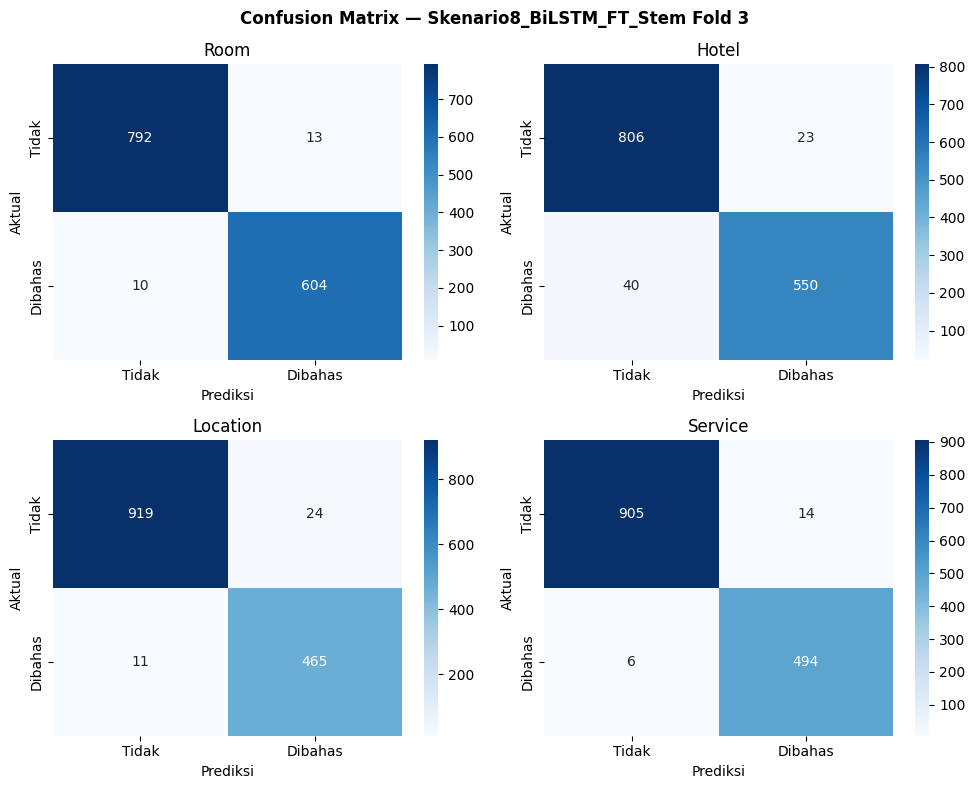

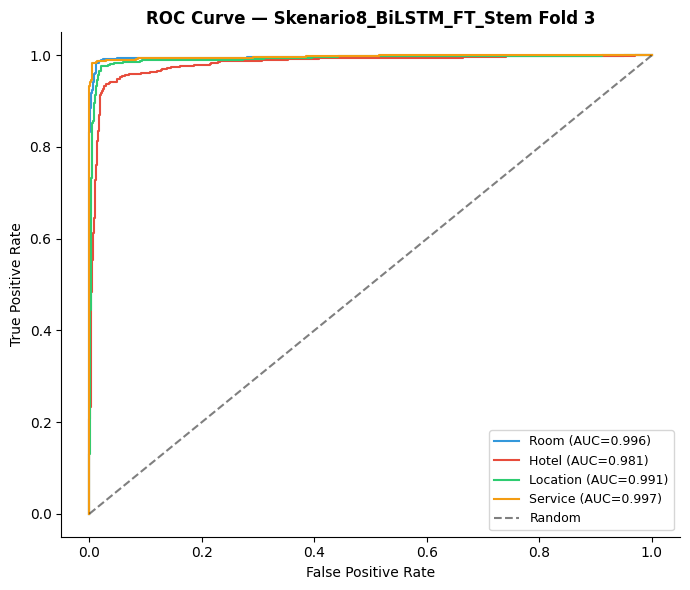


  ── Fold 4/5 ──
  Distribusi label per fold:
    Room      : Pos=2453, Neg=3178
    Hotel     : Pos=2362, Neg=3269
    Location  : Pos=1902, Neg=3729
    Service   : Pos=2000, Neg=3631
Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 51s 237ms/step - accuracy: 0.5827 - auc: 0.8337 - loss: 0.5293 - val_accuracy: 0.6996 - val_auc: 0.9643 - val_loss: 0.2949
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 81s 233ms/step - accuracy: 0.6658 - auc: 0.9312 - loss: 0.3370 - val_accuracy: 0.6781 - val_auc: 0.9754 - val_loss: 0.2128
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 40s 225ms/step - accuracy: 0.6713 - auc: 0.9490 - loss: 0.2816 - val_accuracy: 0.6953 - val_auc: 0.9782 - val_loss: 0.1895
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 41s 231ms/step - accuracy: 0.6763 - auc: 0.9598 - loss: 0.2492 - val_accuracy: 0.6961 - val_auc: 0.9849 - val_loss: 0.1532
Epoch 5/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 41s 230ms/step - accuracy: 0.6894 - auc: 0.9655 - loss: 0.2267 - val_accuracy: 0.6781 - val_auc: 0.9861 - val_loss: 0.143

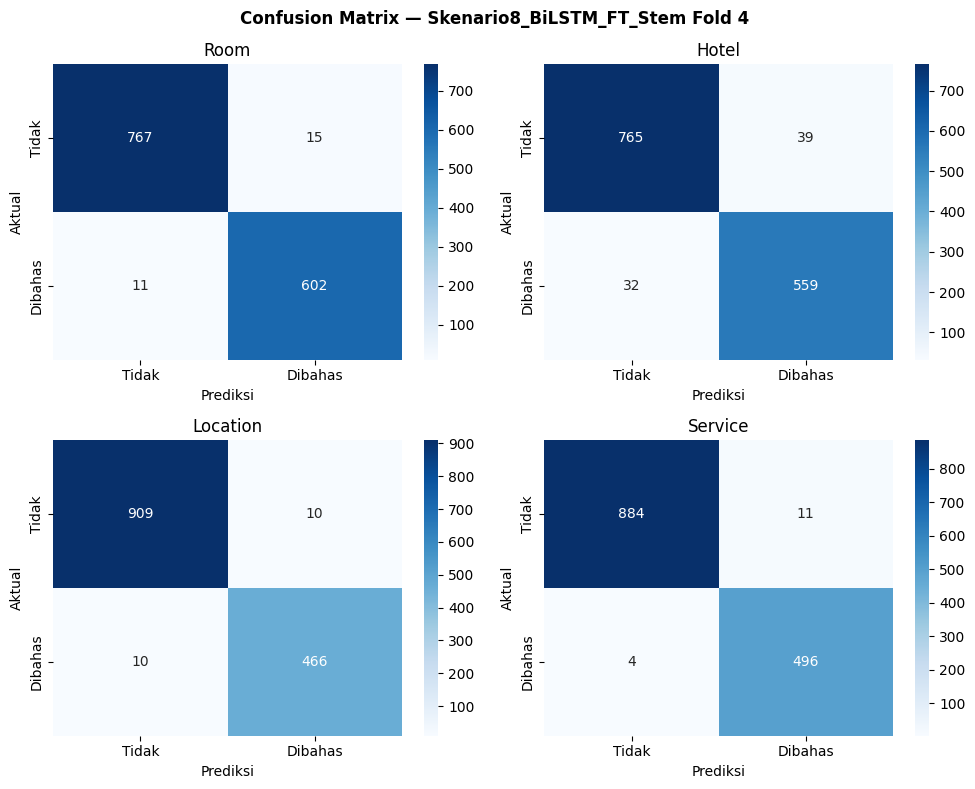

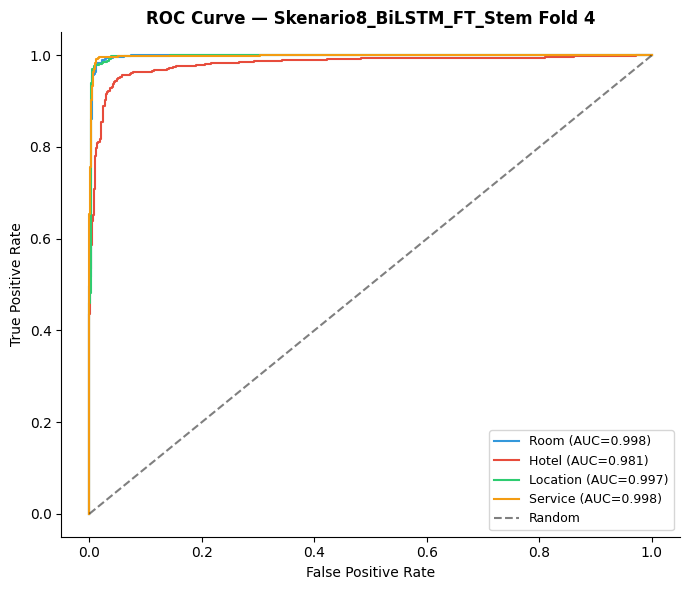


  ── Fold 5/5 ──
  Distribusi label per fold:
    Room      : Pos=2453, Neg=3167
    Hotel     : Pos=2362, Neg=3258
    Location  : Pos=1903, Neg=3717
    Service   : Pos=2000, Neg=3620
Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 54s 241ms/step - accuracy: 0.5495 - auc: 0.8469 - loss: 0.5153 - val_accuracy: 0.6394 - val_auc: 0.9707 - val_loss: 0.2874
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 81s 239ms/step - accuracy: 0.6667 - auc: 0.9317 - loss: 0.3413 - val_accuracy: 0.6956 - val_auc: 0.9820 - val_loss: 0.2054
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 38s 216ms/step - accuracy: 0.6731 - auc: 0.9481 - loss: 0.2893 - val_accuracy: 0.6643 - val_auc: 0.9848 - val_loss: 0.1753
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 41s 217ms/step - accuracy: 0.6749 - auc: 0.9590 - loss: 0.2535 - val_accuracy: 0.6714 - val_auc: 0.9879 - val_loss: 0.1480
Epoch 5/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 40s 229ms/step - accuracy: 0.6897 - auc: 0.9677 - loss: 0.2230 - val_accuracy: 0.6472 - val_auc: 0.9885 - val_loss: 0.138

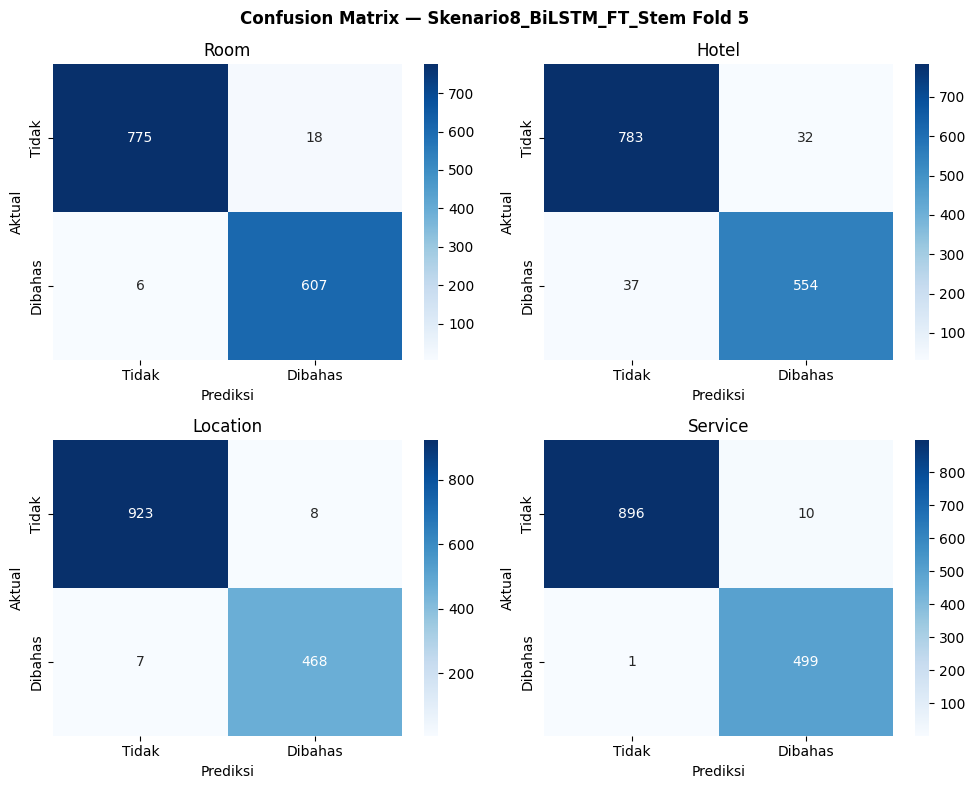

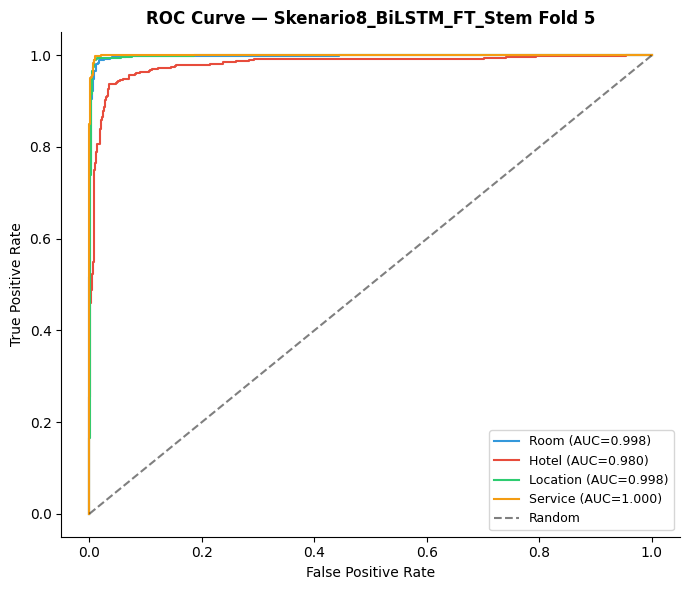


  Model disimpan (fold terakhir): /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task1_Aspek/Skenario8_BiLSTM_FT_Stem/model.h5


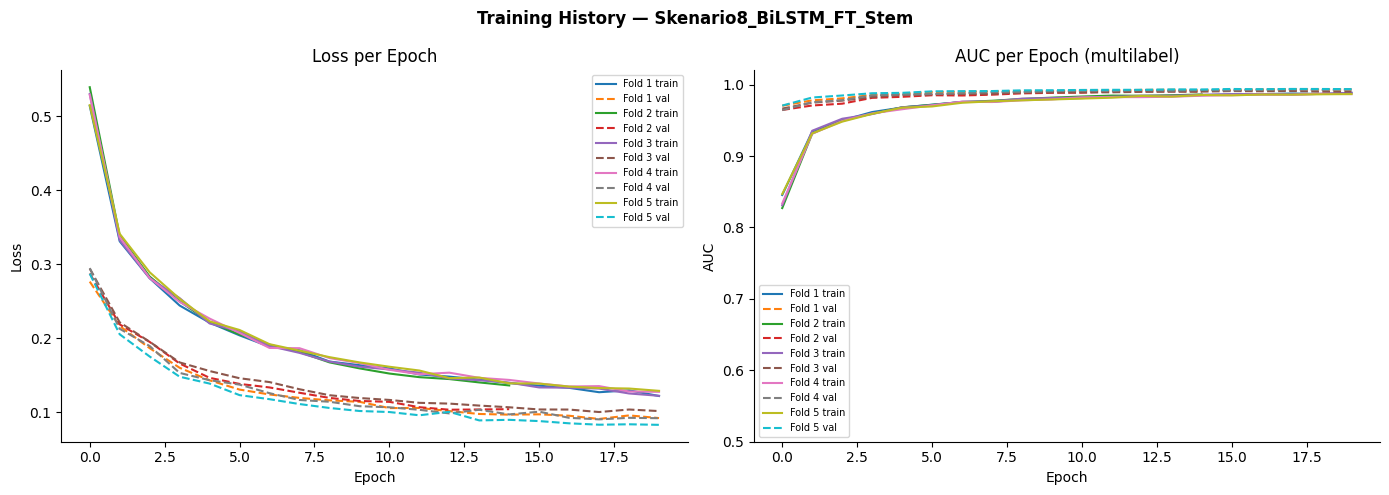


  ╔═ SELESAI: Skenario8_BiLSTM_FT_Stem
  ║  avg Precision  : 0.9671 ± 0.0025
  ║  avg Recall     : 0.9734 ± 0.0030
  ║  avg F1 Macro   : 0.9702 ± 0.0026
  ║  avg Accuracy   : 0.9762 ± 0.0018
  ║  avg AUC Macro  : 0.9927 ± 0.0015
  ║  avg RAM        : 3645.9 MB (28.1%)
  ║  avg CPU        : 2.4 %
  ║  avg Waktu      : 798.51 detik/fold
  ║  avg T/Epoch    : 41.89 detik/epoch
  ║  avg T/Step     : 0.2394 detik/step
  ╚══════════════════════════════════════════════════


In [ ]:
# Training Skenario 8 (BiLSTM_FT_Stem)
jalankan_skenario(skenario_list[7])

In [ ]:
import pandas as pd
import numpy as np

# ============================================================
# INVESTIGASI SKENARIO 1 — Cek F1 per label
# ============================================================

# Load metrics per fold
metrics_path = OUTPUT_DIR + 'Skenario1_CNN_W2V_NonStem/metrics_per_fold.csv'
df_metrics   = pd.read_csv(metrics_path)

print("="*60)
print("  CEK F1 PER LABEL — Skenario 1 CNN W2V NonStem")
print("="*60)

print("\nF1 per label per fold:")
display(df_metrics[['fold', 'f1_macro',
                     'f1_Room', 'f1_Hotel',
                     'f1_Location', 'f1_Service']])

print("\nRata-rata F1 per label:")
for col in ['f1_macro', 'f1_Room', 'f1_Hotel',
            'f1_Location', 'f1_Service']:
    avg = df_metrics[col].mean()
    std = df_metrics[col].std()
    print(f"  {col:20s}: {avg:.4f} ± {std:.4f}")

# ============================================================
# Cek prediksi secara manual
# ============================================================
print("\n" + "="*60)
print("  CEK PREDIKSI MANUAL — 10 sampel dari fold 1")
print("="*60)

pred_path = OUTPUT_DIR + 'Skenario1_CNN_W2V_NonStem/predictions_all_folds.csv'
df_pred   = pd.read_csv(pred_path)

# Ambil fold 1
fold1 = df_pred[df_pred['fold'] == 1].head(10)
for _, row in fold1.iterrows():
    print(f"\nTeks  : {str(row['review_non_stemmed'])[:70]}")
    print(f"Asli  : Room={int(row['Room_label'])} Hotel={int(row['Hotel_label'])} "
          f"Location={int(row['Location_label'])} Service={int(row['Service_label'])}")
    print(f"Pred  : Room={int(row['pred_Room'])} Hotel={int(row['pred_Hotel'])} "
          f"Location={int(row['pred_Location'])} Service={int(row['pred_Service'])}")
    benar = (int(row['Room_label'])==int(row['pred_Room']) and
             int(row['Hotel_label'])==int(row['pred_Hotel']) and
             int(row['Location_label'])==int(row['pred_Location']) and
             int(row['Service_label'])==int(row['pred_Service']))
    print(f"Status: {'✅ BENAR SEMUA' if benar else '❌ ADA YANG SALAH'}")

# ============================================================
# Dummy classifier baseline
# ============================================================
print("\n" + "="*60)
print("  DUMMY CLASSIFIER BASELINE")
print("  Kalau model tebak majority class semua, F1 berapa?")
print("="*60)

from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score

y_all = df_pred[['Room_label','Hotel_label',
                 'Location_label','Service_label']].values

for i, col in enumerate(['Room','Hotel','Location','Service']):
    majority_class = 1 if (y_all[:,i]==1).sum() > (y_all[:,i]==0).sum() else 0
    y_dummy = np.full(len(y_all), majority_class)
    f1_dummy = f1_score(y_all[:,i], y_dummy, average='binary', zero_division=0)
    f1_model = df_metrics[f'f1_{col}'].mean()
    selisih  = f1_model - f1_dummy
    print(f"  {col:10s}: dummy={f1_dummy:.4f} | "
          f"model={f1_model:.4f} | "
          f"selisih=+{selisih:.4f}")

  CEK F1 PER LABEL — Skenario 1 CNN W2V NonStem

F1 per label per fold:


,fold,f1_macro,f1_Room,f1_Hotel,f1_Location,f1_Service
0,1,0.963528,0.978102,0.918206,0.976939,0.980866
1,2,0.963071,0.975806,0.916376,0.980063,0.980040
2,3,0.961164,0.975728,0.922676,0.960251,0.986000
3,4,0.963303,0.969745,0.926407,0.975967,0.981095
4,5,0.967294,0.973597,0.930233,0.982162,0.983185



Rata-rata F1 per label:
  f1_macro            : 0.9637 ± 0.0022
  f1_Room             : 0.9746 ± 0.0031
  f1_Hotel            : 0.9228 ± 0.0057
  f1_Location         : 0.9751 ± 0.0086
  f1_Service          : 0.9822 ± 0.0024

  CEK PREDIKSI MANUAL — 10 sampel dari fold 1

Teks  : sekeluarga senang kamarnya bersih nyaman area taman sangat rapi indah 
Asli  : Room=1 Hotel=1 Location=0 Service=0
Pred  : Room=1 Hotel=1 Location=0 Service=0
Status: ✅ BENAR SEMUA

Teks  : lokasinya bangus banget mau kemana dekat bisa jalan kaki kamarnya nyam
Asli  : Room=1 Hotel=0 Location=1 Service=0
Pred  : Room=1 Hotel=0 Location=1 Service=0
Status: ✅ BENAR SEMUA

Teks  : lampu kamar agak redup agak merinding kamar
Asli  : Room=1 Hotel=0 Location=0 Service=0
Pred  : Room=1 Hotel=0 Location=0 Service=0
Status: ✅ BENAR SEMUA

Teks  : hotel suasana classic elegant kebersihan sangat baik luar biasa
Asli  : Room=0 Hotel=1 Location=0 Service=0
Pred  : Room=0 Hotel=1 Location=0 Service=0
Status: ✅ BENAR SEMUA

T

## 8. Rekap Hasil & Simpan ke Excel

In [ ]:
# Load rekap CSV lalu simpan ke Excel
df_rekap = pd.read_csv(OUTPUT_DIR + 'rekap_Task1_semua_skenario.csv')
df_rekap = df_rekap.sort_values('avg_f1_macro', ascending=False).reset_index(drop=True)
df_rekap.insert(0, 'rank', range(1, len(df_rekap) + 1))

print('='*110)
print('  REKAP SEMUA SKENARIO TASK 1 — DETEKSI ASPEK')
print('  Diurutkan berdasarkan F1 Macro Tertinggi')
print('='*110)

cols_utama = [c for c in [
    'rank', 'skenario',
    'avg_f1_macro',        'std_f1_macro',
    'avg_precision_macro', 'std_precision_macro',
    'avg_recall_macro',    'std_recall_macro',
    'avg_accuracy',        'std_accuracy',
    'avg_auc_macro',       'std_auc_macro',
    'avg_hamming_loss',    'std_hamming_loss',
    'avg_subset_accuracy', 'std_subset_accuracy',
] if c in df_rekap.columns]

cols_per_label = [c for c in [
    'rank', 'skenario',
    'avg_f1_Room',     'avg_f1_Hotel',
    'avg_f1_Location', 'avg_f1_Service',
    'avg_acc_Room',    'avg_acc_Hotel',
    'avg_acc_Location','avg_acc_Service',
] if c in df_rekap.columns]

cols_resource = [c for c in [
    'rank', 'skenario',
    'avg_waktu_training',  'std_waktu_training',
    'avg_waktu_inference', 'std_waktu_inference',
    'avg_time_per_epoch',  'std_time_per_epoch',
    'avg_time_per_step',   'std_time_per_step',
    'avg_ram_mb',          'std_ram_mb',
    'avg_ram_pct',         'std_ram_pct',
    'avg_cpu_pct',         'std_cpu_pct',
    'avg_epoch_berhenti',  'std_epoch_berhenti',
] if c in df_rekap.columns]

print('\n── Metrik Performa ──')
print(df_rekap[cols_utama].to_string(index=False))

print('\n── Metrik per Label ──')
print(df_rekap[cols_per_label].to_string(index=False))

print('\n── Resource Usage ──')
print(df_rekap[cols_resource].to_string(index=False))

best = df_rekap.iloc[0]
print('\n' + '='*110)
print(f'  🏆 MODEL TERBAIK : {best["skenario"]}')
print(f'     F1 Macro     : {best["avg_f1_macro"]:.4f} ± {best["std_f1_macro"]:.4f}')
print(f'     Precision    : {best["avg_precision_macro"]:.4f} ± {best["std_precision_macro"]:.4f}')
print(f'     Recall       : {best["avg_recall_macro"]:.4f} ± {best["std_recall_macro"]:.4f}')
print(f'     Accuracy     : {best["avg_accuracy"]:.4f} ± {best["std_accuracy"]:.4f}')
print(f'     AUC Macro    : {best["avg_auc_macro"]:.4f} ± {best["std_auc_macro"]:.4f}')
if 'avg_time_per_epoch' in df_rekap.columns:
    print(f'     T/Epoch      : {best["avg_time_per_epoch"]:.2f} detik/epoch')
if 'avg_ram_pct' in df_rekap.columns:
    print(f'     RAM          : {best["avg_ram_mb"]:.1f} MB ({best["avg_ram_pct"]:.1f}%)')
print('='*110)

excel_path = OUTPUT_DIR + 'rekap_Task1_semua_skenario.xlsx'
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    df_rekap.to_excel(writer, sheet_name='Rekap_Lengkap', index=False)
    df_rekap[cols_utama].to_excel(writer, sheet_name='Metrik_Performa', index=False)
    df_rekap[cols_per_label].to_excel(writer, sheet_name='Metrik_per_Label', index=False)
    if cols_resource:
        df_rekap[cols_resource].to_excel(writer, sheet_name='Resource_Usage', index=False)

print(f'\n✅ Disimpan ke : {excel_path}')
print(f'   Sheet 1     : Rekap_Lengkap')
print(f'   Sheet 2     : Metrik_Performa')
print(f'   Sheet 3     : Metrik_per_Label')
print(f'   Sheet 4     : Resource_Usage')


  REKAP SEMUA SKENARIO TASK 1 — DETEKSI ASPEK
  Diurutkan berdasarkan F1 Macro Tertinggi

── Metrik Performa ──
 rank                     skenario  avg_f1_macro  std_f1_macro  avg_precision_macro  std_precision_macro  avg_recall_macro  std_recall_macro  avg_accuracy  std_accuracy  avg_auc_macro  std_auc_macro  avg_hamming_loss  std_hamming_loss  avg_subset_accuracy  std_subset_accuracy
    1     Skenario8_BiLSTM_FT_Stem        0.9702        0.0026               0.9671               0.0025            0.9734            0.0030        0.9762        0.0018         0.9927         0.0015            0.0238            0.0018               0.9155               0.0072
    2 Skenario5_BiLSTM_W2V_NonStem        0.9698        0.0037               0.9667               0.0044            0.9732            0.0064        0.9760        0.0027         0.9935         0.0011            0.0240            0.0027               0.9134               0.0093
    3    Skenario6_BiLSTM_W2V_Stem        0.9697        0

In [ ]:
import os
import pandas as pd
import numpy as np

OUTPUT_DIR = '/content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task1_Aspek/'

skenario_list = [
    'Skenario1_CNN_W2V_NonStem',
    'Skenario2_CNN_W2V_Stem',
    'Skenario3_CNN_FT_NonStem',
    'Skenario4_CNN_FT_Stem',
    'Skenario5_BiLSTM_W2V_NonStem',
    'Skenario6_BiLSTM_W2V_Stem',
    'Skenario7_BiLSTM_FT_NonStem',
    'Skenario8_BiLSTM_FT_Stem',
]

rekap = []

for nama in skenario_list:
    csv_path = OUTPUT_DIR + nama + '/metrics_per_fold.csv'

    if not os.path.exists(csv_path):
        print(f'⏭  Skip {nama} — belum ada CSV')
        continue

    df = pd.read_csv(csv_path)

    row = {'skenario': nama}

    # Hitung avg dan std untuk semua kolom numerik
    for col in df.select_dtypes(include=np.number).columns:
        if col == 'fold':
            continue
        row[f'avg_{col}'] = df[col].mean()
        row[f'std_{col}'] = df[col].std()

    rekap.append(row)
    print(f' {nama} — {len(df)} fold')

# Buat dataframe rekap
df_rekap = pd.DataFrame(rekap)
df_rekap = df_rekap.sort_values('avg_f1_macro', ascending=False).reset_index(drop=True)
df_rekap.insert(0, 'rank', range(1, len(df_rekap) + 1))

# Tampilkan
print('\n' + '='*80)
print('  REKAP TASK 1 — DETEKSI ASPEK')
print('='*80)

cols_tampil = [c for c in [
    'rank', 'skenario',
    'avg_f1_macro', 'std_f1_macro',
    'avg_precision_macro', 'avg_recall_macro',
    'avg_accuracy', 'avg_auc_macro',
    'avg_hamming_loss', 'avg_waktu_training'
] if c in df_rekap.columns]

print(df_rekap[cols_tampil].to_string(index=False))

# Highlight terbaik
best = df_rekap.iloc[0]
print(f'\n Terbaik: {best["skenario"]} — F1={best["avg_f1_macro"]:.4f}')

# Simpan ulang ke CSV dan Excel
df_rekap.to_csv(OUTPUT_DIR + 'rekap_Task1_semua_skenario.csv', index=False)

with pd.ExcelWriter(OUTPUT_DIR + 'rekap_Task1_semua_skenario.xlsx', engine='openpyxl') as writer:
    df_rekap.to_excel(writer, sheet_name='Rekap_Lengkap', index=False)
    df_rekap[cols_tampil].to_excel(writer, sheet_name='Ringkasan_Dosen', index=False)

print(f'\n CSV dan Excel berhasil disimpan ulang!')

 Skenario1_CNN_W2V_NonStem — 5 fold
 Skenario2_CNN_W2V_Stem — 5 fold
 Skenario3_CNN_FT_NonStem — 5 fold
 Skenario4_CNN_FT_Stem — 5 fold
 Skenario5_BiLSTM_W2V_NonStem — 5 fold
 Skenario6_BiLSTM_W2V_Stem — 5 fold
 Skenario7_BiLSTM_FT_NonStem — 5 fold
 Skenario8_BiLSTM_FT_Stem — 5 fold

  REKAP TASK 1 — DETEKSI ASPEK
 rank                     skenario  avg_f1_macro  std_f1_macro  avg_precision_macro  avg_recall_macro  avg_accuracy  avg_auc_macro  avg_hamming_loss  avg_waktu_training
    1     Skenario8_BiLSTM_FT_Stem      0.970175      0.002591             0.967098          0.973375      0.976200       0.992698          0.023800             798.508
    2 Skenario5_BiLSTM_W2V_NonStem      0.969833      0.003742             0.966662          0.973174      0.975994       0.993527          0.024006             757.766
    3    Skenario6_BiLSTM_W2V_Stem      0.969701      0.004177             0.970451          0.969095      0.975944       0.992837          0.024056             750.268
    4  S

In [ ]:
import os
import pandas as pd
import numpy as np

OUTPUT_DIR = '/content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task1_Aspek/'

skenario_list = [
    'Skenario1_CNN_W2V_NonStem',
    'Skenario2_CNN_W2V_Stem',
    'Skenario3_CNN_FT_NonStem',
    'Skenario4_CNN_FT_Stem',
    'Skenario5_BiLSTM_W2V_NonStem',
    'Skenario6_BiLSTM_W2V_Stem',
    'Skenario7_BiLSTM_FT_NonStem',
    'Skenario8_BiLSTM_FT_Stem',
]

rekap = []

for nama in skenario_list:
    csv_path = OUTPUT_DIR + nama + '/metrics_per_fold.csv'
    if not os.path.exists(csv_path):
        print(f'⏭  Skip {nama} — belum ada CSV')
        continue

    df = pd.read_csv(csv_path)
    row = {'skenario': nama}

    for col in df.select_dtypes(include=np.number).columns:
        if col in ['fold']:
            continue
        row[f'avg_{col}'] = df[col].mean()
        row[f'std_{col}'] = df[col].std()

    rekap.append(row)
    print(f' {nama} — {len(df)} fold')

df_rekap = pd.DataFrame(rekap)
df_rekap = df_rekap.sort_values('avg_f1_macro', ascending=False).reset_index(drop=True)
df_rekap.insert(0, 'rank', range(1, len(df_rekap) + 1))

# Tampilan 1: Metrik Performa
print('\n' + '='*110)
print('  REKAP TASK 1 — Metrik Performa')
print('='*110)

cols_performa = [c for c in [
    'rank', 'skenario',
    'avg_f1_macro',        'std_f1_macro',
    'avg_precision_macro', 'std_precision_macro',
    'avg_recall_macro',    'std_recall_macro',
    'avg_accuracy',        'std_accuracy',
    'avg_auc_macro',       'std_auc_macro',
    'avg_hamming_loss',    'std_hamming_loss',
] if c in df_rekap.columns]

print(df_rekap[cols_performa].to_string(index=False))

# Tampilan 2: F1 per Label
print('\n' + '='*110)
print('  REKAP TASK 1 — F1 per Label')
print('='*110)

cols_f1label = [c for c in [
    'rank', 'skenario',
    'avg_f1_Room',     'avg_f1_Hotel',
    'avg_f1_Location', 'avg_f1_Service',
    'avg_acc_Room',    'avg_acc_Hotel',
    'avg_acc_Location','avg_acc_Service',
] if c in df_rekap.columns]

print(df_rekap[cols_f1label].to_string(index=False))

# Tampilan 3: Resource Usage
print('\n' + '='*110)
print('  REKAP TASK 1 — Resource Usage')
print('='*110)

cols_resource = [c for c in [
    'rank', 'skenario',
    'avg_waktu_training',  'std_waktu_training',
    'avg_waktu_inference', 'std_waktu_inference',
    'avg_ram_mb',          'std_ram_mb',
    'avg_cpu_pct',         'std_cpu_pct',
    'avg_epoch_berhenti',  'std_epoch_berhenti',
] if c in df_rekap.columns]

print(df_rekap[cols_resource].to_string(index=False))

# Highlight terbaik
best = df_rekap.iloc[0]
print('\n' + '='*110)
print(f'     MODEL TERBAIK : {best["skenario"]}')
print(f'     F1 Macro     : {best["avg_f1_macro"]:.4f} ± {best["std_f1_macro"]:.4f}')
print(f'     Precision    : {best["avg_precision_macro"]:.4f} ± {best["std_precision_macro"]:.4f}')
print(f'     Recall       : {best["avg_recall_macro"]:.4f} ± {best["std_recall_macro"]:.4f}')
print(f'     Accuracy     : {best["avg_accuracy"]:.4f} ± {best["std_accuracy"]:.4f}')
print(f'     AUC          : {best["avg_auc_macro"]:.4f} ± {best["std_auc_macro"]:.4f}')
print(f'     Hamming Loss : {best["avg_hamming_loss"]:.4f}')
print(f'     Waktu Train  : {best["avg_waktu_training"]:.2f} detik/fold')
print(f'     RAM          : {best["avg_ram_mb"]:.1f} MB')
print('='*110)

# Simpan CSV dan Excel
df_rekap.to_csv(OUTPUT_DIR + 'rekap_Task1_semua_skenario.csv', index=False)

with pd.ExcelWriter(OUTPUT_DIR + 'rekap_Task1_semua_skenario.xlsx', engine='openpyxl') as writer:
    df_rekap.to_excel(writer, sheet_name='Rekap_Lengkap', index=False)
    df_rekap[cols_performa].to_excel(writer, sheet_name='Metrik_Performa', index=False)
    df_rekap[cols_f1label].to_excel(writer, sheet_name='F1_per_Label', index=False)
    df_rekap[cols_resource].to_excel(writer, sheet_name='Resource_Usage', index=False)

print(f'\n Disimpan ke rekap_Task1_semua_skenario.xlsx')
print(f'   Sheet 1: Rekap_Lengkap')
print(f'   Sheet 2: Metrik_Performa')
print(f'   Sheet 3: F1_per_Label')
print(f'   Sheet 4: Resource_Usage')

 Skenario1_CNN_W2V_NonStem — 5 fold
 Skenario2_CNN_W2V_Stem — 5 fold
 Skenario3_CNN_FT_NonStem — 5 fold
 Skenario4_CNN_FT_Stem — 5 fold
 Skenario5_BiLSTM_W2V_NonStem — 5 fold
 Skenario6_BiLSTM_W2V_Stem — 5 fold
 Skenario7_BiLSTM_FT_NonStem — 5 fold
 Skenario8_BiLSTM_FT_Stem — 5 fold

  REKAP TASK 1 — Metrik Performa
 rank                     skenario  avg_f1_macro  std_f1_macro  avg_precision_macro  std_precision_macro  avg_recall_macro  std_recall_macro  avg_accuracy  std_accuracy  avg_auc_macro  std_auc_macro  avg_hamming_loss  std_hamming_loss
    1     Skenario8_BiLSTM_FT_Stem      0.970175      0.002591             0.967098             0.002469          0.973375          0.002964      0.976200      0.001828       0.992698       0.001482          0.023800          0.001828
    2 Skenario5_BiLSTM_W2V_NonStem      0.969833      0.003742             0.966662             0.004444          0.973174          0.006438      0.975994      0.002694       0.993527       0.001089          0.02

## 9. Rekomendasi Model Terbaik

In [ ]:
# Model terbaik = F1 Macro tertinggi (baris pertama setelah diurutkan)
model_terbaik = df_rekap.iloc[0]

print("="*55)
print("  REKOMENDASI MODEL TERBAIK — TASK 1")
print("="*55)
print(f"  Skenario         : {model_terbaik['skenario']}")
print(f"  avg F1 Macro     : {model_terbaik['avg_f1_macro']:.4f} "
      f"± {model_terbaik['std_f1_macro']:.4f}")
print(f"  avg Accuracy     : {model_terbaik['avg_accuracy']:.4f}")
print(f"  avg AUC Macro    : {model_terbaik['avg_auc_macro']:.4f}")
print(f"  avg Hamming Loss : {model_terbaik['avg_hamming_loss']:.4f}")
print()
print("  F1 per Label:")
for col in ['avg_f1_Room', 'avg_f1_Hotel', 'avg_f1_Location', 'avg_f1_Service']:
    if col in model_terbaik:
        print(f"    {col:25s}: {model_terbaik[col]:.4f}")
print()
print("="*55)

  REKOMENDASI MODEL TERBAIK — TASK 1
  Skenario         : Skenario8_BiLSTM_FT_Stem
  avg F1 Macro     : 0.9702 ± 0.0026
  avg Accuracy     : 0.9762
  avg AUC Macro    : 0.9927
  avg Hamming Loss : 0.0238

  F1 per Label:
    avg_f1_Room              : 0.9783
    avg_f1_Hotel             : 0.9411
    avg_f1_Location          : 0.9762
    avg_f1_Service           : 0.9851



## 10. Visualisasi Perbandingan Semua Skenario

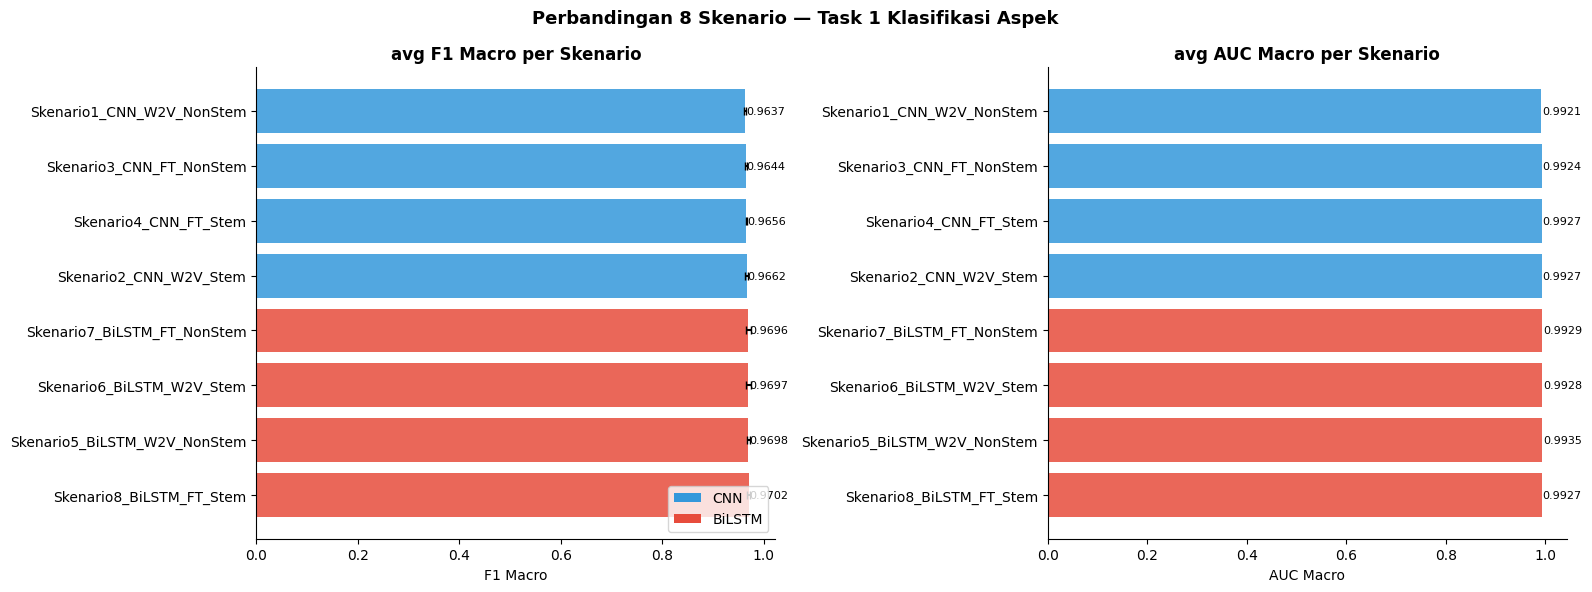

Grafik disimpan.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Warna berdasarkan arsitektur
colors = ['#3498db' if 'CNN' in s else '#e74c3c'
          for s in df_rekap['skenario']]

# Plot F1 Macro
bars = axes[0].barh(df_rekap['skenario'], df_rekap['avg_f1_macro'],
                    color=colors, alpha=0.85)
axes[0].errorbar(df_rekap['avg_f1_macro'],
                 range(len(df_rekap)),
                 xerr=df_rekap['std_f1_macro'],
                 fmt='none', color='black', capsize=3)
axes[0].set_title('avg F1 Macro per Skenario', fontweight='bold')
axes[0].set_xlabel('F1 Macro')
axes[0].spines[['top','right']].set_visible(False)
for bar in bars:
    axes[0].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{bar.get_width():.4f}', va='center', fontsize=8)

# Plot AUC Macro
bars2 = axes[1].barh(df_rekap['skenario'], df_rekap['avg_auc_macro'],
                     color=colors, alpha=0.85)
axes[1].set_title('avg AUC Macro per Skenario', fontweight='bold')
axes[1].set_xlabel('AUC Macro')
axes[1].spines[['top','right']].set_visible(False)
for bar in bars2:
    axes[1].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{bar.get_width():.4f}', va='center', fontsize=8)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3498db', label='CNN'),
    Patch(facecolor='#e74c3c', label='BiLSTM')
]
axes[0].legend(handles=legend_elements, loc='lower right')

plt.suptitle('Perbandingan 8 Skenario — Task 1 Klasifikasi Aspek',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'perbandingan_skenario_Task1.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik disimpan.")